# 📅 Time Series Forecasting — Baselines, Exponential Smoothing, ARIMA, and Gradient Boosting With Honest Backtests

> **What you'll learn:** what makes time-ordered data special, how to decompose a series into trend and seasonality, how to test for stationarity, why simple baselines are so hard to beat, how exponential smoothing (ETS) and ARIMA/SARIMAX work and how to fit them with `statsmodels`, how to turn forecasting into supervised learning with lag features and LightGBM (recursive vs direct), and how to evaluate all of it without fooling yourself: rolling-origin backtests, MASE, and interval coverage. You finish with a 28-day bike-demand forecast on real data.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Recommender Systems](19_Recommender_Systems.ipynb) (previous in the series) · [Linear Regression](03_Linear_Regression.ipynb) (OLS, residual diagnostics) · [Gradient Boosting](10_Gradient_Boosting.ipynb) (LightGBM) · [Statistics & Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) (hypothesis tests, p-values) · helpful: [Pandas](../01_Core_Scientific_Computing/02_Pandas.ipynb) Section 12 (`resample`, `rolling`) |
| **Tested with** | Python 3.12 · statsmodels 0.15 · scikit-learn 1.9 · lightgbm 4.7 · pandas 3.0 · numpy 2.5 · scipy 1.18 · matplotlib 3.11 |
| **Interview relevance** | ⭐⭐⭐ Very high — "why can't you use K-fold CV here?", stationarity and ADF vs KPSS, reading ACF/PACF, ETS vs ARIMA, recursive vs direct multi-step, "why is MAPE a bad metric?", MASE, "can gradient boosting extrapolate a trend?", design a demand-forecasting system |

## 🤔 What Is Time Series Forecasting?

Think of a **coffee shop owner deciding how much milk to order for next week**. She looks at:
- **last week's sales** (the recent level),
- **the same weekday in previous weeks** (Mondays are always busy: *seasonality*),
- **whether business is growing** (the *trend*),
- and **things she already knows about next week**: a public holiday, a heat wave in the weather forecast (*exogenous* information).

That is forecasting. A **time series** is a sequence of measurements taken in time order (hourly bike rentals, monthly airline passengers, daily sales). **Forecasting** means predicting future values from the past, usually with a **horizon** (how far ahead: "the next 28 days") and ideally with an **uncertainty range** ("between 4,000 and 6,500 rentals, 80% of the time").

Two big families of methods:
- **Statistical models** describe how the series evolves: **exponential smoothing** (weighted averages that forget the old past) and **ARIMA** (regression on the series' own past values and past errors).
- **Machine-learning models** turn the problem into an ordinary table: each row is a time point, the features are **lags** (past values), **rolling averages** and **calendar** facts, and the target is the future value. Gradient boosting (LightGBM) is the workhorse here.

The golden rule running through this whole notebook: **the future must never leak into the past** — not in the features, not in the validation scheme, not in the preprocessing.

## 🎯 Why It Matters

- **It drives money and operations.** Demand planning and inventory (retail, e-commerce), staffing (call centres, hospitals), energy load and pricing, capacity planning for cloud infrastructure, ride-sharing supply, cash-flow and finance forecasts.
- **It is a monitoring tool.** Anomaly detection on metrics (traffic, latency, fraud rates) often means "forecast what is normal, alert on the residual".
- **It is a classic ML trap.** Random train/test splits, features computed on the whole series, and percentage metrics that explode near zero make many "great" models useless in production. Knowing these traps is exactly what interviewers probe.
- **The state of the art is mixed.** In the M4 competition (100,000 series) most of the top methods were combinations of statistical models, the winner was a hybrid of exponential smoothing and a neural network, and pure ML methods did poorly; in M5 (Walmart sales), LightGBM with lag features dominated. A good engineer knows **both** families and chooses with a backtest.
- **In interviews** you'll hear: *"how would you validate a forecasting model?"*, *"what is stationarity and how do you test it?"*, *"read this ACF plot"*, *"ETS or ARIMA?"*, *"recursive or direct multi-step?"*, *"why is MAPE misleading?"*, *"can XGBoost forecast a growing trend?"*, *"design a forecasting system for 10,000 products"*.

## 🃏 Algorithm Card

Forecasting is a family of techniques, so this card has one column per approach.

| | Naive / seasonal naive | Exponential smoothing (ETS / Holt-Winters) | ARIMA / SARIMA / SARIMAX | Regression / GBM with lag features |
|---|---|---|---|---|
| **Learning type** | No learning (a rule) | Supervised, one model per series (local) | Supervised, one model per series (local) | Supervised; one model can be shared by many series (global) |
| **Tasks** | Point forecasts + simple intervals; the baseline for everything | Point + interval forecasts for series with level, trend, seasonality | Point + interval forecasts; effect of regressors (SARIMAX) | Point forecasts; quantiles with `objective="quantile"`; many series and rich covariates |
| **Model / objective** | $\hat y_{T+h} = y_T$ or $y_{T+h-m(k+1)}$ | Level/trend/season updated by weighted averages; parameters by maximum likelihood (≈ minimizing one-step squared errors) | $\phi(B)\Phi(B^m)(1-B)^d(1-B^m)^D y_t = \theta(B)\Theta(B^m)\varepsilon_t$ (+ $\beta^\top x_t$); Gaussian maximum likelihood | Minimize squared (or absolute / pinball) loss of $y_{t+h}$ given features known at $t$ |
| **Key hyperparameters** | Season length $m$ (7 daily, 12 monthly, 24/168 hourly) | Error / trend / seasonal type (A, M, damped), $m$; smoothing $\alpha, \beta, \gamma \in (0,1)$ and damping $\phi \in (0.8, 0.98)$ are fitted | Orders $p, q \in 0..3$; $d \in \{0,1,2\}$; $P, Q \in \{0,1,2\}$; $D \in \{0,1\}$; trend term; chosen by AICc + residual checks | Lag set (1…m, m, 2m), rolling windows (7, 28), `num_leaves` 7–63, `learning_rate` 0.01–0.1, `n_estimators` 200–2000, `min_child_samples` 5–100; strategy (recursive / direct) |
| **Needs feature scaling?** | No | No (log / Box-Cox helps when variance grows with level) | No, but scaling the target and exogenous columns helps the optimizer converge | Trees: no. The **target** often needs detrending (differences or ratios), because trees can't extrapolate |
| **Handles missing values / categoricals?** | Needs a regular time grid | No gaps allowed in `statsmodels` ETS: fill first | State-space `SARIMAX` handles missing $y$ (Kalman filter); exogenous columns must be complete; categoricals → dummies | LightGBM handles NaN and categorical features natively |
| **Training & prediction complexity** | $O(1)$ / $O(h)$ | $O(n)$ per likelihood evaluation × optimizer iterations; forecasts $O(h)$ | $O(n \cdot s^2)$ per likelihood evaluation (Kalman filter with state size $s \approx p + mP + d + mD$); slow for long seasons (e.g. $m = 168$) | $O(n \cdot f \cdot \text{trees})$ with histogram binning; recursive prediction needs $h$ model calls |
| **Interpretability** | Total | High: level, trend and seasonal components you can plot | Medium: coefficients, but AR/MA terms are hard to explain to stakeholders; exogenous effects are clear | Low–medium: feature importance, SHAP |
| **Strengths** | Free, robust, often surprisingly accurate | Fast, robust, good intervals, excellent on short seasonal series | Principled, handles autocorrelated errors and regressors, good intervals | Uses many features and many series at once, non-linear effects, holidays and promotions, scales to millions of rows |
| **Weaknesses** | Ignores everything but level/season | One series at a time; no covariates (in `statsmodels`); one seasonal period | Needs stationarity after differencing; order selection; single seasonality; slow with large $m$ | Can't extrapolate trends; needs careful leak-free features; multi-step strategy adds complexity; no intervals unless you build them |
| **Use it when** | Always, as the benchmark to beat | Few series, clear level/trend/season, need quick reliable forecasts with intervals | Autocorrelated series with known drivers (price, temperature), need inference on regressors | Many related series, rich covariates (weather, promotions, holidays), non-linear effects, lots of history |
| **Avoid it when** | You must model drivers or events | Multiple seasonalities (hour-of-day and day-of-week), many covariates | Very long seasons, thousands of series (too slow), strongly non-linear effects | Very short single series, strong trends without detrending, when you need interval guarantees without extra work |
| **Best libraries** | pandas `shift`, NumPy | `statsmodels` `ETSModel`, `ExponentialSmoothing` · statsforecast `AutoETS` | `statsmodels` `SARIMAX`, `ARIMA` · statsforecast / pmdarima `AutoARIMA` | LightGBM, XGBoost, CatBoost + pandas features · scikit-learn `TimeSeriesSplit` · MLForecast, skforecast, Darts |

## ✅ By the End You Can

- [ ] Explain why time series break the i.i.d. assumption, fix irregular timestamps with `asfreq`/`resample`, and decompose a series with classical decomposition and STL
- [ ] Test for stationarity with ADF and KPSS (and explain why they disagree), choose differencing, and read ACF/PACF plots to pick ARIMA orders
- [ ] Build naive, seasonal naive, drift and moving-average baselines, then fit ETS/Holt-Winters and SARIMA/SARIMAX with `statsmodels`, check residuals with Ljung–Box, and produce prediction intervals
- [ ] Turn forecasting into supervised learning with leak-free lag, rolling and calendar features; implement recursive and direct multi-step LightGBM forecasts, and fix trees' extrapolation problem by detrending
- [ ] Evaluate forecasts honestly with rolling-origin backtests (`TimeSeriesSplit` with `test_size` and `gap`), horizon-wise MAE/RMSE/MASE, and interval coverage of quantile models
- [ ] Build simple exponential smoothing, Holt's method, AR(p) by OLS and MASE from scratch and prove they match `statsmodels`

## 📋 Table of Contents

1. [What Makes Time Series Different](#1.-What-Makes-Time-Series-Different-🟢)
2. [Timestamps, Frequency, Resampling, and Gaps](#2.-Timestamps,-Frequency,-Resampling,-and-Gaps-🟢)
3. [Decomposition: Trend, Seasonality, Remainder](#3.-Decomposition:-Trend,-Seasonality,-Remainder-🟢)
4. [Stationarity, Differencing, ADF and KPSS](#4.-Stationarity,-Differencing,-ADF-and-KPSS-🟡)
5. [Reading ACF and PACF Plots](#5.-Reading-ACF-and-PACF-Plots-🟡)
6. [Baselines First: Naive, Seasonal Naive, Drift, Moving Average](#6.-Baselines-First:-Naive,-Seasonal-Naive,-Drift,-Moving-Average-🟢)
7. [Exponential Smoothing: SES → Holt → Holt-Winters → ETS](#7.-Exponential-Smoothing:-SES-→-Holt-→-Holt-Winters-→-ETS-🟡)
8. [ARIMA, SARIMA, and SARIMAX](#8.-ARIMA,-SARIMA,-and-SARIMAX-🟡)
9. [Forecasting as Supervised Learning: Lags, Rolling Windows, Calendar](#9.-Forecasting-as-Supervised-Learning:-Lags,-Rolling-Windows,-Calendar-🟡)
10. [Multi-Step Forecasting: Recursive vs Direct](#10.-Multi-Step-Forecasting:-Recursive-vs-Direct-🔴)
11. [Trees Can't Extrapolate: Trends and Detrending](#11.-Trees-Can't-Extrapolate:-Trends-and-Detrending-🟡)
12. [Evaluation Done Right: Metrics, Backtesting, Leakage](#12.-Evaluation-Done-Right:-Metrics,-Backtesting,-Leakage-🟡)
13. [Probabilistic Forecasts: Quantile LightGBM and Coverage](#13.-Probabilistic-Forecasts:-Quantile-LightGBM-and-Coverage-🔴)
14. [Many Series: Hierarchies, Global Models, Foundation Models](#14.-Many-Series:-Hierarchies,-Global-Models,-Foundation-Models-🟢)
15. [A Fair Head-to-Head Comparison](#15.-A-Fair-Head-to-Head-Comparison-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-28-Day-Bike-Demand-Forecast) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel. (Prophet, statsforecast, sktime and Darts are **not** needed: everything here uses `statsmodels`, scikit-learn and LightGBM.)

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

Four real datasets (about 1.5 MB in total) are loaded and cached under `_outputs/datasets/`:
- **AirPassengers** (Box & Jenkins): monthly totals of international airline passengers, in thousands, 1949–1960. The classic series with trend and growing seasonality. Downloaded once from the Rdatasets collection via `statsmodels`.
- **Mauna Loa CO₂** (`statsmodels` built-in): weekly atmospheric CO₂ in ppm, 1958–2001, with missing weeks.
- **Sunspots** (`statsmodels` built-in): yearly sunspot numbers, 1700–2008. Cycles of about 11 years.
- **Bike Sharing Demand** (OpenML 42712, Capital Bikeshare, Washington D.C.): hourly rentals for 2011–2012 with weather and holiday flags. The OpenML copy has no date column, so we **rebuild the timestamps** from the weekday/month/year columns and **verify** them.

**One rule for the bike data:** the last 28 days (4–31 December 2012) are the **final test window** of the Mini Project. Every concept section uses only `daily_dev`, the days before it.

In [1]:
# %pip install -q "statsmodels>=0.14" "scikit-learn>=1.8" "lightgbm>=4.0" "numpy>=2.0" "pandas>=2.2" "scipy>=1.11" matplotlib

import itertools
import sys
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
import statsmodels.api as sm
from scipy import stats
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_pinball_loss,
    root_mean_squared_error,
)
from sklearn.model_selection import KFold, TimeSeriesSplit
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

print(f"Python {sys.version.split()[0]} | statsmodels {statsmodels.__version__} | scikit-learn {sklearn.__version__} | "
      f"lightgbm {lgb.__version__} | pandas {pd.__version__} | numpy {np.__version__} | scipy {scipy.__version__} | "
      f"matplotlib {matplotlib.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 130)
OUTPUT_DIR = Path("_outputs")                   # files we write go here (ignored by git)
DATA_DIR = OUTPUT_DIR / "datasets"              # dataset cache
DATA_DIR.mkdir(parents=True, exist_ok=True)
# small, fast LightGBM settings used throughout (n_jobs=4 keeps the laptop responsive)
LGB_PARAMS = dict(n_estimators=300, learning_rate=0.05, num_leaves=15, min_child_samples=10, subsample=0.8,
                  subsample_freq=1, colsample_bytree=0.8, random_state=SEED, n_jobs=4, verbosity=-1)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol, equal_nan=True)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")


# 1) AirPassengers: monthly, thousands of passengers
air_raw = sm.datasets.get_rdataset("AirPassengers", cache=str(DATA_DIR / "rdatasets")).data
assert np.allclose(air_raw["time"], 1949 + np.arange(len(air_raw)) / 12)        # one row per month, no gaps
air = pd.Series(air_raw["value"].to_numpy(dtype=float), name="passengers",
                index=pd.date_range("1949-01-01", periods=len(air_raw), freq="MS"))

# 2) Mauna Loa CO2: weekly (weeks ending Saturday), ppm, with missing weeks
co2_weekly = sm.datasets.co2.load_pandas().data["co2"]

# 3) Sunspots: yearly
sun_raw = sm.datasets.sunspots.load_pandas().data
sunspots = pd.Series(sun_raw["SUNACTIVITY"].to_numpy(dtype=float), name="sunspots",
                     index=pd.date_range(f"{int(sun_raw['YEAR'].iloc[0])}-01-01", periods=len(sun_raw), freq="YS"))

# 4) Bike Sharing Demand: hourly rows in time order, but no date column in the OpenML copy
bike = fetch_openml(data_id=42712, as_frame=True, data_home=DATA_DIR).frame
weekday = bike["weekday"].to_numpy()                                   # UCI coding: 0 = Sunday … 6 = Saturday
day_offset = np.concatenate([[0], np.cumsum(np.diff(weekday) % 7)])    # +1 day each time the weekday changes
dates = pd.Timestamp("2011-01-01") + pd.to_timedelta(day_offset, unit="D")
assert np.array_equal((dates.dayofweek.to_numpy() + 1) % 7, weekday), "weekday mismatch"
assert np.array_equal(dates.month.to_numpy(), bike["month"].to_numpy()), "month mismatch"
assert np.array_equal(dates.year.to_numpy() - 2011, bike["year"].to_numpy()), "year mismatch"
bike = bike.assign(timestamp=dates + pd.to_timedelta(bike["hour"].to_numpy(), unit="h"),
                   holiday=bike["holiday"].astype(str).eq("True"), workingday=bike["workingday"].astype(str).eq("True"))
assert bike["timestamp"].is_monotonic_increasing and not bike["timestamp"].duplicated().any()
print(f"✅ rebuilt bike timestamps {bike['timestamp'].min()} → {bike['timestamp'].max()}: weekday, month and year all match")

daily = (bike.groupby(bike["timestamp"].dt.floor("D"))
         .agg(count=("count", "sum"), temp=("temp", "mean"), humidity=("humidity", "mean"),
              windspeed=("windspeed", "mean"), holiday=("holiday", "max"), workingday=("workingday", "max"))
         .rename_axis("date").asfreq("D"))
assert not daily.isna().any().any()
FINAL_TEST_DAYS = 28
daily_dev = daily.iloc[:-FINAL_TEST_DAYS]          # everything the concept sections may use
print(f"AirPassengers {len(air)} months | CO2 {len(co2_weekly)} weeks ({co2_weekly.isna().sum()} missing) | "
      f"sunspots {len(sunspots)} years | bike {len(bike):,} hours → {len(daily)} days")
print(f"bike development period {daily_dev.index[0]:%Y-%m-%d} → {daily_dev.index[-1]:%Y-%m-%d} | "
      f"final test window {daily.index[-FINAL_TEST_DAYS]:%Y-%m-%d} → {daily.index[-1]:%Y-%m-%d} (untouched until the Mini Project)")
print(daily_dev.head(3))

Python 3.12.11 | statsmodels 0.15.0 | scikit-learn 1.9.1 | lightgbm 4.7.0 | pandas 3.0.5 | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2
✅ rebuilt bike timestamps 2011-01-01 00:00:00 → 2012-12-31 23:00:00: weekday, month and year all match
AirPassengers 144 months | CO2 2284 weeks (59 missing) | sunspots 309 years | bike 17,379 hours → 731 days
bike development period 2011-01-01 → 2012-12-03 | final test window 2012-12-04 → 2012-12-31 (untouched until the Mini Project)
            count     temp  humidity  windspeed  holiday  workingday
date                                                                
2011-01-01    985  14.1108    0.8058    10.7499    False       False
2011-01-02    801  14.9026    0.6961    16.6521    False       False
2011-01-03   1349   8.0509    0.4373    16.6367    False        True


## 1. What Makes Time Series Different 🟢

In ordinary ML we assume rows are **i.i.d.**: independent and identically distributed, like shuffled cards. You can shuffle them, split them randomly, and every row is a fresh draw.

Time series break both halves:
- **Not independent.** Today's value is strongly related to yesterday's. This is **autocorrelation**: the correlation of a series with a lagged copy of itself. A **lag** of $k$ means "the value $k$ steps ago", $y_{t-k}$.
- **Not identically distributed.** The average and the spread can drift over time (trend, growing seasonality, structural breaks such as a pandemic or a new pricing policy).
- **Order is information.** Shuffling a time series destroys the very pattern you want to forecast.

The usual building blocks of a series:

| Component | Plain English | Example |
|---|---|---|
| **Trend** | the long-run direction | airline passengers grow year after year |
| **Seasonality** | a pattern with a **fixed, known period** $m$ | more bike rentals on weekdays ($m = 7$), more flights in July ($m = 12$) |
| **Cycles** | rises and falls **without** a fixed period | ~11-year sunspot cycles, business cycles |
| **Noise (remainder)** | what's left: unpredictable wiggles, outliers | a storm closes the bike system for a day |

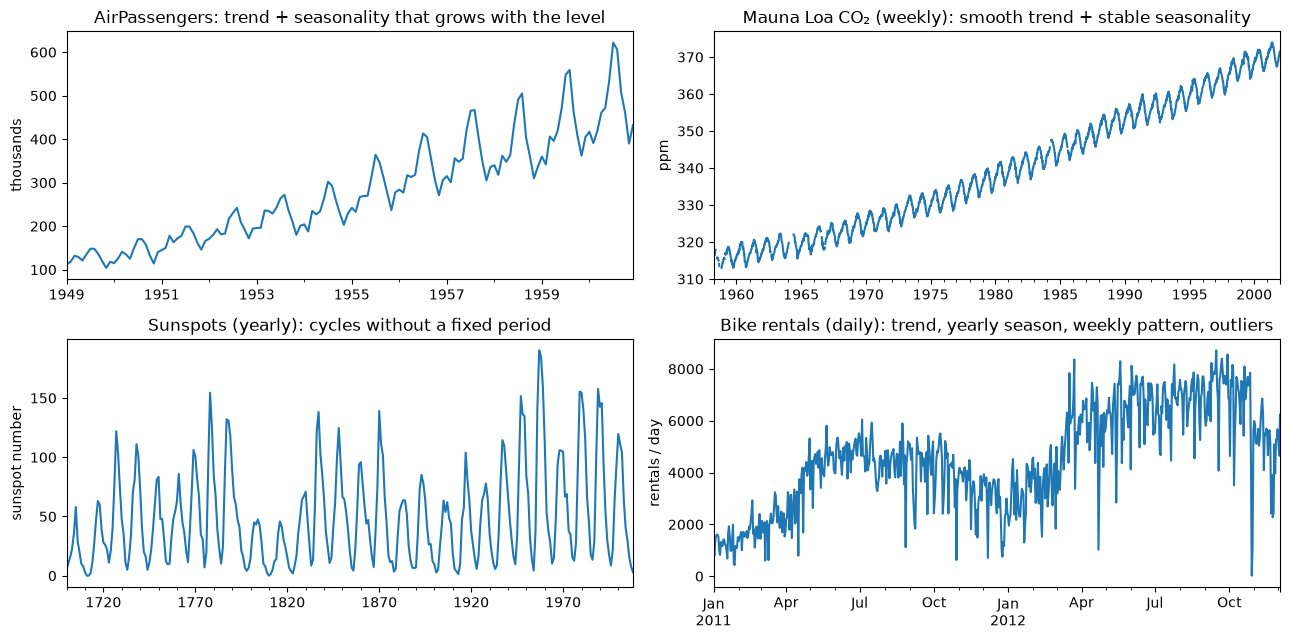

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5))
air.plot(ax=axes[0, 0], title="AirPassengers: trend + seasonality that grows with the level", ylabel="thousands")
co2_weekly.plot(ax=axes[0, 1], title="Mauna Loa CO₂ (weekly): smooth trend + stable seasonality", ylabel="ppm")
sunspots.plot(ax=axes[1, 0], title="Sunspots (yearly): cycles without a fixed period", ylabel="sunspot number")
daily_dev["count"].plot(ax=axes[1, 1], title="Bike rentals (daily): trend, yearly season, weekly pattern, outliers", ylabel="rentals / day")
for ax in axes.ravel():
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

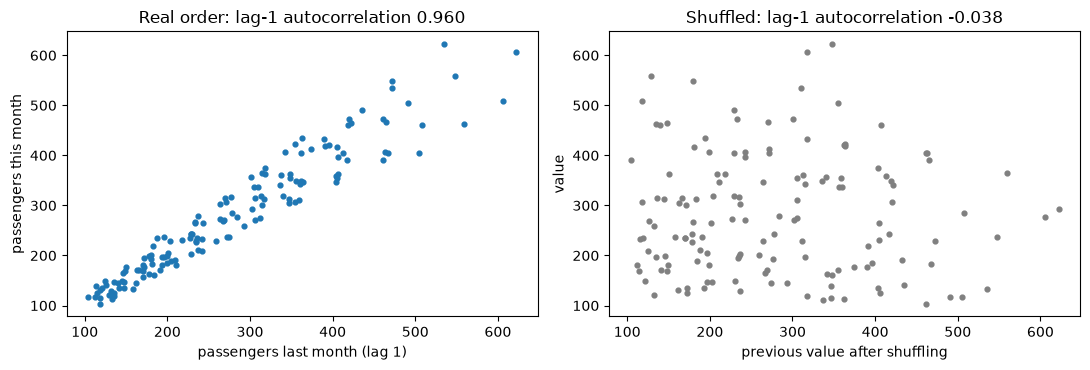

MAE of 'next = previous': real order 25.9 | shuffled order 136.6 → shuffling makes the same rule 5.3× worse
autocorrelation at lag 12 (same month last year): 0.991


In [3]:
shuffled = pd.Series(rng.permutation(air.to_numpy()), index=air.index)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].scatter(air.shift(1), air, s=12)
axes[0].set(xlabel="passengers last month (lag 1)", ylabel="passengers this month", title=f"Real order: lag-1 autocorrelation {air.autocorr(1):.3f}")
axes[1].scatter(shuffled.shift(1), shuffled, s=12, color="gray")
axes[1].set(xlabel="previous value after shuffling", ylabel="value", title=f"Shuffled: lag-1 autocorrelation {shuffled.autocorr(1):.3f}")
plt.tight_layout()
plt.show()

# "Next month = this month" is a forecast that only works if order carries information
mae_real = mean_absolute_error(air.iloc[1:], air.shift(1).iloc[1:])
mae_shuffled = mean_absolute_error(shuffled.iloc[1:], shuffled.shift(1).iloc[1:])
print(f"MAE of 'next = previous': real order {mae_real:.1f} | shuffled order {mae_shuffled:.1f} "
      f"→ shuffling makes the same rule {mae_shuffled / mae_real:.1f}× worse")
print(f"autocorrelation at lag 12 (same month last year): {air.autocorr(12):.3f}")

The lag plot is almost a straight line: knowing last month tells you a lot about this month. After shuffling, the cloud is round. That structure is exactly what forecasting models exploit, and exactly what a random train/test split throws away (Section 12 measures the damage).

### ✍️ Your Turn

Compute the **lag-12 autocorrelation** of `air` yourself: the Pearson correlation between `air` and `air.shift(12)`. Use `Series.corr` (it skips the NaNs created by the shift). Store it in `lag12_corr`.

In [4]:
lag12_corr = None  # TODO: your code here
check("lag12_corr", lag12_corr, air.autocorr(12), hint="air.corr(air.shift(12))")

⏳ lag12_corr: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
lag12_corr = air.corr(air.shift(12))
check("lag12_corr", lag12_corr, air.autocorr(12))
```

`Series.autocorr(k)` is exactly this Pearson correlation. (The ACF in Section 5 uses a slightly different formula with one overall mean, so its values are a little smaller.)
</details>

> 💡 **Interview angle:** "Why can't you use random K-fold cross-validation on time series?" — rows are autocorrelated, so a random split puts neighbours of each test point in the training set and the model effectively interpolates; in production it must extrapolate into an unseen future. Use time-ordered splits (rolling-origin backtests) where training data always precedes test data.

## 2. Timestamps, Frequency, Resampling, and Gaps 🟢

Most forecasting models assume a **regular grid**: one value per hour, day or month, with **no missing timestamps**. Real data rarely arrives that way.

| Tool | What it does | Typical use |
|---|---|---|
| `DatetimeIndex.freq` / `inferred_freq` | the grid spacing, if regular | `None` means gaps or irregular spacing |
| `s.asfreq("h")` | **re-index** onto a complete grid; missing timestamps become NaN | *reveal* gaps |
| `s.resample("D").sum(min_count=1)` | **aggregate** to a coarser frequency | hourly → daily totals, weekly → monthly means |
| `interpolate("time")`, `ffill()` | fill NaNs | smooth physical measurements vs step-like states |

**Irregular series** (event logs, trades, sensor pings) are usually aggregated onto a regular grid first (counts per hour, last price per minute). Frequency choice is a modelling decision: coarser = less noise and shorter seasons, finer = more detail and longer seasons ($m = 24 \times 7 = 168$ for hourly weekly patterns). The basics of `resample` and `rolling` are in [Pandas, Section 12](../01_Core_Scientific_Computing/02_Pandas.ipynb).

In [5]:
print(f"CO2 index frequency: {co2_weekly.index.freqstr} | missing weeks: {co2_weekly.isna().sum()} of {len(co2_weekly)}")

# Which filling method is better? Hide 10% of the KNOWN weeks, fill them, and compare with the truth.
known = co2_weekly.dropna().index
hidden = rng.choice(len(known), size=len(known) // 10, replace=False)
co2_masked = co2_weekly.copy()
co2_masked.loc[known[hidden]] = np.nan
truth = co2_weekly.loc[known[hidden]]
fill_errors = {
    "forward fill": mean_absolute_error(truth, co2_masked.ffill().loc[truth.index]),
    "linear time interpolation": mean_absolute_error(truth, co2_masked.interpolate("time").loc[truth.index]),
    "overall mean": mean_absolute_error(truth, np.full(len(truth), co2_masked.mean())),
}
for name, err in fill_errors.items():
    print(f"  fill by {name:26s}: MAE on hidden weeks {err:.3f} ppm")
print(f"→ best for this smooth physical series: {min(fill_errors, key=fill_errors.get)}")

co2_monthly = co2_weekly.interpolate("time").resample("MS").mean()
print(f"weekly → monthly means: {len(co2_monthly)} months, NaN months: {co2_monthly.isna().sum()}, frequency {co2_monthly.index.freqstr}")

CO2 index frequency: W-SAT | missing weeks: 59 of 2284
  fill by forward fill              : MAE on hidden weeks 0.428 ppm
  fill by linear time interpolation : MAE on hidden weeks 0.265 ppm
  fill by overall mean              : MAE on hidden weeks 15.464 ppm
→ best for this smooth physical series: linear time interpolation
weekly → monthly means: 526 months, NaN months: 0, frequency MS


In [6]:
hourly = bike.set_index("timestamp")["count"]
hourly_full = hourly.asfreq("h")                        # complete hourly grid: gaps become NaN
missing_hours = hourly_full.index[hourly_full.isna()]
print(f"hourly rows: {len(hourly):,} | inferred frequency before asfreq: {hourly.index.inferred_freq} | "
      f"complete grid: {len(hourly_full):,} hours → {len(missing_hours)} missing")
print("days with the most missing hours:")
print(pd.Series(missing_hours.normalize()).value_counts().head(4).to_string())
night_share = np.mean(missing_hours.hour <= 5)
print(f"share of missing hours between 00:00 and 05:59: {night_share:.0%} (these 6 hours are 25% of the day) | "
      f"smallest recorded hourly count: {hourly.min()} (no zeros at all)")

daily_from_hourly = hourly_full.resample("D").sum(min_count=1)
assert np.allclose(daily_from_hourly.to_numpy(), daily["count"].to_numpy())
weekly_totals = hourly_full.resample("W-SUN").sum(min_count=1)
print(f"✅ hourly → daily totals match the daily table | weekly totals: {len(weekly_totals)} weeks "
      f"(first label {weekly_totals.index[0]:%Y-%m-%d}: resample labels each week by its END, the Sunday)")

hourly rows: 17,379 | inferred frequency before asfreq: None | complete grid: 17,544 hours → 165 missing
days with the most missing hours:
timestamp
2012-10-29    23
2011-01-27    16
2012-10-30    13
2011-01-18    12
share of missing hours between 00:00 and 05:59: 67% (these 6 hours are 25% of the day) | smallest recorded hourly count: 1 (no zeros at all)
✅ hourly → daily totals match the daily table | weekly totals: 106 weeks (first label 2011-01-02: resample labels each week by its END, the Sunday)


Two different kinds of gaps hide in the bike data:
- **Night-time hours** with no row at all. The data contains **no zero counts**, and most missing hours are between midnight and 6 am, so many "missing" hours are most likely hours with zero rentals that were never logged.
- **Whole days mostly missing**: 29–30 October 2012 is Hurricane Sandy, when the system shut down. Those are genuine outages, not zeros.

Filling both with 0 (or both with interpolation) would be wrong for one of them. **Know why data is missing before you fill it.** For the daily series we simply sum what was recorded.

### ✍️ Your Turn

How many hours are missing in **2011** on the complete hourly grid `hourly_full`? Store the integer in `missing_2011`.

In [7]:
missing_2011 = None  # TODO: your code here
check("missing_2011", missing_2011, 365 * 24 - int((bike["timestamp"].dt.year == 2011).sum()),
      hint="hourly_full.loc['2011'].isna().sum()")

⏳ missing_2011: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
missing_2011 = int(hourly_full.loc["2011"].isna().sum())
check("missing_2011", missing_2011, 365 * 24 - int((bike["timestamp"].dt.year == 2011).sum()))
```

Partial string indexing (`.loc["2011"]`) selects a whole year on a `DatetimeIndex`. The checker counts it another way: hours in a non-leap year minus recorded rows.
</details>

> 💡 **Interview angle:** "Your hourly data has gaps. What do you do?" — first `asfreq` onto the full grid to *see* the gaps, then find out *why* they exist (no events → 0, sensor outage → NaN / interpolate / model with a state-space method, system shutdown → flag as an event). Never let `shift(24)` silently mean "24 rows ago" on a gappy series (Pitfall 1).

## 3. Decomposition: Trend, Seasonality, Remainder 🟢

**Decomposition** splits a series into pieces you can look at separately:

$$\text{additive: } y_t = T_t + S_t + R_t \qquad\qquad \text{multiplicative: } y_t = T_t \times S_t \times R_t$$

- **Additive** when the seasonal swings stay the same size as the level changes (CO₂).
- **Multiplicative** when the swings grow with the level (airline passengers: July is "+20%", not "+40 thousand").
- Taking **logs** turns multiplicative into additive: $\log y_t = \log T_t + \log S_t + \log R_t$. The **Box-Cox** transform generalizes this: $y^{(\lambda)} = (y^\lambda - 1)/\lambda$ for $\lambda \ne 0$ and $\log y$ for $\lambda = 0$. Transforming to **stabilize the variance** is often the first modelling step.

Two decomposition methods:
- **Classical** (`seasonal_decompose`): trend = centred moving average of length $m$; seasonal = average detrended value for each season, **identical every year**. Simple, but loses $m/2$ points at each end and can't adapt.
- **STL** (Seasonal-Trend decomposition using LOESS): local regressions that let the seasonal pattern **evolve slowly**, work for any period, and `robust=True` downweights outliers. The usual choice in practice.

Box-Cox λ chosen by maximum likelihood: 0.148 (0 would be a pure log)
  raw     : correlation between a year's level and its seasonal range = +0.99
  log     : correlation between a year's level and its seasonal range = +0.79
  box-cox : correlation between a year's level and its seasonal range = +0.90
→ raw scale: the swings grow almost in lockstep with the level (multiplicative). The log scale weakens that link most (+0.99 → +0.79), but doesn't remove it: the seasonal pattern itself also grew over time (see STL below).


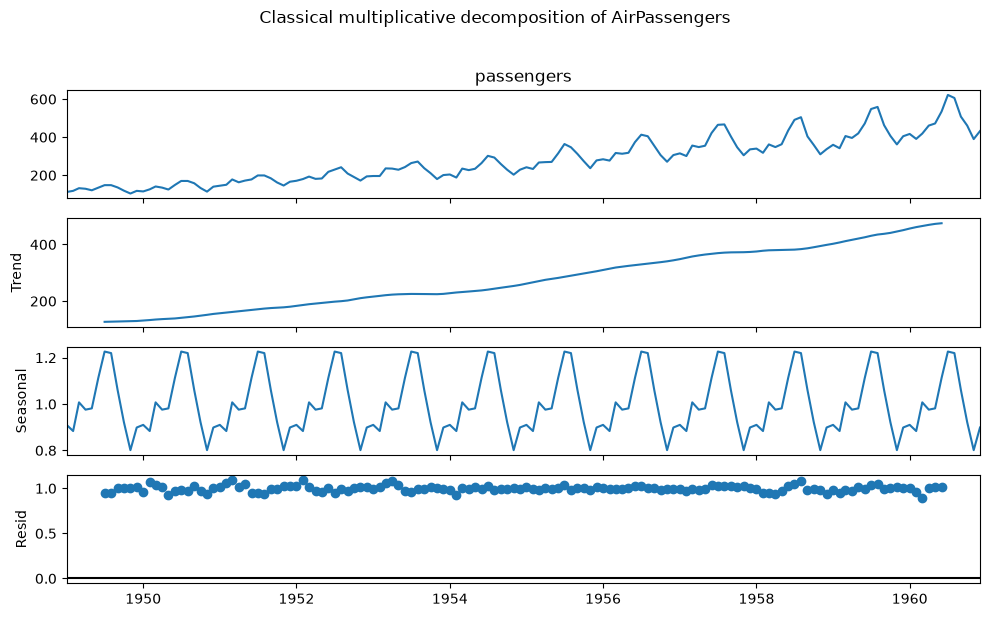

classical trend has 12 NaNs (6 at each end); seasonal factors for Jan/Jul: 0.910 / 1.227 (the same every year)


In [8]:
yearly = pd.DataFrame({"raw": air, "log": np.log(air), "box-cox": stats.boxcox(air.to_numpy())[0]}, index=air.index)
bc_lambda = stats.boxcox(air.to_numpy())[1]
levels = yearly.groupby(yearly.index.year).mean()
ranges = yearly.groupby(yearly.index.year).agg(lambda s: s.max() - s.min())
print(f"Box-Cox λ chosen by maximum likelihood: {bc_lambda:.3f} (0 would be a pure log)")
for col in yearly.columns:
    r = np.corrcoef(levels[col], ranges[col])[0, 1]
    print(f"  {col:8s}: correlation between a year's level and its seasonal range = {r:+.2f}")
link = {col: np.corrcoef(levels[col], ranges[col])[0, 1] for col in yearly.columns}
weakest = min(link, key=link.get)
print(f"→ raw scale: the swings grow almost in lockstep with the level (multiplicative). The {weakest} scale weakens that link most "
      f"({link['raw']:+.2f} → {link[weakest]:+.2f})" + (", but doesn't remove it: the seasonal pattern itself also grew over time (see STL below)."
                                                         if link[weakest] > 0.3 else " and nearly removes it."))

classical = seasonal_decompose(air, model="multiplicative", period=12)
fig = classical.plot()
fig.set_size_inches(10, 6)
fig.suptitle("Classical multiplicative decomposition of AirPassengers", y=1.02)
plt.tight_layout()
plt.show()
print(f"classical trend has {classical.trend.isna().sum()} NaNs (6 at each end); seasonal factors for Jan/Jul: "
      f"{classical.seasonal.iloc[0]:.3f} / {classical.seasonal.iloc[6]:.3f} (the same every year)")

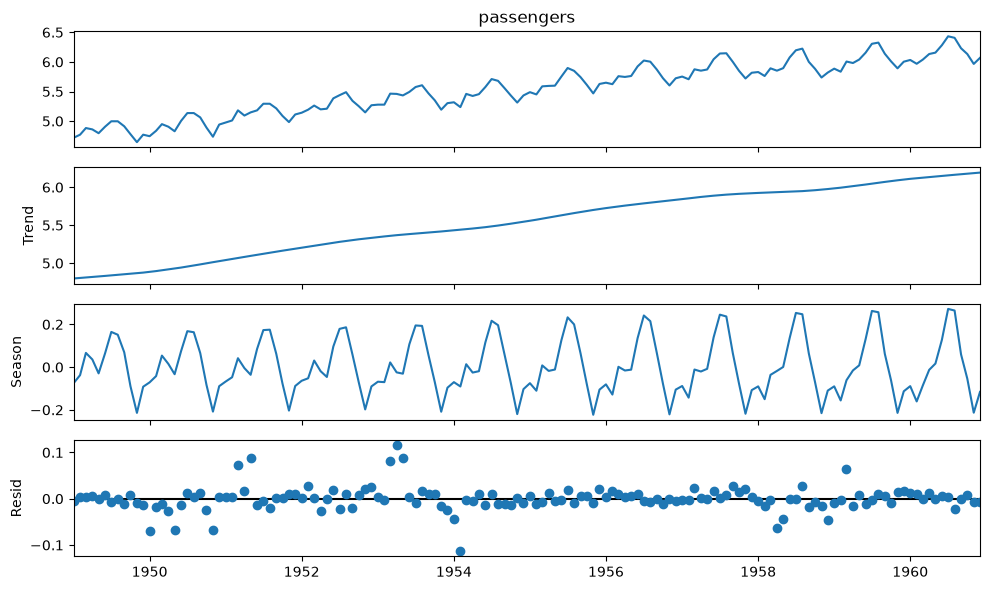

STL on log(passengers): seasonal strength F_S = 0.959 (0 = none, 1 = pure seasonality)
July seasonal effect on the log scale: +0.165 in 1949 → +0.272 in 1960 (STL lets the pattern evolve)

bike days with the largest STL remainder (in standard deviations):
            count   temp  humidity  windspeed  holiday  remainder_sd
date                                                                
2012-10-29     22  18.04      0.88      24.00    False         -7.55
2012-10-30   1096  13.05      0.83      14.27    False         -6.49
2012-04-22   1027  16.26      0.84      23.08    False         -5.96
2012-09-18   4073  25.56      0.87      23.96    False         -4.32


In [9]:
stl_air = STL(np.log(air), period=12, robust=True).fit()
fig = stl_air.plot()
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.show()

seasonal_strength = max(0.0, 1 - np.var(stl_air.resid) / np.var(stl_air.seasonal + stl_air.resid))
july_effect = stl_air.seasonal[stl_air.seasonal.index.month == 7]
print(f"STL on log(passengers): seasonal strength F_S = {seasonal_strength:.3f} (0 = none, 1 = pure seasonality)")
print(f"July seasonal effect on the log scale: {july_effect.iloc[0]:+.3f} in {july_effect.index[0].year} → "
      f"{july_effect.iloc[-1]:+.3f} in {july_effect.index[-1].year} (STL lets the pattern evolve)")

stl_bike = STL(daily_dev["count"], period=7, robust=True).fit()
bike_remainder = stl_bike.resid / stl_bike.resid.std()
unusual = daily_dev.assign(remainder_sd=bike_remainder).loc[bike_remainder.abs().nlargest(4).index]
print("\nbike days with the largest STL remainder (in standard deviations):")
print(unusual[["count", "temp", "humidity", "windspeed", "holiday", "remainder_sd"]].round(2).to_string())

**Strength of seasonality and trend** (from *Forecasting: Principles and Practice*): $F_S = \max\left(0,\ 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}\right)$ and $F_T = \max\left(0,\ 1 - \frac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)}\right)$. Values near 1 mean the component dominates the noise. They're handy for triaging thousands of series ("which ones need a seasonal model?").

The bike remainder flags the days a forecaster must know about: storms and washed-out days (very high humidity and wind; 29 October 2012 is Hurricane Sandy). Holidays are the other usual suspects. Such days are candidates for **event features**, or for excluding from error metrics with a documented reason.

### ✍️ Your Turn

Compute the **trend strength** $F_T$ of `stl_air` using the formula above. Store it in `trend_strength`.

In [10]:
trend_strength = None  # TODO: your code here
check("trend_strength", trend_strength, max(0.0, 1 - stl_air.resid.var(ddof=0) / (stl_air.trend + stl_air.resid).var(ddof=0)),
      hint="max(0, 1 - np.var(resid) / np.var(trend + resid))")

⏳ trend_strength: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
trend_strength = max(0.0, 1 - np.var(stl_air.resid) / np.var(stl_air.trend + stl_air.resid))
check("trend_strength", trend_strength, max(0.0, 1 - stl_air.resid.var(ddof=0) / (stl_air.trend + stl_air.resid).var(ddof=0)))
print(f"F_T = {trend_strength:.3f}")
```

`np.var` uses `ddof=0` while pandas `.var()` defaults to `ddof=1`; the ratio is almost identical either way, but be consistent. AirPassengers has both a very strong trend and a very strong seasonality.
</details>

> 💡 **Interview angle:** "Additive or multiplicative seasonality?" — look at whether seasonal swings grow with the level. If they do, model multiplicatively or take logs/Box-Cox first (then back-transform, remembering that $\exp$ of a mean log forecast is a **median** forecast). Use STL (robust) rather than classical decomposition when the pattern evolves or outliers exist.

## 4. Stationarity, Differencing, ADF and KPSS 🟡

A series is **(weakly) stationary** when its mean, variance and autocorrelations **don't depend on time**: any stretch of it looks statistically like any other. Trends and seasonality break stationarity.

**Why care?** ARMA models assume stationarity: they forecast by pulling back toward a fixed mean with a fixed correlation structure. A **random walk** $y_t = y_{t-1} + \varepsilon_t$ has a **unit root**: shocks never fade, the variance grows with time, and "the mean" doesn't exist.

**Differencing** removes it:
- first difference $\nabla y_t = y_t - y_{t-1}$ removes a stochastic trend (a random walk becomes white noise);
- seasonal difference $\nabla_m y_t = y_t - y_{t-m}$ removes a stable seasonal pattern.

**Two tests with opposite null hypotheses:**

| Test | Null hypothesis $H_0$ | Small p-value (< 0.05) means | Idea |
|---|---|---|---|
| **ADF** (Augmented Dickey–Fuller) | the series **has a unit root** (non-stationary) | evidence **for stationarity** | regress $\Delta y_t = \alpha + \gamma y_{t-1} + \sum_i \delta_i \Delta y_{t-i} + \varepsilon_t$ and test $\gamma = 0$ |
| **KPSS** | the series **is stationary** (around a level, or a trend with `regression="ct"`) | evidence **against stationarity** | is the cumulative sum of deviations from the mean too large? |

Reading them together:

| ADF rejects? | KPSS rejects? | Conclusion |
|---|---|---|
| yes | no | stationary ✅ |
| no | yes | non-stationary → difference |
| yes | yes | trend-stationary or structural change: try `regression="ct"` / detrending |
| no | no | inconclusive: tests lack power (short series, strong seasonality, near-unit root) |

KPSS p-values come from a lookup table that only covers 0.01–0.10. When the statistic falls outside it, `statsmodels` warns and returns the boundary, so we print "≤ 0.01" or "≥ 0.10" instead of pretending to know more.

                                  n ADF lags   ADF p  KPSS p                                               verdict
log(air)                        144       13  0.4224  ≤ 0.01                           non-stationary → difference
Δ log(air)                      143       14  0.0711  ≥ 0.10  DISAGREE: neither rejects → inconclusive (low power)
Δ₁₂ log(air)                    132       12  0.0724  ≥ 0.10  DISAGREE: neither rejects → inconclusive (low power)
Δ Δ₁₂ log(air)                  131       12  0.0002  ≥ 0.10                                            stationary
sunspots                        309        8  0.0531   0.016                           non-stationary → difference
CO₂ monthly (trend test, 'ct')  526       13  0.5664  ≤ 0.01                           non-stationary → difference

series where the two tests disagree: ['Δ log(air)', 'Δ₁₂ log(air)']


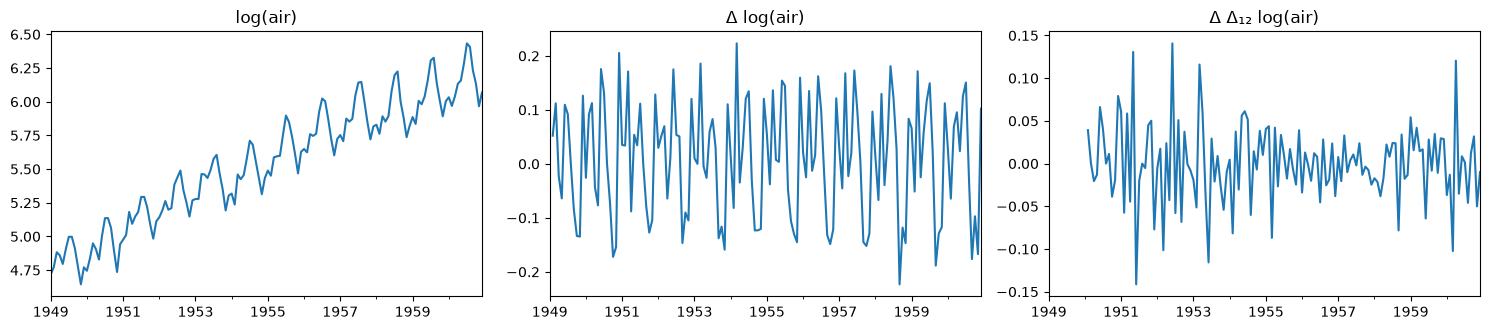

In [11]:
def stationarity_report(series, regression="c"):
    """ADF + KPSS on one series, with the KPSS table limits shown honestly."""
    x = series.dropna()
    adf_res = adfuller(x, regression=regression, autolag="AIC", result_object=True)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)      # informational: p is clipped to [0.01, 0.10]
        kpss_res = kpss(x, regression=regression, nlags="auto", result_object=True)
    kpss_text = "≥ 0.10" if kpss_res.pvalue >= 0.10 else ("≤ 0.01" if kpss_res.pvalue <= 0.01 else f"{kpss_res.pvalue:.3f}")
    adf_rejects, kpss_rejects = adf_res.pvalue < 0.05, kpss_res.pvalue < 0.05
    verdict = {(True, False): "stationary", (False, True): "non-stationary → difference",
               (True, True): "DISAGREE: both reject → trend-stationary / breaks",
               (False, False): "DISAGREE: neither rejects → inconclusive (low power)"}[(adf_rejects, kpss_rejects)]
    return {"n": len(x), "ADF lags": adf_res.lags, "ADF p": round(adf_res.pvalue, 4), "KPSS p": kpss_text, "verdict": verdict}


log_air = np.log(air)
candidates = {
    "log(air)": (log_air, "c"),
    "Δ log(air)": (log_air.diff(), "c"),
    "Δ₁₂ log(air)": (log_air.diff(12), "c"),
    "Δ Δ₁₂ log(air)": (log_air.diff(12).diff(), "c"),
    "sunspots": (sunspots, "c"),
    "CO₂ monthly (trend test, 'ct')": (co2_monthly, "ct"),
}
stationarity_table = pd.DataFrame({name: stationarity_report(s, reg) for name, (s, reg) in candidates.items()}).T
print(stationarity_table.to_string())
disagreements = stationarity_table.index[stationarity_table["verdict"].str.startswith("DISAGREE")].tolist()
print(f"\nseries where the two tests disagree: {disagreements or 'none'}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, name in zip(axes, ["log(air)", "Δ log(air)", "Δ Δ₁₂ log(air)"]):
    candidates[name][0].plot(ax=ax, title=name)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

Reading the table:
- **log(air)** has a trend: ADF can't reject a unit root and KPSS rejects stationarity. Both say "difference it".
- **Δ log(air)** and **Δ₁₂ log(air)** (only one kind of difference) are the interesting rows: ADF can't reject a unit root, yet KPSS doesn't reject stationarity. After a first difference a **strong yearly pattern** remains; after only a seasonal difference the year-over-year growth rate still wanders. ADF needs 12+ lags to soak that up, which eats its power on 132–143 points. When the tests disagree like this, **look at the plot and the ACF**: here they say "take both differences".
- **Δ Δ₁₂ log(air)** is what the famous *airline model* in Section 8 uses: both tests agree it's stationary.
- **CO₂** with `regression="ct"` asks "stationary around a straight line?". The seasonal cycle and the slowly accelerating trend make the answer "no".
- **Sunspots** are a warning about blind rules: the ~11-year cycles make 309 yearly points look like they wander (ADF's p-value is borderline and KPSS rejects), yet the series has no trend and an AR model describes it well (🔧 Build It From Scratch). Differencing it would throw information away. Tests are guides; plots and domain knowledge decide.

Rule of thumb: difference as **little** as possible (usually $d \le 1$, $D \le 1$). Over-differencing adds noise and widens intervals (Pitfall 3).

### ✍️ Your Turn

Compute the **seasonal difference** $\nabla_{12} \log y_t = \log y_t - \log y_{t-12}$ with **NumPy only** (no `.diff`), from `log_air.to_numpy()`. Store the resulting array (length 132) in `seasonal_diff`.

In [12]:
seasonal_diff = None  # TODO: your code here
check("seasonal_diff", seasonal_diff, log_air.diff(12).dropna().to_numpy(), hint="v = log_air.to_numpy(); v[12:] - v[:-12]")

⏳ seasonal_diff: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
v = log_air.to_numpy()
seasonal_diff = v[12:] - v[:-12]
check("seasonal_diff", seasonal_diff, log_air.diff(12).dropna().to_numpy())
```

On the log scale a seasonal difference is the **year-over-year growth rate** (approximately): $\log(y_t / y_{t-12})$.
</details>

> 💡 **Interview angle:** "ADF and KPSS give opposite answers. What now?" — they have opposite nulls, so both rejecting suggests trend-stationarity or a structural break, and neither rejecting means the tests lack power. Plot the series, try `regression="ct"`, consider a seasonal difference, and prefer the simplest differencing that makes residuals look like white noise. Tests are guides, not verdicts.

## 5. Reading ACF and PACF Plots 🟡

- **ACF** (autocorrelation function) at lag $k$: $\hat\rho_k = \dfrac{\sum_{t=k+1}^{n}(y_t-\bar y)(y_{t-k}-\bar y)}{\sum_{t=1}^{n}(y_t-\bar y)^2}$. It includes **indirect** effects: if $y_t$ depends on $y_{t-1}$, and $y_{t-1}$ on $y_{t-2}$, then $y_t$ and $y_{t-2}$ look correlated too.
- **PACF** (partial autocorrelation) at lag $k$: the correlation between $y_t$ and $y_{t-k}$ **after removing the effect of lags $1, \dots, k-1$**. Equivalently: the last coefficient $\phi_{kk}$ of an AR($k$) regression.
- The shaded band is roughly $\pm 1.96/\sqrt{n}$: spikes outside it are unlikely under white noise.

| Pattern | ACF | PACF | Suggests |
|---|---|---|---|
| AR($p$) | decays gradually (or oscillates) | **cuts off after lag $p$** | $p$ = last significant PACF lag |
| MA($q$) | **cuts off after lag $q$** | decays gradually | $q$ = last significant ACF lag |
| ARMA | both decay | both decay | try small $p, q$ and compare AIC |
| Seasonal | spikes at $m, 2m, \dots$ | spikes at $m, 2m, \dots$ | seasonal $P$ / $Q$ terms (same rules at seasonal lags) |
| Non-stationary | very slow, almost linear decay | huge spike at lag 1 | difference first |

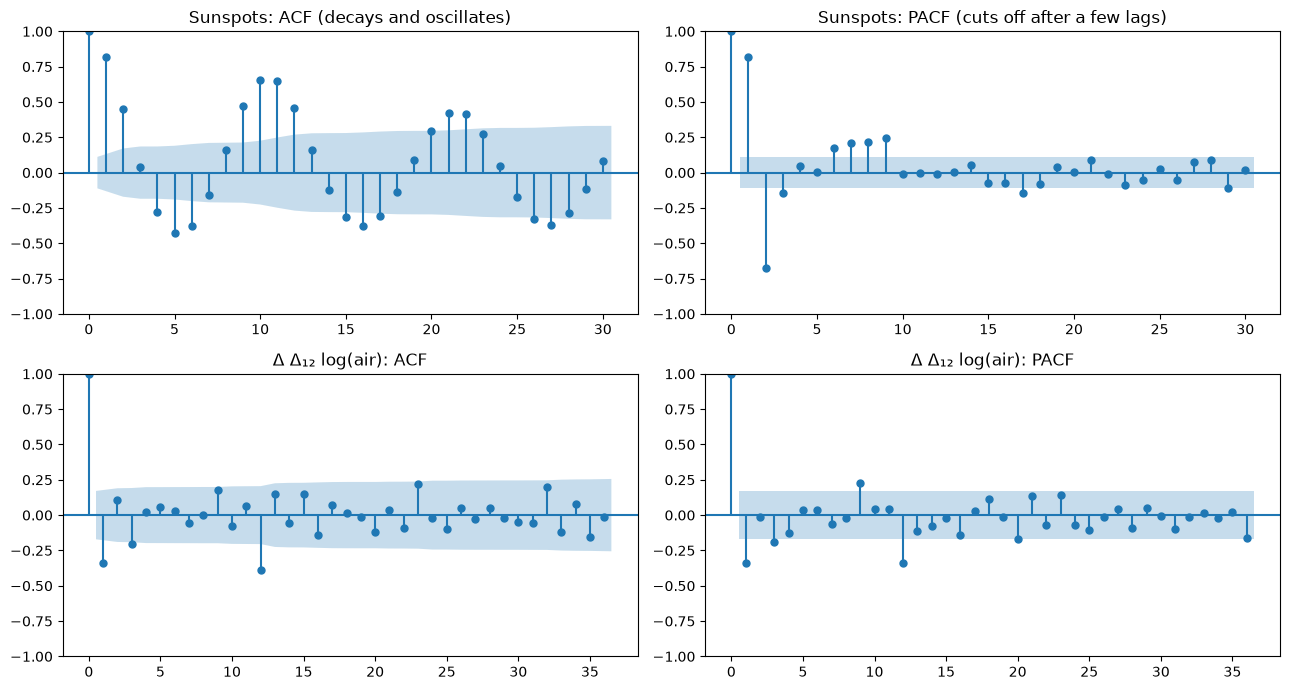

sunspots  PACF significant lags ≤ 12: [1, 2, 3, 6, 7, 8, 9]
airline   ACF  significant lags ≤ 24: [1, 3, 9, 12, 23]
airline   PACF significant lags ≤ 24: [1, 3, 9, 12]
✅ PACF(k) with method='ols' = last coefficient of an OLS AR(k) regression, for k = 1, 2, 3


In [13]:
airline_stationary = log_air.diff(12).diff().dropna()
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
plot_acf(sunspots, lags=30, ax=axes[0, 0], title="Sunspots: ACF (decays and oscillates)")
plot_pacf(sunspots, lags=30, ax=axes[0, 1], method="ywm", title="Sunspots: PACF (cuts off after a few lags)")
plot_acf(airline_stationary, lags=36, ax=axes[1, 0], title="Δ Δ₁₂ log(air): ACF")
plot_pacf(airline_stationary, lags=36, ax=axes[1, 1], method="ywm", title="Δ Δ₁₂ log(air): PACF")
plt.tight_layout()
plt.show()


def significant_lags(values, n, max_lag):
    band = 1.96 / np.sqrt(n)
    return [k for k in range(1, max_lag + 1) if abs(values[k]) > band]


print("sunspots  PACF significant lags ≤ 12:", significant_lags(pacf(sunspots, nlags=12, method="ywm"), len(sunspots), 12))
print("airline   ACF  significant lags ≤ 24:", significant_lags(acf(airline_stationary, nlags=24), len(airline_stationary), 24))
print("airline   PACF significant lags ≤ 24:", significant_lags(pacf(airline_stationary, nlags=24, method="ywm"), len(airline_stationary), 24))

# PACF at lag k really is the last coefficient of an AR(k) regression (fitted by OLS, with an intercept)
sun_values = sunspots.to_numpy()
for k in [1, 2, 3]:
    design = np.column_stack([np.ones(len(sun_values) - k)] + [sun_values[k - j:len(sun_values) - j] for j in range(1, k + 1)])
    last_coef = np.linalg.lstsq(design, sun_values[k:], rcond=None)[0][-1]
    assert np.isclose(last_coef, pacf(sunspots, nlags=k, method="ols")[k])
print("✅ PACF(k) with method='ols' = last coefficient of an OLS AR(k) regression, for k = 1, 2, 3")

How a forecaster reads these:
- **Sunspots:** the ACF oscillates slowly (the ~11-year cycle) while the PACF has significant spikes up to about lag 9 and then stays inside the band → an **AR model** of order around 9, a classic choice for this series (we fit AR(9) from scratch later).
- **Airline (after $\nabla\nabla_{12}$):** the largest ACF spikes are at **lag 1** and **lag 12** (a few others, such as lags 3 and 9, poke just outside the band) → a non-seasonal **MA(1)** and a seasonal **MA(1)** at lag 12. That is exactly the **airline model** SARIMA(0,1,1)(0,1,1)₁₂, which Box and Jenkins found on this very series.
- With 131 points, a few spikes will poke out of a 95% band by chance (about 1 in 20 lags). Don't chase every one; confirm with AIC and residual checks.

### ✍️ Your Turn

Compute the **lag-1 ACF** of the sunspots with the formula above (one overall mean, full-sample denominator). Store it in `acf1_manual`.

In [14]:
acf1_manual = None  # TODO: your code here
check("acf1_manual", acf1_manual, acf(sunspots, nlags=1)[1], hint="x = sun_values - sun_values.mean(); np.sum(x[1:] * x[:-1]) / np.sum(x ** 2)")

⏳ acf1_manual: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x = sun_values - sun_values.mean()
acf1_manual = np.sum(x[1:] * x[:-1]) / np.sum(x ** 2)
check("acf1_manual", acf1_manual, acf(sunspots, nlags=1)[1])
```

Using one overall mean and dividing by the full sum of squares keeps the ACF a valid (positive semi-definite) autocorrelation sequence. It gives slightly smaller values than `Series.autocorr`, which computes an ordinary Pearson correlation on the overlapping part.
</details>

> 💡 **Interview angle:** "How do you choose p and q for ARIMA?" — make the series stationary, then: PACF cutting off after $p$ suggests AR($p$), ACF cutting off after $q$ suggests MA($q$), spikes at the seasonal lag suggest seasonal terms. Then compare a **small** grid by AICc (same $d$ and $D$), and keep the simplest model whose residuals pass Ljung–Box. Automated `auto_arima` does the same search.

## 6. Baselines First: Naive, Seasonal Naive, Drift, Moving Average 🟢

Before any model, compute **benchmarks** that need no training. With $T$ the last training time and $h$ the horizon:

| Baseline | Forecast $\hat y_{T+h}$ | Captures |
|---|---|---|
| **Mean** | $\bar y$ (average of all training values) | nothing but the overall level |
| **Naive** | $y_T$ (the last value) | the current level; optimal for a random walk |
| **Seasonal naive** | $y_{T+h-m(k+1)}$, $k = \lfloor (h-1)/m \rfloor$ (same season last cycle) | level **and** seasonality |
| **Drift** | $y_T + h\,\dfrac{y_T - y_1}{T-1}$ (extend the line from first to last point) | level + average trend |
| **Moving average** | mean of the last $m$ values | a smoothed recent level |

**Why are they so hard to beat?** They have **no parameters to estimate**, so they can't overfit; they encode the two strongest signals (recent level and season); and they fail gracefully. Every model you build must beat the right baseline, **on the same windows**, or it isn't worth deploying. The MASE metric (Section 12) builds this comparison right into the score.

AirPassengers: train 1949-01 → 1958-12, test = next 24 months
                            MAE   RMSE
seasonal naive (m=12)      71.2   77.0
moving average (last 12)   77.8  103.2
drift                      91.6  115.7
naive (last value)        115.2  137.3
mean                      206.3  219.4

Bike (daily): train until 2012-11-05, validation = next 28 days
                            MAE    RMSE
naive (last value)        808.0  1170.0
drift                     828.0  1206.0
moving average (last 7)   939.0  1167.0
mean                     1110.0  1271.0
seasonal naive (m=7)     1310.0  1892.0


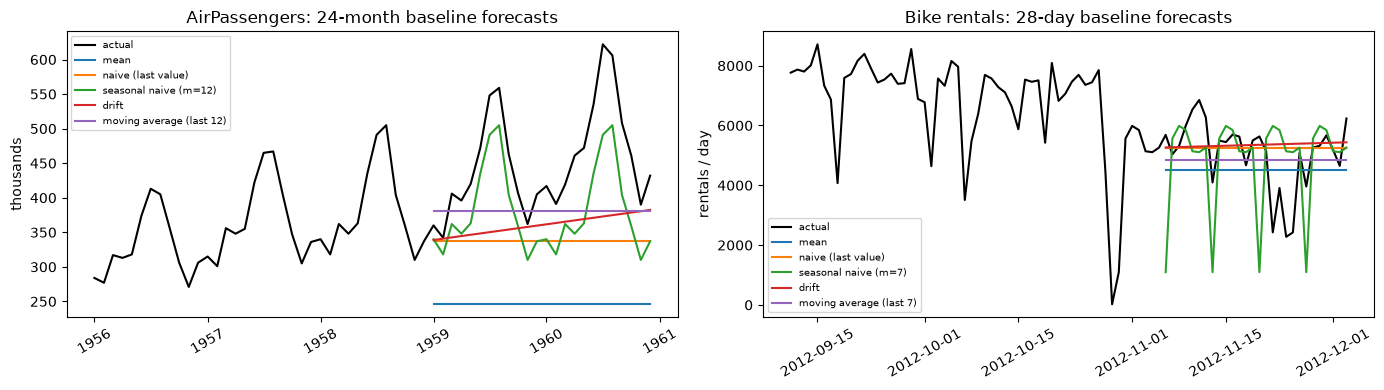

In [15]:
def baseline_forecasts(train, h, m):
    """Five classic benchmarks for the next h steps of a series (returns plain NumPy arrays)."""
    y = np.asarray(train, dtype=float)
    steps = np.arange(1, h + 1)
    return {
        "mean": np.full(h, y.mean()),
        "naive (last value)": np.full(h, y[-1]),
        f"seasonal naive (m={m})": y[len(y) - m + (steps - 1) % m],
        "drift": y[-1] + steps * (y[-1] - y[0]) / (len(y) - 1),
        f"moving average (last {m})": np.full(h, y[-m:].mean()),
    }


def score_table(actual, forecasts):
    rows = {name: {"MAE": mean_absolute_error(actual, f), "RMSE": root_mean_squared_error(actual, f)} for name, f in forecasts.items()}
    return pd.DataFrame(rows).T.sort_values("MAE")


AIR_TEST_MONTHS = 24
air_train, air_test = air.iloc[:-AIR_TEST_MONTHS], air.iloc[-AIR_TEST_MONTHS:]
air_baselines = baseline_forecasts(air_train, AIR_TEST_MONTHS, 12)
print(f"AirPassengers: train {air_train.index[0]:%Y-%m} → {air_train.index[-1]:%Y-%m}, test = next {AIR_TEST_MONTHS} months")
print(score_table(air_test, air_baselines).round(1).to_string())

bike_train_bl, bike_valid_bl = daily_dev["count"].iloc[:-28], daily_dev["count"].iloc[-28:]
bike_baselines = baseline_forecasts(bike_train_bl, 28, 7)
print(f"\nBike (daily): train until {bike_train_bl.index[-1]:%Y-%m-%d}, validation = next 28 days")
print(score_table(bike_valid_bl, bike_baselines).round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(air.loc["1956":], color="black", label="actual")
for name, f in air_baselines.items():
    axes[0].plot(air_test.index, f, lw=1.5, label=name)
axes[0].set(title="AirPassengers: 24-month baseline forecasts", ylabel="thousands")
axes[1].plot(daily_dev["count"].iloc[-84:], color="black", label="actual")
for name, f in bike_baselines.items():
    axes[1].plot(bike_valid_bl.index, f, lw=1.5, label=name)
axes[1].set(title="Bike rentals: 28-day baseline forecasts", ylabel="rentals / day")
for ax in axes:
    ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [16]:
# One window can mislead. Repeat the bike comparison over 12 different 28-day windows.
window_wins, window_maes = {}, []
for k in range(12, 0, -1):
    end = len(daily_dev) - 28 * (k - 1)
    train_k, valid_k = daily_dev["count"].iloc[:end - 28], daily_dev["count"].iloc[end - 28:end]
    maes = {name: mean_absolute_error(valid_k, f) for name, f in baseline_forecasts(train_k, 28, 7).items()}
    window_maes.append(maes)
    winner = min(maes, key=maes.get)
    window_wins[winner] = window_wins.get(winner, 0) + 1
window_table = pd.DataFrame(window_maes)
print("wins over 12 rolling 28-day windows:", window_wins)
print("average MAE across windows:\n", window_table.mean().sort_values().round(0).to_string())
best_on_average = window_table.mean().idxmin()
print(f"→ best on average: {best_on_average}; but the winner changed between windows, which is why we backtest on many windows (Section 12).")

wins over 12 rolling 28-day windows: {'mean': 1, 'seasonal naive (m=7)': 1, 'drift': 3, 'moving average (last 7)': 5, 'naive (last value)': 2}
average MAE across windows:
 moving average (last 7)     931.0
seasonal naive (m=7)       1174.0
drift                      1248.0
naive (last value)         1279.0
mean                       2141.0
→ best on average: moving average (last 7); but the winner changed between windows, which is why we backtest on many windows (Section 12).


On AirPassengers the seasonal naive wins clearly, because a strong, stable yearly pattern dominates. On daily bike rentals the weekly pattern is **weak compared with weather swings**: copying last week day by day also copies last week's rainy day, so smoother level-based baselines (the 7-day moving average, the naive forecast) often win, and in autumn, when demand falls week after week, the most recent level matters most. The ranking **changes from window to window**: a single validation window is a noisy judge.

### ✍️ Your Turn

Compute the **drift** forecast by hand for `y = [10, 12, 15, 18]` and `h = 3` (use the formula in the table). Store the 3 values in `drift_manual`.

In [17]:
y_small_series = np.array([10.0, 12.0, 15.0, 18.0])
drift_manual = None  # TODO: your code here
check("drift_manual", drift_manual, baseline_forecasts(y_small_series, 3, 2)["drift"],
      hint="slope = (y[-1] - y[0]) / (len(y) - 1); y[-1] + slope * np.arange(1, 4)")

⏳ drift_manual: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_small_series = np.array([10.0, 12.0, 15.0, 18.0])
slope = (y_small_series[-1] - y_small_series[0]) / (len(y_small_series) - 1)
drift_manual = y_small_series[-1] + slope * np.arange(1, 4)
check("drift_manual", drift_manual, baseline_forecasts(y_small_series, 3, 2)["drift"])
```

The slope is $8/3 \approx 2.67$ per step, so the forecasts are about 20.67, 23.33 and 26. Drift equals the naive forecast plus the average historical change.
</details>

> 💡 **Interview angle:** "How do you know your forecasting model is good?" — compare it with the **right naive baseline** (seasonal naive for seasonal data, naive for random-walk-like data) on the **same backtest windows**, and report a scaled metric like MASE where 1.0 means "as good as the baseline". Many published "improvements" disappear against a seasonal naive.

## 7. Exponential Smoothing: SES → Holt → Holt-Winters → ETS 🟡

**Simple exponential smoothing (SES)** forecasts with a weighted average of the past where weights **decay exponentially**:

$$\hat y_{T+h|T} = \ell_T, \qquad \ell_t = \alpha\, y_t + (1-\alpha)\,\ell_{t-1} = \alpha y_t + \alpha(1-\alpha) y_{t-1} + \alpha(1-\alpha)^2 y_{t-2} + \dots$$

$\alpha \in (0,1)$ is the **smoothing parameter**: close to 1 → follow the latest value (≈ naive); close to 0 → average over a long history (≈ mean). The forecast is **flat** for every horizon.

**Holt's linear method** adds a trend $b_t$:

$$\hat y_{T+h|T} = \ell_T + h\, b_T, \qquad \ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1} + b_{t-1}), \qquad b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta)\, b_{t-1}$$

A **damped** trend multiplies future trend steps by $\phi, \phi^2, \dots$ ($\phi \approx 0.8$–$0.98$) so long-horizon forecasts flatten out: often more accurate, because trends rarely continue forever.

**Holt-Winters** adds a seasonal term $s_t$ with period $m$ and smoothing $\gamma$. Additive version:

$$\hat y_{T+h|T} = \ell_T + h b_T + s_{T+h-m(k+1)}, \quad \ell_t = \alpha(y_t - s_{t-m}) + (1-\alpha)(\ell_{t-1}+b_{t-1}), \quad s_t = \gamma(y_t - \ell_{t-1} - b_{t-1}) + (1-\gamma)s_{t-m}$$

(The multiplicative version divides by the seasonal index instead of subtracting it.)

**ETS** (Error, Trend, Seasonal) turns these recipes into **statistical state-space models**, so parameters come from maximum likelihood, models can be compared by **AICc**, and **prediction intervals** are principled:

| Component | Options | Written |
|---|---|---|
| **E**rror | additive, multiplicative | A, M |
| **T**rend | none, additive, additive damped | N, A, Ad |
| **S**easonal | none, additive, multiplicative | N, A, M |

SES = ETS(A,N,N), Holt = ETS(A,A,N), additive Holt-Winters = ETS(A,A,A). Additive and multiplicative errors give the **same point forecasts** but different intervals. In `statsmodels`: `ExponentialSmoothing` (the classic recipes) and `ETSModel` (the statistical models).

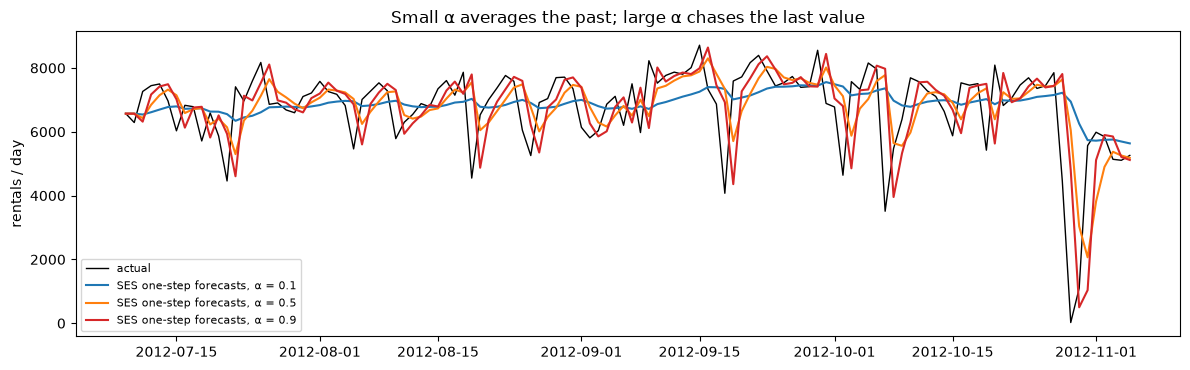

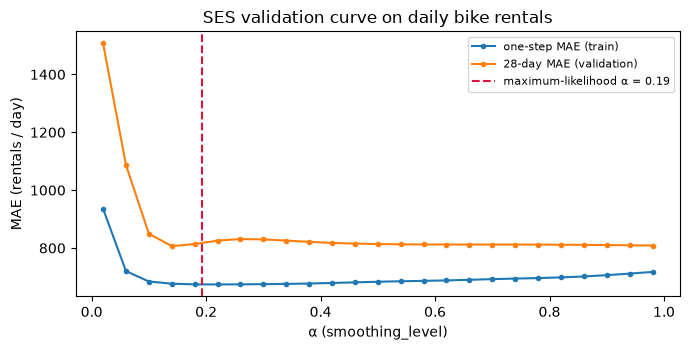

best α for one-step error: 0.22 | best α for the 28-day holdout: 0.14 | fitted α: 0.193
→ α is fitted for ONE-step accuracy; the best α for a 28-step flat forecast can differ. Choose the model on the horizon you care about.


In [18]:
ses_slice = bike_train_bl.iloc[-120:]
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(ses_slice, color="black", lw=1, label="actual")
for alpha_demo, color in [(0.1, "tab:blue"), (0.5, "tab:orange"), (0.9, "tab:red")]:
    fit_demo = SimpleExpSmoothing(ses_slice, initialization_method="known", initial_level=ses_slice.iloc[0]).fit(
        smoothing_level=alpha_demo, optimized=False)
    ax.plot(fit_demo.fittedvalues, color=color, lw=1.5, label=f"SES one-step forecasts, α = {alpha_demo}")
ax.set(title="Small α averages the past; large α chases the last value", ylabel="rentals / day")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Hyperparameter experiment: α vs one-step (in-sample) error and 28-day (holdout) error
alpha_grid = np.round(np.linspace(0.02, 0.98, 25), 2)
alpha_rows = []
for a in alpha_grid:
    fit_a = SimpleExpSmoothing(bike_train_bl, initialization_method="known", initial_level=bike_train_bl.iloc[0]).fit(
        smoothing_level=a, optimized=False)
    alpha_rows.append({"alpha": a, "one-step MAE (train)": mean_absolute_error(bike_train_bl, fit_a.fittedvalues),
                       "28-day MAE (validation)": mean_absolute_error(bike_valid_bl, fit_a.forecast(28))})
alpha_curve = pd.DataFrame(alpha_rows).set_index("alpha")
ses_optimized = SimpleExpSmoothing(bike_train_bl, initialization_method="estimated").fit()
alpha_hat = ses_optimized.params["smoothing_level"]

fig, ax = plt.subplots(figsize=(7, 3.6))
alpha_curve.plot(ax=ax, marker="o", ms=3)
ax.axvline(alpha_hat, ls="--", color="crimson", label=f"maximum-likelihood α = {alpha_hat:.2f}")
ax.set(xlabel="α (smoothing_level)", ylabel="MAE (rentals / day)", title="SES validation curve on daily bike rentals")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"best α for one-step error: {alpha_curve['one-step MAE (train)'].idxmin()} | best α for the 28-day holdout: "
      f"{alpha_curve['28-day MAE (validation)'].idxmin()} | fitted α: {alpha_hat:.3f}")
print("→ α is fitted for ONE-step accuracy; the best α for a 28-step flat forecast can differ. Choose the model on the horizon you care about.")

                                α     β     γ     φ  test MAE
model                                                        
SES                         1.000   NaN   NaN   NaN     115.3
Holt (linear trend)         1.000 0.000   NaN   NaN      91.6
Holt (damped trend)         1.000 0.000   NaN 0.994      99.7
Holt-Winters additive       0.237 0.000 0.763   NaN      31.1
Holt-Winters multiplicative 0.364 0.000 0.636   NaN      29.0
(seasonal naive on the same months: MAE 71.2)


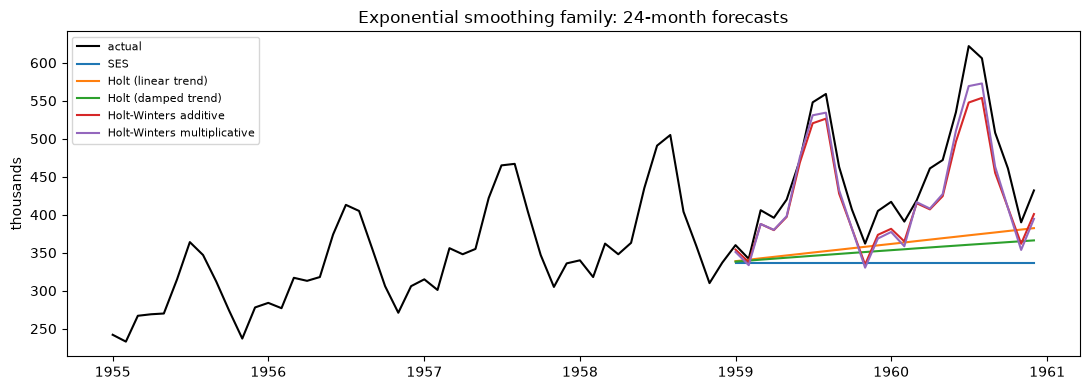

In [19]:
es_models = {
    "SES": SimpleExpSmoothing(air_train, initialization_method="estimated"),
    "Holt (linear trend)": Holt(air_train, initialization_method="estimated"),
    "Holt (damped trend)": Holt(air_train, damped_trend=True, initialization_method="estimated"),
    "Holt-Winters additive": ExponentialSmoothing(air_train, trend="add", seasonal="add", seasonal_periods=12, initialization_method="estimated"),
    "Holt-Winters multiplicative": ExponentialSmoothing(air_train, trend="add", seasonal="mul", seasonal_periods=12, initialization_method="estimated"),
}
es_rows, es_forecasts = [], {}
for name, model in es_models.items():
    fitted = model.fit()
    es_forecasts[name] = fitted.forecast(AIR_TEST_MONTHS)
    params = fitted.params
    es_rows.append({"model": name, "α": params["smoothing_level"], "β": params.get("smoothing_trend", np.nan),
                    "γ": params.get("smoothing_seasonal", np.nan), "φ": params.get("damping_trend", np.nan),
                    "test MAE": mean_absolute_error(air_test, es_forecasts[name])})
es_table = pd.DataFrame(es_rows).set_index("model")
print(es_table.to_string(float_format=lambda v: f"{v:.3f}" if abs(v) < 2 else f"{v:.1f}"))
print(f"(seasonal naive on the same months: MAE {mean_absolute_error(air_test, air_baselines['seasonal naive (m=12)']):.1f})")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(air.loc["1955":], color="black", label="actual")
for name, f in es_forecasts.items():
    ax.plot(f, lw=1.5, label=name)
ax.set(title="Exponential smoothing family: 24-month forecasts", ylabel="thousands")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

SES and Holt ignore seasonality, so they draw a flat line or a straight ramp through the zig-zag. Holt-Winters captures the season. The **multiplicative** version fits AirPassengers best, because its seasonal swings grow with the level (Section 3).

Now the statistical version: fit all 18 ETS combinations on the training months, rank them by **AICc** (AIC with a small-sample correction; lower is better; valid here because all models use the same untransformed data), and check the **prediction intervals** of the winner.

              AICc  converged  test MAE
model                                  
ETS(M,A,M)   877.1       True      48.3
ETS(A,N,M)   884.1       True      73.5
ETS(M,Ad,M)  884.9       True      64.6
ETS(M,N,M)   887.4       True      76.5
ETS(A,A,M)   923.7       True      29.7
ETS(A,Ad,M)  935.4       True      45.0
ETS(M,A,A)   937.6       True      37.9
ETS(M,Ad,A)  946.3       True      43.0

lowest AICc: ETS(M,A,M) | its test MAE rank among the 18 models: 7 (AICc was chosen WITHOUT looking at the test months)
ETS(M,A,M) interval coverage on the 24 test months: 80% interval → 46% | 95% interval → 96%
mean error (actual − forecast): +48.1 thousand → the point forecasts are biased LOW | P(at most 11 of 24 inside if the 80% intervals were right) = 0.000


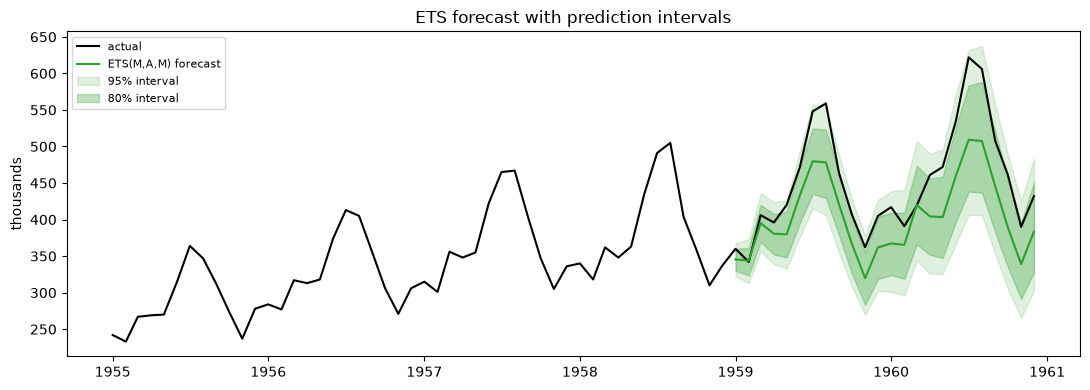

In [20]:
ets_rows, ets_fits = [], {}
for error, trend, damped, seasonal in itertools.product(["add", "mul"], [None, "add"], [False, True], [None, "add", "mul"]):
    if trend is None and damped:
        continue
    label = f"ETS({error[0].upper()},{'N' if trend is None else ('Ad' if damped else 'A')},{'N' if seasonal is None else seasonal[0].upper()})"
    fit = ETSModel(air_train, error=error, trend=trend, damped_trend=damped, seasonal=seasonal,
                   seasonal_periods=12 if seasonal else None).fit(disp=False)
    ets_fits[label] = fit
    ets_rows.append({"model": label, "AICc": fit.aicc, "converged": fit.mle_retvals.get("converged"),
                     "test MAE": mean_absolute_error(air_test, fit.forecast(AIR_TEST_MONTHS))})
ets_table = pd.DataFrame(ets_rows).set_index("model").sort_values("AICc")
print(ets_table.head(8).round(1).to_string())
best_ets_name = ets_table.index[0]
best_ets = ets_fits[best_ets_name]
print(f"\nlowest AICc: {best_ets_name} | its test MAE rank among the 18 models: "
      f"{int(ets_table['test MAE'].rank().loc[best_ets_name])} (AICc was chosen WITHOUT looking at the test months)")

start, end = len(air_train), len(air_train) + AIR_TEST_MONTHS - 1
# multiplicative-error ETS intervals come from simulation: a seeded generator makes them reproducible
ets_pred80 = best_ets.get_prediction(start=start, end=end, rng=np.random.default_rng(SEED)).summary_frame(alpha=0.20)
ets_pred95 = best_ets.get_prediction(start=start, end=end, rng=np.random.default_rng(SEED)).summary_frame(alpha=0.05)
cover80 = np.mean((air_test.to_numpy() >= ets_pred80["pi_lower"].to_numpy()) & (air_test.to_numpy() <= ets_pred80["pi_upper"].to_numpy()))
cover95 = np.mean((air_test.to_numpy() >= ets_pred95["pi_lower"].to_numpy()) & (air_test.to_numpy() <= ets_pred95["pi_upper"].to_numpy()))
print(f"{best_ets_name} interval coverage on the 24 test months: 80% interval → {cover80:.0%} | 95% interval → {cover95:.0%}")
hits80 = int(round(cover80 * AIR_TEST_MONTHS))
ets_bias = np.mean(air_test.to_numpy() - ets_pred80["mean"].to_numpy())
print(f"mean error (actual − forecast): {ets_bias:+.1f} thousand → the point forecasts are biased {'LOW' if ets_bias > 0 else 'HIGH'} | "
      f"P(at most {hits80} of 24 inside if the 80% intervals were right) = {stats.binom.cdf(hits80, AIR_TEST_MONTHS, 0.8):.3f}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(air.loc["1955":], color="black", label="actual")
ax.plot(ets_pred80.index, ets_pred80["mean"], color="tab:green", label=f"{best_ets_name} forecast")
ax.fill_between(ets_pred95.index, ets_pred95["pi_lower"], ets_pred95["pi_upper"], color="tab:green", alpha=0.15, label="95% interval")
ax.fill_between(ets_pred80.index, ets_pred80["pi_lower"], ets_pred80["pi_upper"], color="tab:green", alpha=0.3, label="80% interval")
ax.set(title="ETS forecast with prediction intervals", ylabel="thousands")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Intervals widen with the horizon (uncertainty accumulates) and, with multiplicative errors, with the level. Two honest lessons from the numbers above:
- **The lowest AICc is not guaranteed to be the best forecaster.** AICc rewards in-sample fit with a parameter penalty; compare its test-MAE rank.
- **Intervals are only as good as the point forecast.** When forecasts are biased, actuals fall outside even well-shaped intervals.

With 24 correlated test months, coverage is a rough check (24 × 0.8 = 19.2 expected hits); the binomial probability above says how surprising the observed count would be if the intervals were right. Backtests over many origins (Mini Project) are the proper test.

### ✍️ Your Turn

One SES update by hand: the current level is $\ell_{t-1} = 100$, $\alpha = 0.3$, and the new observation is $y_t = 130$. Compute the new level $\ell_t$ (which is also the next one-step forecast). Store it in `new_level`.

In [21]:
new_level = None  # TODO: your code here
check("new_level", new_level,
      SimpleExpSmoothing(np.array([130.0, 0.0]), initialization_method="known", initial_level=100.0).fit(smoothing_level=0.3, optimized=False).fittedvalues[1],
      hint="alpha * y + (1 - alpha) * previous_level")

⏳ new_level: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
new_level = 0.3 * 130 + (1 - 0.3) * 100
check("new_level", new_level,
      SimpleExpSmoothing(np.array([130.0, 0.0]), initialization_method="known", initial_level=100.0).fit(smoothing_level=0.3, optimized=False).fittedvalues[1])
```

$0.3 \times 130 + 0.7 \times 100 = 109$: the level moves 30% of the way toward the surprise. Equivalently $\ell_t = \ell_{t-1} + \alpha\,(y_t - \ell_{t-1})$, the "error-correction" form ETS models are written in.
</details>

> 💡 **Interview angle:** "Explain exponential smoothing and its parameters." — a weighted average with exponentially decaying weights; α controls how fast the level reacts, β the trend, γ the season, φ damps the trend. ETS adds an error model, so parameters come from maximum likelihood, models are chosen by AICc, and you get prediction intervals. Mention that a damped trend is a robust default for long horizons.

## 8. ARIMA, SARIMA, and SARIMAX 🟡

**ARIMA($p, d, q$)** combines three ideas, each in plain words:
- **AR($p$), autoregressive:** "today is a weighted sum of the last $p$ days" — $y_t = c + \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \varepsilon_t$.
- **I($d$), integrated:** "model the changes, not the levels" — difference the series $d$ times first.
- **MA($q$), moving average:** "today is corrected by the last $q$ surprises" — $y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}$. (Nothing to do with a rolling mean.)

With the **backshift operator** $B y_t = y_{t-1}$, the whole model is compact:

$$\underbrace{(1 - \phi_1 B - \dots - \phi_p B^p)}_{\text{AR}}\ \underbrace{(1-B)^d}_{\text{I}}\ y_t = c + \underbrace{(1 + \theta_1 B + \dots + \theta_q B^q)}_{\text{MA}}\ \varepsilon_t$$

**SARIMA($p,d,q$)($P,D,Q$)$_m$** multiplies in the same polynomials at the seasonal lag, $B^m$. The **airline model** SARIMA(0,1,1)(0,1,1)₁₂ says: take a regular and a seasonal difference, then correct with last month's surprise and last year's surprise:

$$(1-B)(1-B^{12})\log y_t = (1+\theta_1 B)(1+\Theta_1 B^{12})\,\varepsilon_t$$

**SARIMAX** adds e**X**ogenous regressors. In `statsmodels` it is a **regression with SARIMA errors**: $y_t = \beta^\top x_t + \eta_t$, where $\eta_t$ follows the SARIMA model. The $x_t$ must be **known for the future** (holidays, planned prices, or a weather *forecast*).

Everything is fitted by Gaussian **maximum likelihood** with a Kalman filter. Forecasts of a stationary ARMA part revert to its mean; differencing is what lets forecasts follow a trend.

statsmodels warnings during these fits: none
❌ AR(2) + constant, no differencing                  test MAE  23.89 ppm | forecast for 2001-12: 332.3 (actual 371.0)
✅ same AR(2) + constant after a seasonal difference  test MAE   1.19 ppm | forecast for 2001-12: 367.7 (actual 371.0)
✅ airline model (0,1,1)(0,1,1)₁₂                     test MAE   0.88 ppm | forecast for 2001-12: 371.1 (actual 371.0)


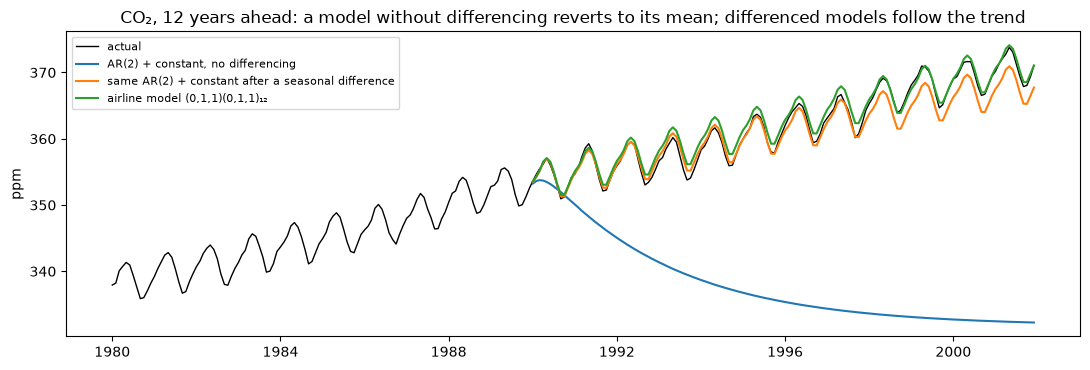

In [22]:
# Assumption experiment: force a STATIONARY model onto a trending series (monthly CO2), vs one with differencing
co2_train, co2_test = co2_monthly[:"1989-12"], co2_monthly["1990-01":]
arima_experiment = {}
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    arima_experiment["❌ AR(2) + constant, no differencing"] = SARIMAX(co2_train, order=(2, 0, 0), trend="c").fit(disp=False)
    arima_experiment["✅ same AR(2) + constant after a seasonal difference"] = SARIMAX(co2_train, order=(2, 0, 0), seasonal_order=(0, 1, 1, 12), trend="c").fit(disp=False)
    arima_experiment["✅ airline model (0,1,1)(0,1,1)₁₂"] = SARIMAX(co2_train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
print("statsmodels warnings during these fits:", sorted({str(w.message)[:70] for w in caught}) or "none")
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(co2_monthly["1980":], color="black", lw=1, label="actual")
for name, fit in arima_experiment.items():
    fc = fit.get_forecast(len(co2_test)).predicted_mean
    print(f"{name:52s} test MAE {mean_absolute_error(co2_test, fc):6.2f} ppm | forecast for {co2_test.index[-1]:%Y-%m}: "
          f"{fc.iloc[-1]:.1f} (actual {co2_test.iloc[-1]:.1f})")
    ax.plot(fc, lw=1.5, label=name.replace("❌ ", "").replace("✅ ", ""))
ax.set(title="CO₂, 12 years ahead: a model without differencing reverts to its mean; differenced models follow the trend", ylabel="ppm")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Choosing orders.** Section 5's ACF suggested MA(1) and seasonal MA(1) for $\nabla\nabla_{12}\log y$. We confirm with a **small grid** ($p, q \in \{0,1,2\}$, $P, Q \in \{0,1\}$, with $d = D = 1$ fixed so AICc values are comparable), on the log training months. Optimizer warnings are **recorded in the table**, not hidden: a model whose likelihood optimization didn't converge shouldn't win on AICc.

In [23]:
log_air_train = np.log(air_train)
grid_rows = []
start_time = time.perf_counter()
for p, q, P, Q in itertools.product([0, 1, 2], [0, 1, 2], [0, 1], [0, 1]):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        fit = SARIMAX(log_air_train, order=(p, 1, q), seasonal_order=(P, 1, Q, 12)).fit(disp=False)
    grid_rows.append({"order": f"({p},1,{q})({P},1,{Q})₁₂", "params": p + q + P + Q, "AICc": fit.aicc,
                      "converged": bool(fit.mle_retvals["converged"]), "warnings": len(caught)})
grid_table = pd.DataFrame(grid_rows).set_index("order").sort_values("AICc")
print(f"{len(grid_table)} SARIMA fits in {time.perf_counter() - start_time:.1f}s | "
      f"{int((~grid_table['converged']).sum())} did not converge, {int((grid_table['warnings'] > 0).sum())} raised warnings")
print(grid_table.head(8).round(2).to_string())
eligible = grid_table[grid_table["converged"]]
best_order_label = eligible.index[0]
airline_label = "(0,1,1)(0,1,1)₁₂"
print(f"\nbest converged model by AICc: {best_order_label} | airline model AICc {grid_table.loc[airline_label, 'AICc']:.2f} "
      f"(difference {grid_table.loc[airline_label, 'AICc'] - eligible['AICc'].iloc[0]:.2f})")
print("→ rule of thumb: AICc differences below ~2 are not meaningful; prefer the simpler model.")

36 SARIMA fits in 3.7s | 3 did not converge, 5 raised warnings
                  params    AICc  converged  warnings
order                                                
(0,1,1)(0,1,1)₁₂       2 -388.78       True         0
(1,1,0)(0,1,1)₁₂       2 -388.41       True         0
(0,1,1)(1,1,1)₁₂       3 -386.83       True         0
(0,1,2)(0,1,1)₁₂       3 -386.67       True         0
(1,1,0)(1,1,1)₁₂       3 -386.38       True         0
(1,1,1)(0,1,1)₁₂       3 -386.28       True         0
(2,1,0)(0,1,1)₁₂       3 -386.27       True         0
(2,1,1)(0,1,1)₁₂       4 -386.02      False         3

best converged model by AICc: (0,1,1)(0,1,1)₁₂ | airline model AICc -388.78 (difference 0.00)
→ rule of thumb: AICc differences below ~2 are not meaningful; prefer the simpler model.


chosen: SARIMA(0, 1, 1)(0, 1, 1)₁₂ on log(passengers)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3422      0.087     -3.922      0.000      -0.513      -0.171
ma.S.L12      -0.5405      0.105     -5.158      0.000      -0.746      -0.335
sigma2         0.0014      0.000      7.869      0.000       0.001       0.002


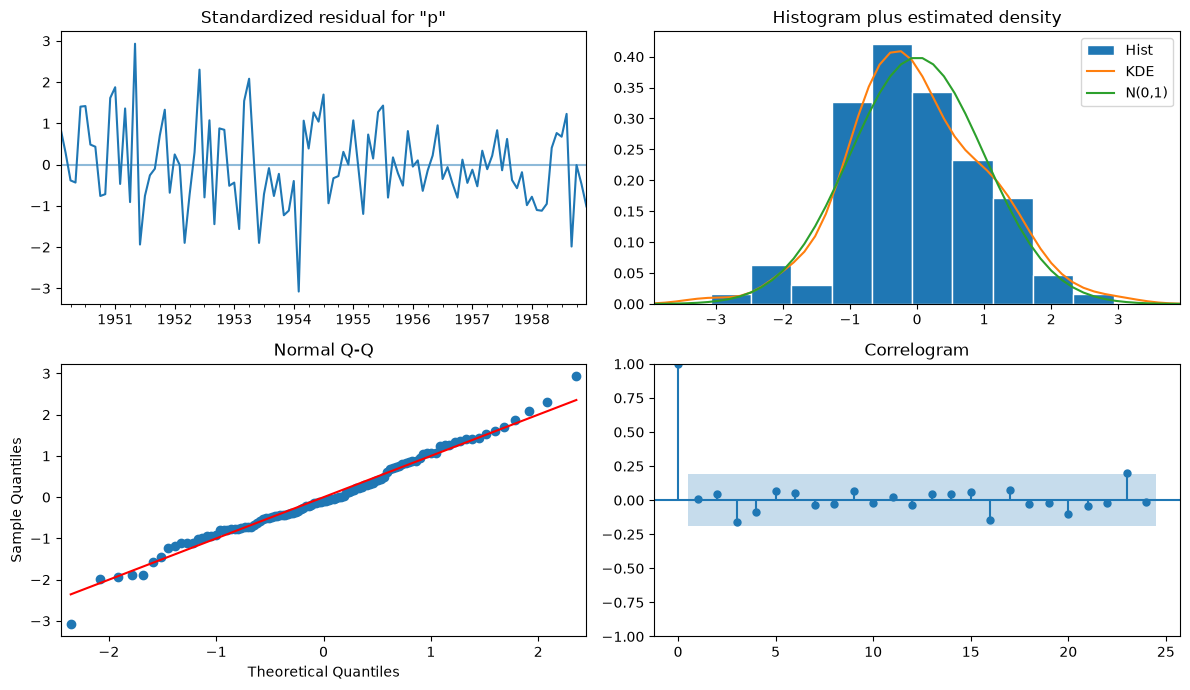

    lb_stat  lb_pvalue
12   6.0738     0.8090
24  17.9889     0.7066
→ Ljung–Box: no evidence of leftover autocorrelation; residuals look like white noise ✅


In [24]:
# keep the simpler airline model unless the best converged model is clearly better (AICc lower by 2 or more)
chosen_label = airline_label if grid_table.loc[airline_label, "AICc"] - eligible["AICc"].iloc[0] < 2 else best_order_label
order_digits = [int(ch) for ch in chosen_label.replace("₁₂", "") if ch.isdigit()]
chosen_order, chosen_seasonal = tuple(order_digits[:3]), tuple(order_digits[3:]) + (12,)
sarima_fit = SARIMAX(log_air_train, order=chosen_order, seasonal_order=chosen_seasonal).fit(disp=False)
print(f"chosen: SARIMA{chosen_order}{chosen_seasonal[:3]}₁₂ on log(passengers)")
print(sarima_fit.summary().tables[1])

fig = sarima_fit.plot_diagnostics(figsize=(12, 7), lags=24)
plt.tight_layout()
plt.show()

burn_in = chosen_order[1] + 12 * chosen_seasonal[1]              # first d + D·m residuals are start-up effects
resid = sarima_fit.resid.iloc[burn_in:]
n_arma = sum(chosen_order[::2]) + sum(chosen_seasonal[:3:2])
ljung = acorr_ljungbox(resid, lags=[12, 24], model_df=n_arma)
print(ljung.round(4).to_string())
print("→ Ljung–Box: no evidence of leftover autocorrelation; residuals look like white noise ✅" if (ljung["lb_pvalue"] > 0.05).all()
      else "→ Ljung–Box rejects white noise: some autocorrelation is left in the residuals; consider more terms")

24-month test MAE (thousands of passengers):
 SARIMA(0, 1, 1)(0, 1, 1) on log    39.45
ETS ETS(M,A,M)                     48.34
seasonal naive                     71.25
SARIMA interval coverage: 80% → 96% | 95% → 100% → wider than needed on these 24 months (24 correlated months: a rough check only)


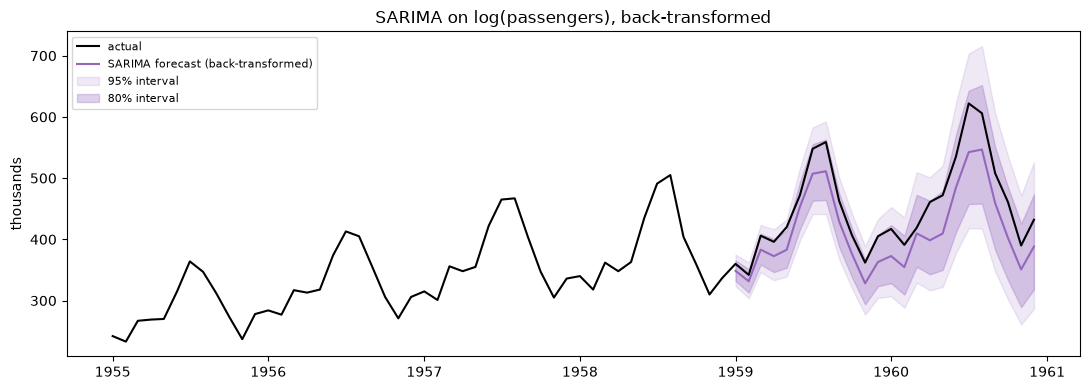

In [25]:
sarima_forecast = sarima_fit.get_forecast(AIR_TEST_MONTHS)
log80, log95 = sarima_forecast.summary_frame(alpha=0.20), sarima_forecast.summary_frame(alpha=0.05)
sarima_point = np.exp(log80["mean"])                                 # exp of the mean log forecast = a MEDIAN forecast
inside80 = (air_test >= np.exp(log80["mean_ci_lower"])) & (air_test <= np.exp(log80["mean_ci_upper"]))
inside95 = (air_test >= np.exp(log95["mean_ci_lower"])) & (air_test <= np.exp(log95["mean_ci_upper"]))
comparison = pd.Series({"seasonal naive": mean_absolute_error(air_test, air_baselines["seasonal naive (m=12)"]),
                        f"ETS {best_ets_name}": mean_absolute_error(air_test, best_ets.forecast(AIR_TEST_MONTHS)),
                        f"SARIMA{chosen_order}{chosen_seasonal[:3]} on log": mean_absolute_error(air_test, sarima_point)}).sort_values()
print("24-month test MAE (thousands of passengers):\n", comparison.round(2).to_string())
print(f"SARIMA interval coverage: 80% → {inside80.mean():.0%} | 95% → {inside95.mean():.0%} → "
      + ("wider than needed on these 24 months" if inside80.mean() > 0.9 else ("too narrow on these 24 months" if inside80.mean() < 0.7 else "close to nominal"))
      + " (24 correlated months: a rough check only)")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(air.loc["1955":], color="black", label="actual")
ax.plot(sarima_point, color="tab:purple", label="SARIMA forecast (back-transformed)")
ax.fill_between(log95.index, np.exp(log95["mean_ci_lower"]), np.exp(log95["mean_ci_upper"]), color="tab:purple", alpha=0.15, label="95% interval")
ax.fill_between(log80.index, np.exp(log80["mean_ci_lower"]), np.exp(log80["mean_ci_upper"]), color="tab:purple", alpha=0.3, label="80% interval")
ax.set(title="SARIMA on log(passengers), back-transformed", ylabel="thousands")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

`statsmodels` labels the forecast interval columns `mean_ci_lower`/`mean_ci_upper`, but for `get_forecast` they are **prediction** intervals for new observations (they include the future shocks $\varepsilon$). Because we modelled $\log y$, $\exp$ of the forecast is the **median** of the passenger count; the interval endpoints transform correctly because $\exp$ is monotonic.

**SARIMAX with exogenous regressors.** On daily bike rentals, holidays, working days and weather obviously matter. We fit the same SARIMA error structure with and without them on the bike training days, and forecast the 28 validation days. Rentals are divided by 1,000 and the regressors rescaled so the optimizer converges cleanly.

⚠️ We plug in the **observed** weather of the forecast days, as if we had a perfect weather forecast. That flatters any model that uses weather; Pitfall 5 measures by how much.

In [26]:
def bike_exog(frame):
    """Regressors known (or forecast) for each day, rescaled to similar magnitudes."""
    return pd.DataFrame({"holiday": frame["holiday"].astype(float), "workingday": frame["workingday"].astype(float),
                         "temp": frame["temp"] / 10, "temp_sq": (frame["temp"] / 10) ** 2,
                         "humidity": frame["humidity"], "windspeed": frame["windspeed"] / 10}, index=frame.index)


SARIMAX_ORDER, SARIMAX_SEASONAL = (1, 1, 1), (1, 0, 1, 7)
bike_tr_frame, bike_va_frame = daily_dev.iloc[:-28], daily_dev.iloc[-28:]
sarimax_results = {}
for label, use_exog in [("SARIMA (no regressors)", False), ("SARIMAX (holiday, workingday, weather)", True)]:
    exog_tr = bike_exog(bike_tr_frame) if use_exog else None
    exog_va = bike_exog(bike_va_frame) if use_exog else None
    start_time = time.perf_counter()
    fit = SARIMAX(bike_tr_frame["count"] / 1000, exog=exog_tr, order=SARIMAX_ORDER, seasonal_order=SARIMAX_SEASONAL).fit(disp=False, maxiter=200)
    fc = fit.get_forecast(28, exog=exog_va).summary_frame(alpha=0.20) * 1000
    inside = (bike_va_frame["count"] >= fc["mean_ci_lower"]) & (bike_va_frame["count"] <= fc["mean_ci_upper"])
    sarimax_results[label] = {"fit": fit, "forecast": fc}
    print(f"{label:40s} converged {fit.mle_retvals['converged']} | validation MAE {mean_absolute_error(bike_va_frame['count'], fc['mean']):5.0f} | "
          f"80% coverage {inside.mean():.0%} | {time.perf_counter() - start_time:.1f}s")
print(f"(seasonal naive on the same 28 days: MAE {mean_absolute_error(bike_valid_bl, bike_baselines['seasonal naive (m=7)']):.0f})")

sarimax_fit = sarimax_results["SARIMAX (holiday, workingday, weather)"]["fit"]
exog_names = list(bike_exog(bike_tr_frame).columns)
effects = pd.DataFrame({"coef (thousand rentals)": sarimax_fit.params[exog_names], "p-value": sarimax_fit.pvalues[exog_names]})
print("\n", effects.round(4).to_string())
peak_temp = -sarimax_fit.params["temp"] / (2 * sarimax_fit.params["temp_sq"]) * 10
print(f"→ the quadratic temperature effect peaks around {peak_temp:.0f} °C: demand rises with warmth, then falls in the heat"
      if sarimax_fit.params["temp_sq"] < 0 else "→ no inverted-U temperature effect found")

SARIMA (no regressors)                   converged True | validation MAE   889 | 80% coverage 82% | 0.1s


SARIMAX (holiday, workingday, weather)   converged True | validation MAE   684 | 80% coverage 82% | 1.1s
(seasonal naive on the same 28 days: MAE 1310)

             coef (thousand rentals)  p-value
holiday                     -0.1833   0.3555
workingday                   0.0428   0.7054
temp                         3.7072   0.0000
temp_sq                     -0.6763   0.0000
humidity                    -3.5369   0.0000
windspeed                   -0.5091   0.0000
→ the quadratic temperature effect peaks around 27 °C: demand rises with warmth, then falls in the heat


### ✍️ Your Turn

Compute the **Ljung–Box statistic** at lag 12 by hand for the SARIMA residuals `resid`:
$Q = n(n+2)\sum_{k=1}^{12} \dfrac{\hat\rho_k^2}{n-k}$, where $\hat\rho_k$ comes from `acf(resid, nlags=12)` and $n$ = `len(resid)`. Store it in `lb_q12`.

In [27]:
lb_q12 = None  # TODO: your code here
check("lb_q12", lb_q12, acorr_ljungbox(resid, lags=[12])["lb_stat"].iloc[0],
      hint="rho = acf(resid, nlags=12); n = len(resid); n * (n + 2) * np.sum(rho[1:] ** 2 / (n - np.arange(1, 13)))")

⏳ lb_q12: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rho = acf(resid, nlags=12)
n_resid = len(resid)
lb_q12 = n_resid * (n_resid + 2) * np.sum(rho[1:] ** 2 / (n_resid - np.arange(1, 13)))
check("lb_q12", lb_q12, acorr_ljungbox(resid, lags=[12])["lb_stat"].iloc[0])
```

Under white noise, $Q$ follows roughly a $\chi^2$ distribution with $12 - (\text{number of ARMA parameters})$ degrees of freedom; that's what `model_df` subtracts. A large $Q$ means the residuals still contain predictable structure.
</details>

> 💡 **Interview angle:** "Walk me through fitting an ARIMA model." — stabilize variance (log/Box-Cox) → choose $d$, $D$ with plots + ADF/KPSS → read ACF/PACF for candidate orders → compare a small grid by AICc (same differencing) → check residuals (Ljung–Box, ACF of residuals, normality) → forecast with intervals and back-transform → **backtest against seasonal naive**. For regressors use SARIMAX, and only with regressors known at forecast time.

## 9. Forecasting as Supervised Learning: Lags, Rolling Windows, Calendar 🟡

Any regression model can forecast if we build a table where **each row is a time point $t$**, the **target** is $y_t$ (or $y_{t+h}$), and every **feature is something known before the forecast is made**:

| Feature family | Examples | Leak-free recipe |
|---|---|---|
| **Lags** | $y_{t-1}, y_{t-7}, y_{t-28}$ | `y.shift(k)` with $k \ge 1$ (and $k \ge h$ for a direct $h$-step model) |
| **Rolling statistics** | mean / std of the last 7 or 28 days | `y.shift(1).rolling(7).mean()` — **shift first**, then roll |
| **Expanding statistics** | long-run average so far | `y.shift(1).expanding().mean()` |
| **Calendar** | day of week, month, day of year as $\sin/\cos$ | from the timestamp: always known |
| **Events** | holidays, promotions, paydays, school terms | a calendar you control |
| **Exogenous** | weather, prices | only if available **at forecast time** (forecasts, planned values) |

Gradient boosting (LightGBM, from [Gradient Boosting](10_Gradient_Boosting.ipynb)) is the usual model: it handles non-linear effects and interactions ("hot **and** a weekend"), missing values and many series. More feature ideas are in [Feature Engineering & Selection](16_Feature_Engineering_and_Selection.ipynb).

In this section every forecast is **one step ahead** (tomorrow, knowing today). Section 10 extends it to 28 days.

In [28]:
LAGS = [1, 2, 3, 7, 14, 21, 28]


def calendar_features(index):
    doy = index.dayofyear.to_numpy()
    return pd.DataFrame({"dayofweek": index.dayofweek.to_numpy(), "month": index.month.to_numpy(),
                         "doy_sin": np.sin(2 * np.pi * doy / 365.25), "doy_cos": np.cos(2 * np.pi * doy / 365.25)}, index=index)


def known_future_features(frame):
    """Features known in advance for each target day: calendar, holiday flags, weather (as a stand-in for a weather forecast)."""
    return calendar_features(frame.index).assign(holiday=frame["holiday"].astype(int).to_numpy(),
                                                 workingday=frame["workingday"].astype(int).to_numpy(),
                                                 temp=frame["temp"].to_numpy(), humidity=frame["humidity"].to_numpy(),
                                                 windspeed=frame["windspeed"].to_numpy())


def make_lag_features(frame):
    """One-step-ahead features: row t only uses counts from days before t."""
    y = frame["count"].astype(float)
    past = y.shift(1)
    X = pd.DataFrame({f"lag_{k}": y.shift(k) for k in LAGS}, index=frame.index)
    X["roll7_mean"] = past.rolling(7).mean()
    X["roll28_mean"] = past.rolling(28).mean()
    X["roll7_std"] = past.rolling(7).std()
    X["expanding_mean"] = past.expanding(min_periods=28).mean()
    return pd.concat([X, known_future_features(frame)], axis=1)


features_dev = make_lag_features(daily_dev).iloc[28:]          # the first 28 days lack full lag history
target_dev = daily_dev["count"].iloc[28:].astype(float)
probe_day = features_dev.index[100]
assert np.isclose(features_dev.loc[probe_day, "roll7_mean"], daily_dev["count"].loc[probe_day - pd.Timedelta(days=7):probe_day - pd.Timedelta(days=1)].mean())
print(f"✅ roll7_mean on {probe_day:%Y-%m-%d} = mean of the 7 PREVIOUS days (no peeking) | feature table {features_dev.shape}")
print(features_dev.iloc[:2].T.round(2).to_string())

✅ roll7_mean on 2011-05-09 = mean of the 7 PREVIOUS days (no peeking) | feature table (675, 20)
date            2011-01-29  2011-01-30
lag_1              1167.00     1098.00
lag_2               431.00     1167.00
lag_3               506.00      431.00
lag_7               981.00      986.00
lag_14             1248.00     1204.00
lag_21              959.00      822.00
lag_28              985.00      801.00
roll7_mean         1067.43     1084.14
roll28_mean        1231.93     1235.96
roll7_std           533.49      532.17
expanding_mean     1231.93     1227.31
dayofweek             5.00        6.00
month                 1.00        1.00
doy_sin               0.48        0.49
doy_cos               0.88        0.87
holiday               0.00        0.00
workingday            0.00        0.00
temp                  8.06        8.88
humidity              0.65        0.72
windspeed             9.74        4.96


In [29]:
valid_start, check_start = features_dev.index[-56], features_dev.index[-28]
fit_rows, valid_rows, check_rows = features_dev.index < valid_start, (features_dev.index >= valid_start) & (features_dev.index < check_start), features_dev.index >= check_start
lag_cols = [c for c in features_dev.columns if c.startswith(("lag_", "roll", "expanding"))]
known_cols = list(known_future_features(daily_dev.iloc[:1]).columns)
feature_sets = {"calendar + weather only": known_cols,
                "+ short lags (1, 2, 3, 7)": known_cols + ["lag_1", "lag_2", "lag_3", "lag_7"],
                "+ all lags and rolling stats": known_cols + lag_cols}

# Hyperparameter experiment (validation = the 28 days before the check window)
hp_rows = []
for set_name, cols in feature_sets.items():
    for leaves in [7, 15, 31]:
        model = lgb.LGBMRegressor(**(LGB_PARAMS | {"num_leaves": leaves})).fit(features_dev.loc[fit_rows, cols], target_dev[fit_rows])
        hp_rows.append({"features": set_name, "num_leaves": leaves,
                        "validation MAE": mean_absolute_error(target_dev[valid_rows], model.predict(features_dev.loc[valid_rows, cols]))})
hp_table = pd.DataFrame(hp_rows).pivot(index="features", columns="num_leaves", values="validation MAE")
print("one-step validation MAE by feature set × num_leaves:\n", hp_table.round(0).to_string())
best_set, best_leaves = pd.DataFrame(hp_rows).sort_values("validation MAE").iloc[0][["features", "num_leaves"]]
print(f"→ chosen on validation: '{best_set}' with num_leaves={best_leaves}")

# Refit on fit + validation rows, then score the untouched check window once
train_rows = fit_rows | valid_rows
chosen_cols = feature_sets[best_set]
gbm_one_step = lgb.LGBMRegressor(**(LGB_PARAMS | {"num_leaves": int(best_leaves)})).fit(features_dev.loc[train_rows, chosen_cols], target_dev[train_rows])
one_step_scores = pd.Series({
    "naive (yesterday)": mean_absolute_error(target_dev[check_rows], features_dev.loc[check_rows, "lag_1"]),
    "seasonal naive (same weekday last week)": mean_absolute_error(target_dev[check_rows], features_dev.loc[check_rows, "lag_7"]),
    "LightGBM one-step": mean_absolute_error(target_dev[check_rows], gbm_one_step.predict(features_dev.loc[check_rows, chosen_cols])),
}).sort_values()
print("\none-step MAE on the check window (last 28 dev days):\n", one_step_scores.round(0).to_string())
importance = pd.Series(gbm_one_step.booster_.feature_importance("gain"), index=chosen_cols).sort_values(ascending=False)
print("\ntop features by total gain:", (importance / importance.sum()).head(6).round(3).to_dict())

one-step validation MAE by feature set × num_leaves:
 num_leaves                        7       15      31
features                                            
+ all lags and rolling stats   866.0  1027.0  1151.0
+ short lags (1, 2, 3, 7)      991.0  1048.0  1075.0
calendar + weather only       2201.0  2205.0  2267.0
→ chosen on validation: '+ all lags and rolling stats' with num_leaves=7



one-step MAE on the check window (last 28 dev days):
 LightGBM one-step                           831.0
naive (yesterday)                           855.0
seasonal naive (same weekday last week)    1495.0

top features by total gain: {'roll7_mean': 0.377, 'lag_1': 0.17, 'temp': 0.09, 'humidity': 0.089, 'expanding_mean': 0.085, 'roll28_mean': 0.067}


In [30]:
# ❌ A classic leak: a short rolling mean that INCLUDES the current day's count
leak_params = LGB_PARAMS | {"num_leaves": int(best_leaves)}
leak_results_s9 = {}
for label, feature in [("✅ mean of the 2 previous days: y.shift(1).rolling(2).mean()", daily_dev["count"].shift(1).rolling(2).mean()),
                       ("❌ mean of today and yesterday: y.rolling(2).mean()", daily_dev["count"].rolling(2).mean())]:
    X_leak = features_dev[chosen_cols].assign(roll2_mean=feature.reindex(features_dev.index))
    model = lgb.LGBMRegressor(**leak_params).fit(X_leak[train_rows], target_dev[train_rows])
    leak_results_s9[label] = mean_absolute_error(target_dev[check_rows], model.predict(X_leak[check_rows]))
    print(f"{label:62s} check MAE {leak_results_s9[label]:.0f}")
honest_mae, leaky_mae = leak_results_s9.values()
print(f"→ the leaky feature looks {honest_mae / leaky_mae:.1f}× better, and it is impossible in production: today's count isn't known when you forecast today."
      if leaky_mae < honest_mae else "→ the leak didn't help on this window, but it would still be invalid in production.")

✅ mean of the 2 previous days: y.shift(1).rolling(2).mean()    check MAE 825


❌ mean of today and yesterday: y.rolling(2).mean()             check MAE 253
→ the leaky feature looks 3.3× better, and it is impossible in production: today's count isn't known when you forecast today.


The leaky feature contains half of today's answer: together with `lag_1` (yesterday's count), the trees can almost reconstruct today. In production that feature doesn't exist yet at forecast time, and the model collapses. **Always compute rolling features on `y.shift(1)` (or `shift(h)`)**, and sanity-check a few rows by hand, as the `assert` above does.

### ✍️ Your Turn

For `s = pd.Series([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])`, build a **3-day rolling mean that doesn't peek**: the value at position $t$ must average positions $t-3, t-2, t-1$. Store the resulting Series in `roll3_no_peek` (leading values will be NaN).

In [31]:
s = pd.Series([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
roll3_no_peek = None  # TODO: your code here
check("roll3_no_peek", roll3_no_peek, [np.nan, np.nan, np.nan, 2.0, 3.0, 4.0], hint="shift first, then roll: s.shift(1).rolling(3).mean()")

⏳ roll3_no_peek: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
s = pd.Series([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
roll3_no_peek = s.shift(1).rolling(3).mean()
check("roll3_no_peek", roll3_no_peek, [np.nan, np.nan, np.nan, 2.0, 3.0, 4.0])
```

`s.rolling(3).mean()` alone would give `[nan, nan, 2, 3, 4, 5]`: each value would include the current day, which is the leak.
</details>

> 💡 **Interview angle:** "How do you use XGBoost/LightGBM for forecasting?" — reframe as supervised learning: target $y_{t+h}$, features known at time $t$ (lags ≥ $h$, rolling stats on shifted values, calendar, holidays, known-in-advance covariates); validate with time-ordered splits; handle multi-step with a recursive or direct strategy; detrend the target if the series trends. Mention leakage checks on rolling features.

## 10. Multi-Step Forecasting: Recursive vs Direct 🔴

One-step models are easy. But planners need **28 days**. Two main strategies:

```
RECURSIVE (one model, fed its own predictions)          DIRECT (one model per horizon)
  ŷ(T+1) = f(y_T, y_T-1, ...)                             ŷ(T+1)  = f₁(y_T, y_T-1, ...)
  ŷ(T+2) = f(ŷ(T+1), y_T, ...)   ← uses a prediction      ŷ(T+2)  = f₂(y_T, y_T-1, ...)
  ŷ(T+3) = f(ŷ(T+2), ŷ(T+1), ...)                         ...
                                                           ŷ(T+28) = f₂₈(y_T, y_T-1, ...)
```

| | Recursive | Direct |
|---|---|---|
| Models | 1 | $H$ (here 28) |
| Errors | **compound**: early mistakes feed later steps | no feedback; each model trained for its own horizon |
| Features | must be recomputable from predictions (lags, rolling means) | fixed at the forecast origin $T$ (lags $\ge h$) |
| Cost | cheap to train, $H$ sequential predictions | $H$ trainings |
| Weakness | bias grows with horizon | ignores dependence between horizons; later models have fewer training rows |

Hybrids exist: **DirRec** (direct models that also take earlier predictions), **MIMO** (one model outputs the whole vector), and "**horizon as a feature**" (one model, $h$ is a column; used in the Mini Project).

Both strategies below use the same LightGBM settings, the same known-in-advance features for the target day (calendar, holidays, weather), and the same **4 rolling-origin folds** of 28 days on the development data.

✅ first recursive step matches the one-step feature pipeline
training + prediction time over 4 folds: recursive 1.3s | direct 34.6s

MAE by horizon (4 folds × 28 days):
 horizon                      days 1–7  days 8–14  days 15–21  days 22–28  all 28 days
strategy                                                                             
direct LightGBM (28 models)     549.0      599.0       937.0       900.0        746.0
recursive LightGBM              660.0      616.0      1041.0       765.0        770.0
seasonal naive                 1135.0     1015.0      1348.0      1387.0       1221.0


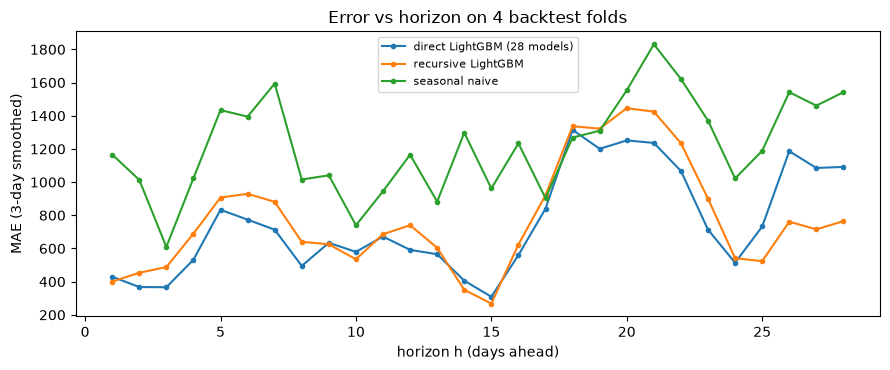

→ best overall: direct LightGBM (28 models) | MAE growth from week 1 to week 4: recursive +106, direct +352
→ direct took 26.9× longer than recursive (28 trainings per fold).


In [32]:
DIRECT_LAGS = 14
HORIZON = 28
MS_PARAMS = LGB_PARAMS | {"n_estimators": 150, "learning_rate": 0.08}      # a bit faster: we train 116 models


def recursive_forecast(model, history, future_frame, feature_names):
    """Predict len(future_frame) days one at a time, appending each prediction to the history."""
    hist = list(np.asarray(history, dtype=float))
    known = known_future_features(future_frame)
    preds = []
    for date in future_frame.index:
        past = np.asarray(hist)
        row = {f"lag_{k}": past[-k] for k in LAGS}
        row.update(roll7_mean=past[-7:].mean(), roll28_mean=past[-28:].mean(), roll7_std=past[-7:].std(ddof=1), expanding_mean=past.mean())
        row.update(known.loc[date].to_dict())
        pred = float(model.predict(pd.DataFrame([row])[feature_names])[0])
        preds.append(pred)
        hist.append(pred)
    return np.array(preds)


def direct_training_frame(frame, h):
    """Rows = forecast origins t. Features: counts up to t + target-day known features. Target: count at t + h."""
    y = frame["count"].astype(float)
    origin = pd.DataFrame({f"y_lag{k}": y.shift(k) for k in range(DIRECT_LAGS)}, index=frame.index)   # y_t, y_(t-1), …
    origin["roll28_mean"] = y.rolling(28).mean()
    target_day = known_future_features(frame).shift(-h).add_prefix("target_")
    return pd.concat([origin, target_day], axis=1), y.shift(-h)


def direct_forecast(train_frame, future_frame, params):
    y = train_frame["count"].astype(float)
    origin_now = {f"y_lag{k}": y.iloc[-1 - k] for k in range(DIRECT_LAGS)} | {"roll28_mean": y.iloc[-28:].mean()}
    target_days = known_future_features(future_frame).add_prefix("target_")
    preds = []
    for h in range(1, len(future_frame) + 1):
        X_h, y_h = direct_training_frame(train_frame, h)
        usable = y_h.notna() & X_h.notna().all(axis=1)
        model_h = lgb.LGBMRegressor(**params).fit(X_h[usable], y_h[usable])
        row = pd.DataFrame([origin_now | target_days.iloc[h - 1].to_dict()])[X_h.columns]
        preds.append(float(model_h.predict(row)[0]))
    return np.array(preds)


all_feature_names = lag_cols + known_cols
strategy_rows = []
timings = {"recursive": 0.0, "direct": 0.0}
for fold, (tr_idx, te_idx) in enumerate(TimeSeriesSplit(n_splits=4, test_size=HORIZON).split(daily_dev)):
    tr_frame, te_frame = daily_dev.iloc[tr_idx], daily_dev.iloc[te_idx]
    start_time = time.perf_counter()
    feats_tr = make_lag_features(tr_frame).iloc[28:]
    rec_model = lgb.LGBMRegressor(**MS_PARAMS).fit(feats_tr[all_feature_names], tr_frame["count"].iloc[28:].astype(float))
    if fold == 0:   # sanity check: the first recursive step builds exactly the row make_lag_features would build
        full_feats = make_lag_features(pd.concat([tr_frame, te_frame.iloc[:1]]))
        rec_first = recursive_forecast(rec_model, tr_frame["count"], te_frame.iloc[:1], all_feature_names)[0]
        assert np.isclose(rec_first, rec_model.predict(full_feats[all_feature_names].iloc[[-1]])[0])
    rec_pred = recursive_forecast(rec_model, tr_frame["count"], te_frame, all_feature_names)
    timings["recursive"] += time.perf_counter() - start_time
    start_time = time.perf_counter()
    dir_pred = direct_forecast(tr_frame, te_frame, MS_PARAMS)
    timings["direct"] += time.perf_counter() - start_time
    snaive_pred = baseline_forecasts(tr_frame["count"], HORIZON, 7)["seasonal naive (m=7)"]
    actual = te_frame["count"].to_numpy(dtype=float)
    for strategy, pred in [("recursive LightGBM", rec_pred), ("direct LightGBM (28 models)", dir_pred), ("seasonal naive", snaive_pred)]:
        strategy_rows += [{"fold": fold, "h": h + 1, "strategy": strategy, "abs_error": abs(actual[h] - pred[h])} for h in range(HORIZON)]
    last_fold = {"model": rec_model, "train": tr_frame, "test": te_frame}           # reused in Pitfall 2
print("✅ first recursive step matches the one-step feature pipeline")
print(f"training + prediction time over 4 folds: recursive {timings['recursive']:.1f}s | direct {timings['direct']:.1f}s")

strategy_errors = pd.DataFrame(strategy_rows)
strategy_errors["horizon"] = pd.cut(strategy_errors["h"], bins=[0, 7, 14, 21, 28], labels=["days 1–7", "days 8–14", "days 15–21", "days 22–28"])
horizon_table = strategy_errors.pivot_table(index="strategy", columns="horizon", values="abs_error", aggfunc="mean", observed=True)
horizon_table["all 28 days"] = strategy_errors.groupby("strategy")["abs_error"].mean()
print("\nMAE by horizon (4 folds × 28 days):\n", horizon_table.sort_values("all 28 days").round(0).to_string())

fig, ax = plt.subplots(figsize=(9, 3.8))
for strategy, grp in strategy_errors.groupby("strategy"):
    ax.plot(grp.groupby("h")["abs_error"].mean().rolling(3, center=True, min_periods=1).mean(), marker="o", ms=3, label=strategy)
ax.set(xlabel="horizon h (days ahead)", ylabel="MAE (3-day smoothed)", title="Error vs horizon on 4 backtest folds")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

rec_growth = horizon_table.loc["recursive LightGBM", "days 22–28"] - horizon_table.loc["recursive LightGBM", "days 1–7"]
dir_growth = horizon_table.loc["direct LightGBM (28 models)", "days 22–28"] - horizon_table.loc["direct LightGBM (28 models)", "days 1–7"]
print(f"→ best overall: {horizon_table['all 28 days'].idxmin()} | MAE growth from week 1 to week 4: recursive {rec_growth:+.0f}, direct {dir_growth:+.0f}")
print(f"→ direct took {timings['direct'] / timings['recursive']:.1f}× longer than recursive (28 trainings per fold).")

What to take away:
- **In theory**, recursive errors compound (each prediction becomes a lag for the next step), while direct models don't compound but each one sees fewer training rows and ignores what the other horizons predict.
- **In practice**, the difficulty of each week also varies (weather, holidays, the autumn decline), so error doesn't grow smoothly with the horizon. Read the growth numbers above instead of assuming the textbook shape.
- Direct needed 28 trainings per fold; with thousands of series that cost matters.
- Four folds of 28 days is a small sample: differences of a few percent are within noise. That is why Section 12 is about evaluation.

> 💡 **Interview angle:** "Recursive or direct multi-step forecasting?" — recursive: one model, cheap, but errors compound and features must be regenerated from predictions (and evaluating it with true lags is a leak). Direct: $H$ models, no compounding, higher cost, and each model uses lags ≥ its horizon. In practice try both (or horizon-as-a-feature / MIMO) and pick with a rolling-origin backtest, per horizon bucket.

## 11. Trees Can't Extrapolate: Trends and Detrending 🟡

A decision tree predicts the **average training target in a leaf**. A forest or boosted ensemble adds up leaf values learned from training targets. So a tree-based model can **never predict outside the range of targets it has seen** (for boosting, roughly the range of the training targets). On a trending series, that means forecasts hit a ceiling.

```
  y │                               ● ● ●   actual keeps rising
    │                         ● ● ●
    │ training range ends ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─   tree forecasts stay flat here
    │           ● ● ● ● ● ●
    │ ● ● ● ● ●
    └───────────────────────────────────────────▶ time
```

**The fix is to model something that doesn't trend**, then add the trend back:
- **differences:** predict $y_t - y_{t-1}$ or the seasonal difference $y_t - y_{t-m}$, then add the lag back;
- **ratios / log differences:** predict $y_t / \text{recent level}$ (good for multiplicative growth);
- **detrend with a linear model** and let the tree model the residual;
- or use `linear_tree=True` in LightGBM (linear models in the leaves).

Experiment on monthly CO₂ (a steady upward trend): train until 1989, forecast 1990–2001. Every prediction is made **12 months ahead** (all features are at least 12 months old), so no recursion is needed.

training max 355.6 ppm | test max 373.8 ppm
                                                test MAE (ppm)  highest forecast  share of forecasts above the training max
✅ LightGBM on the 12-month change (+ lag back)           0.607           373.136                                      0.833
linear regression on the level                           0.929           374.618                                      0.896
seasonal naive (y 12 months ago)                         1.498           371.650                                      0.750
❌ LightGBM on the level                                  8.197           354.254                                      0.000


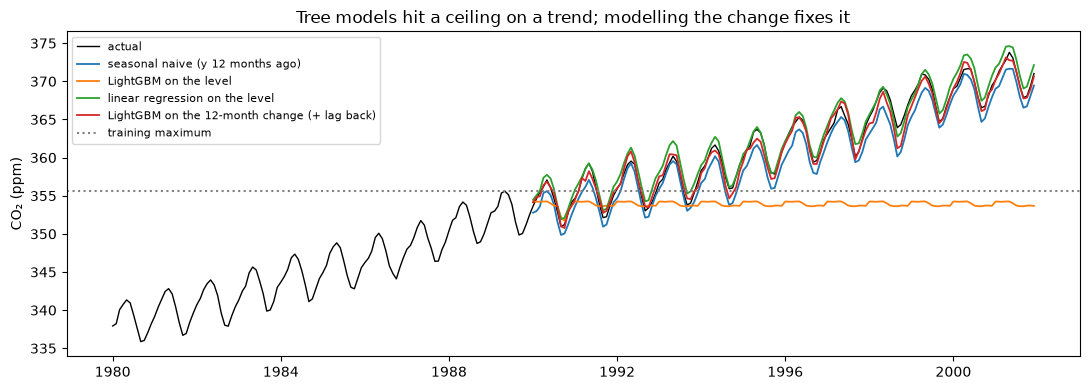

→ LightGBM on the level never forecasts above 354.3 ppm, while CO₂ reached 373.8. Detrending cuts its MAE from 8.20 to 0.61 ppm.


In [33]:
co2_frame = pd.DataFrame({"y": co2_monthly, "lag_12": co2_monthly.shift(12), "lag_13": co2_monthly.shift(13),
                          "lag_24": co2_monthly.shift(24), "month": co2_monthly.index.month})
co2_frame["d"] = co2_frame["y"] - co2_frame["lag_12"]                  # seasonal difference: change over 12 months
co2_frame["d_lag12"] = co2_frame["lag_12"] - co2_frame["lag_24"]
co2_frame["d_lag13"] = co2_frame["lag_13"] - co2_monthly.shift(25)
co2_frame = co2_frame.dropna()
co2_tr, co2_te = co2_frame[co2_frame.index < "1990-01-01"], co2_frame[co2_frame.index >= "1990-01-01"]
level_cols, diff_cols = ["lag_12", "lag_13", "lag_24", "month"], ["d_lag12", "d_lag13", "month"]

co2_preds = {
    "seasonal naive (y 12 months ago)": co2_te["lag_12"].to_numpy(),
    "❌ LightGBM on the level": lgb.LGBMRegressor(**LGB_PARAMS).fit(co2_tr[level_cols], co2_tr["y"]).predict(co2_te[level_cols]),
    "linear regression on the level": LinearRegression().fit(co2_tr[level_cols], co2_tr["y"]).predict(co2_te[level_cols]),
    "✅ LightGBM on the 12-month change (+ lag back)": lgb.LGBMRegressor(**LGB_PARAMS).fit(co2_tr[diff_cols], co2_tr["d"]).predict(co2_te[diff_cols]) + co2_te["lag_12"].to_numpy(),
}
train_max = co2_tr["y"].max()
co2_table = pd.DataFrame({name: {"test MAE (ppm)": mean_absolute_error(co2_te["y"], pred), "highest forecast": pred.max(),
                                 "share of forecasts above the training max": np.mean(pred > train_max)}
                          for name, pred in co2_preds.items()}).T.sort_values("test MAE (ppm)")
print(f"training max {train_max:.1f} ppm | test max {co2_te['y'].max():.1f} ppm")
print(co2_table.round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(co2_frame["y"]["1980":], color="black", lw=1, label="actual")
for name, pred in co2_preds.items():
    ax.plot(co2_te.index, pred, lw=1.3, label=name.replace("❌ ", "").replace("✅ ", ""))
ax.axhline(train_max, ls=":", color="gray", label="training maximum")
ax.set(title="Tree models hit a ceiling on a trend; modelling the change fixes it", ylabel="CO₂ (ppm)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"→ LightGBM on the level never forecasts above {co2_preds['❌ LightGBM on the level'].max():.1f} ppm, while CO₂ reached {co2_te['y'].max():.1f}. "
      f"Detrending cuts its MAE from {co2_table.loc['❌ LightGBM on the level', 'test MAE (ppm)']:.2f} to "
      f"{co2_table.loc['✅ LightGBM on the 12-month change (+ lag back)', 'test MAE (ppm)']:.2f} ppm.")

The linear model extrapolates happily (a weighted sum of lags can keep growing), and the detrended LightGBM predicts the **12-month change** (always inside the training range of changes) and adds it to last year's value. The same logic applies to prices with inflation, growing user bases, and bike demand growing from 2011 to 2012: the Mini Project divides by the recent level for this reason.

### ✍️ Your Turn

For the **detrended** LightGBM forecasts, what share of test forecasts is above the training maximum? Store it in `share_above_detrended`.

In [34]:
share_above_detrended = None  # TODO: your code here
check("share_above_detrended", share_above_detrended, co2_table.loc["✅ LightGBM on the 12-month change (+ lag back)", "share of forecasts above the training max"],
      hint="np.mean(co2_preds['✅ LightGBM on the 12-month change (+ lag back)'] > train_max)")

⏳ share_above_detrended: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
share_above_detrended = np.mean(co2_preds["✅ LightGBM on the 12-month change (+ lag back)"] > train_max)
check("share_above_detrended", share_above_detrended, co2_table.loc["✅ LightGBM on the 12-month change (+ lag back)", "share of forecasts above the training max"])
print(f"{share_above_detrended:.0%}")
```

Most detrended forecasts exceed the old maximum, because the model adds a *change* to a value that is itself new. The raw-level model's share is 0%.
</details>

> 💡 **Interview angle:** "Can gradient boosting forecast a series with a trend?" — not directly: tree outputs are bounded by the training targets, so forecasts flatten at the historical maximum. Model differences, growth ratios, or residuals from a linear trend (or use linear leaves), then add the trend back. Always plot forecasts beyond the training range.

## 12. Evaluation Done Right: Metrics, Backtesting, Leakage 🟡

### Metrics

With actuals $y$, forecasts $\hat y$, errors $e = y - \hat y$ over the test points:

| Metric | Formula | Scale | Watch out |
|---|---|---|---|
| **MAE** | $\text{mean}\lvert e\rvert$ | target units | optimal forecast = median; can't compare across series with different scales |
| **RMSE** | $\sqrt{\text{mean}(e^2)}$ | target units | optimal forecast = mean; dominated by big misses |
| **MAPE** | $100\cdot\text{mean}\lvert e / y\rvert$ | % | **explodes when $y$ is near 0**, undefined at 0, rewards under-forecasting |
| **sMAPE** | $100\cdot\text{mean}\dfrac{2\lvert e\rvert}{\lvert y\rvert + \lvert \hat y\rvert}$ | 0–200% | still unstable near 0; not really symmetric |
| **WAPE** | $\sum\lvert e\rvert / \sum\lvert y\rvert$ | % | robust business-friendly alternative to MAPE (volume-weighted) |
| **MASE** | $\dfrac{\text{MAE}_{\text{test}}}{\frac{1}{T-m}\sum_{t=m+1}^{T}\lvert y_t - y_{t-m}\rvert}$ | unitless | **< 1 means better than the in-sample seasonal naive**; comparable across series (Hyndman & Koehler, 2006) |

MASE divides by the in-sample MAE of the (seasonal) naive forecast computed on the **training** data, so it never divides by zero unless the training series is constant, and it's directly readable as "how much better than the baseline".

In [35]:
def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))


def mase(y_true, y_pred, y_train, m=1):
    """MAE of the forecast divided by the in-sample MAE of the seasonal naive (lag m) on the training series."""
    y_train = np.asarray(y_train, dtype=float)
    scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    return mean_absolute_error(y_true, y_pred) / scale


# MAPE near zero: hourly rentals with a "same hour last week" forecast, on the development period
hourly_dev = hourly_full.loc[:daily_dev.index[-1] + pd.Timedelta(hours=23)]
hourly_eval = pd.DataFrame({"actual": hourly_dev, "forecast": hourly_dev.shift(168)}).loc["2012-01-01":].dropna()
ape = 100 * (hourly_eval["actual"] - hourly_eval["forecast"]).abs() / hourly_eval["actual"]
by_hour = pd.DataFrame({"mean rentals": hourly_eval.groupby(hourly_eval.index.hour)["actual"].mean(),
                        "MAE": (hourly_eval["actual"] - hourly_eval["forecast"]).abs().groupby(hourly_eval.index.hour).mean(),
                        "MAPE %": ape.groupby(hourly_eval.index.hour).mean()})
print(by_hour.round(1).T.to_string())
worst = hourly_eval.assign(APE=ape).nlargest(3, "APE")
print("\nthe three largest percentage errors:\n", worst.round(0).to_string())
train_hours = hourly_dev.loc[:"2011-12-31"].dropna().to_numpy()
overall = {"MAE": mean_absolute_error(hourly_eval["actual"], hourly_eval["forecast"]),
           "MAPE %": ape.mean(), "sMAPE %": smape(hourly_eval["actual"], hourly_eval["forecast"]),
           "WAPE %": 100 * (hourly_eval["actual"] - hourly_eval["forecast"]).abs().sum() / hourly_eval["actual"].sum(),
           "MASE (m=168, scale from 2011)": mase(hourly_eval["actual"], hourly_eval["forecast"], hourly_dev.loc[:"2011-12-31"].ffill().to_numpy(), m=168)}
print("\noverall:", {k: round(v, 2) for k, v in overall.items()})
night, day = by_hour.loc[2:5, "MAPE %"].mean(), by_hour.loc[10:18, "MAPE %"].mean()
print(f"→ MAPE at 02:00–05:59 ({night:.0f}%) vs 10:00–18:59 ({day:.0f}%): tiny night counts dominate the average although their absolute errors are small.")

timestamp       0     1      2     3     4     5     6      7      8      9      10     11     12     13     14     15     16     17     18     19     20     21     22     23
mean rentals  66.8  41.2   27.5  13.9   7.3  25.3  96.3  272.5  461.4  279.8  222.4  267.2  324.2  324.3  306.2  320.6  398.4  590.1  545.0  399.7  288.8  216.9  164.6  109.9
MAE           23.6  15.9   11.3   6.1   3.3   7.2  23.7   68.9   91.0   54.1   47.9   61.8   79.7   86.2   86.0   91.8  100.0  143.7  131.4   97.6   72.3   58.6   47.6   34.7
MAPE %        47.1  61.6  101.9  65.8  62.9  44.0  45.4   42.2   36.0   27.2   31.2   34.6   32.8   37.1   38.6   39.6   38.0   43.5   40.4   40.7   39.6   42.4   41.9   40.0

the three largest percentage errors:
                      actual  forecast     APE
timestamp                                    
2012-11-14 02:00:00     1.0      74.0  7300.0
2012-04-22 17:00:00    27.0     623.0  2207.0
2012-04-22 21:00:00    11.0     229.0  1982.0

overall: {'MAE': 60.41, 'MAPE 

In [36]:
# MAPE rewards under-forecasting: scale the same forecast by a constant and see which scale each metric prefers
scales = np.round(np.linspace(0.5, 1.5, 41), 3)
scale_scores = pd.DataFrame({"MAE": [mean_absolute_error(hourly_eval["actual"], c * hourly_eval["forecast"]) for c in scales],
                             "MAPE": [mean_absolute_percentage_error(hourly_eval["actual"], c * hourly_eval["forecast"]) for c in scales]}, index=scales)
print(f"forecast multiplier that minimizes MAE: {scale_scores['MAE'].idxmin():.3f} | that minimizes MAPE: {scale_scores['MAPE'].idxmin():.3f}")
print("→ optimizing MAPE pushes forecasts systematically LOW (costly stock-outs if you plan inventory with it).")

forecast multiplier that minimizes MAE: 0.975 | that minimizes MAPE: 0.850
→ optimizing MAPE pushes forecasts systematically LOW (costly stock-outs if you plan inventory with it).


### Rolling-origin backtesting

A single holdout window is one noisy sample. A **rolling-origin** (or **expanding-window**) backtest repeats "train on everything before the origin, forecast the next $H$ steps" for several origins, and averages. scikit-learn's `TimeSeriesSplit` builds these folds:
- `test_size=28` → each test window is 28 steps;
- `n_splits=5` → 5 origins, the last one ending at the end of the data;
- `gap=7` → 7 steps are skipped between train and test (e.g. data arrives a week late, or you forecast a week before the period starts);
- `max_train_size=365` → a **sliding** window instead of an expanding one (useful when old data is no longer representative).

fold 0: train 2011-01-01 → 2012-07-09 (556 days) | gap 7 days | test 2012-07-17 → 2012-08-13
fold 1: train 2011-01-01 → 2012-08-06 (584 days) | gap 7 days | test 2012-08-14 → 2012-09-10
fold 2: train 2011-01-01 → 2012-09-03 (612 days) | gap 7 days | test 2012-09-11 → 2012-10-08
fold 3: train 2011-01-01 → 2012-10-01 (640 days) | gap 7 days | test 2012-10-09 → 2012-11-05
fold 4: train 2011-01-01 → 2012-10-29 (668 days) | gap 7 days | test 2012-11-06 → 2012-12-03


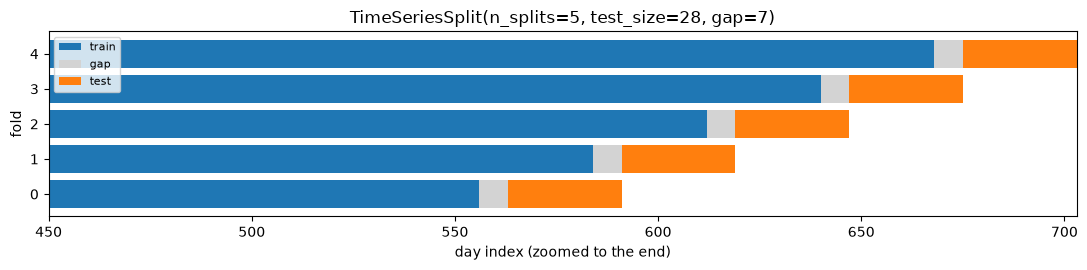

In [37]:
tscv_demo = TimeSeriesSplit(n_splits=5, test_size=28, gap=7)
fig, ax = plt.subplots(figsize=(11, 2.8))
for fold, (tr_idx, te_idx) in enumerate(tscv_demo.split(daily_dev)):
    ax.barh(fold, tr_idx[-1] - tr_idx[0] + 1, left=tr_idx[0], color="tab:blue", label="train" if fold == 0 else None)
    ax.barh(fold, te_idx[0] - tr_idx[-1] - 1, left=tr_idx[-1] + 1, color="lightgray", label="gap" if fold == 0 else None)
    ax.barh(fold, len(te_idx), left=te_idx[0], color="tab:orange", label="test" if fold == 0 else None)
    print(f"fold {fold}: train {daily_dev.index[tr_idx[0]]:%Y-%m-%d} → {daily_dev.index[tr_idx[-1]]:%Y-%m-%d} ({len(tr_idx)} days) | "
          f"gap {te_idx[0] - tr_idx[-1] - 1} days | test {daily_dev.index[te_idx[0]]:%Y-%m-%d} → {daily_dev.index[te_idx[-1]]:%Y-%m-%d}")
ax.set(xlim=(450, len(daily_dev)), xlabel="day index (zoomed to the end)", ylabel="fold", title="TimeSeriesSplit(n_splits=5, test_size=28, gap=7)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Leakage demo 1 — random K-fold vs time-ordered folds.** We estimate the one-step MAE of the Section 9 LightGBM from the data **before** `valid_start`, with shuffled `KFold` and with `TimeSeriesSplit`. Then we measure the real error on the **56 days that follow**, training on all earlier rows. Which estimate is honest?

In [38]:
X_past, y_past = features_dev.loc[fit_rows, all_feature_names], target_dev[fit_rows]
X_future, y_future = features_dev.loc[~fit_rows, all_feature_names], target_dev[~fit_rows]
cv_estimates = {}
for label, splitter in [("❌ shuffled KFold(5)", KFold(5, shuffle=True, random_state=SEED)),
                        ("✅ TimeSeriesSplit(5, test_size=28)", TimeSeriesSplit(n_splits=5, test_size=28))]:
    fold_maes = []
    for tr_idx, te_idx in splitter.split(X_past):
        model = lgb.LGBMRegressor(**LGB_PARAMS).fit(X_past.iloc[tr_idx], y_past.iloc[tr_idx])
        fold_maes.append(mean_absolute_error(y_past.iloc[te_idx], model.predict(X_past.iloc[te_idx])))
    cv_estimates[label] = np.mean(fold_maes)
real_future_mae = mean_absolute_error(y_future, lgb.LGBMRegressor(**LGB_PARAMS).fit(X_past, y_past).predict(X_future))
for label, est in cv_estimates.items():
    print(f"{label:36s} estimated MAE {est:6.0f} | off from the real future by {est - real_future_mae:+6.0f}")
print(f"{'real error on the next 56 days':36s}           {real_future_mae:6.0f}")
closest = min(cv_estimates, key=lambda k: abs(cv_estimates[k] - real_future_mae))
print(f"→ closest to reality: {closest}. Shuffled folds let the model see the days around every test day.")

❌ shuffled KFold(5)                  estimated MAE    437 | off from the real future by   -523
✅ TimeSeriesSplit(5, test_size=28)   estimated MAE    747 | off from the real future by   -213
real error on the next 56 days                    960
→ closest to reality: ✅ TimeSeriesSplit(5, test_size=28). Shuffled folds let the model see the days around every test day.


**Leakage demo 2 — a feature computed on the full series.** A "typical demand for this day of the year" profile sounds harmless. Computed over the whole data set (2011 and 2012), the value for 15 November 2012 is the average of 15 November 2011 **and 15 November 2012, the very day being predicted**. The honest version uses only what was known at the time: the same day last year (lag 364). Both models train on the 2012 days before the evaluation window and use only calendar/weather features plus that one column, so the effect is easy to see.

In [39]:
count_dev = daily_dev["count"].astype(float)
profile_features = known_future_features(daily_dev).assign(
    doy_profile_leaky=count_dev.groupby(daily_dev.index.dayofyear).transform("mean").to_numpy(),   # averages 2011 AND 2012
    same_day_last_year=count_dev.shift(364).to_numpy())                                           # only the past
eval_rows = daily_dev.index >= features_dev.index[-56]
fit_2012 = (daily_dev.index >= "2012-01-01") & ~eval_rows                                         # lag 364 exists from here on
base_cols = list(known_future_features(daily_dev.iloc[:1]).columns)
leak_results = {}
for label, extra in [("❌ day-of-year profile averaged over the full data", "doy_profile_leaky"),
                     ("✅ same day last year (lag 364)", "same_day_last_year")]:
    cols = base_cols + [extra]
    model = lgb.LGBMRegressor(**LGB_PARAMS).fit(profile_features.loc[fit_2012, cols], count_dev[fit_2012])
    leak_results[label] = mean_absolute_error(count_dev[eval_rows], model.predict(profile_features.loc[eval_rows, cols]))
    print(f"{label:52s} MAE on the last 56 dev days: {leak_results[label]:.0f}")
leaky_mae2, honest_mae2 = leak_results.values()
print(f"→ the leaky profile looks {honest_mae2 / leaky_mae2:.1f}× better because half of each value IS the answer; in production this year's value doesn't exist yet."
      if leaky_mae2 < honest_mae2 else "→ the leak didn't help on this window, but it would still be invalid in production.")

❌ day-of-year profile averaged over the full data    MAE on the last 56 dev days: 513


✅ same day last year (lag 364)                       MAE on the last 56 dev days: 1379
→ the leaky profile looks 2.7× better because half of each value IS the answer; in production this year's value doesn't exist yet.


The same trap appears whenever something is **fitted on the full series** before splitting: scalers, STL decompositions, target encodings, detrending lines, outlier thresholds, even imputation. Fit them inside each training window.

### ✍️ Your Turn

Implement **WAPE** (weighted absolute percentage error, as a fraction): $\sum\lvert y - \hat y\rvert / \sum\lvert y\rvert$ for the hourly evaluation (`hourly_eval["actual"]`, `hourly_eval["forecast"]`). Store it in `wape`.

In [40]:
wape = None  # TODO: your code here
check("wape", wape, mean_absolute_error(hourly_eval["actual"], hourly_eval["forecast"]) / hourly_eval["actual"].abs().mean(),
      hint="np.sum(np.abs(actual - forecast)) / np.sum(np.abs(actual))")

⏳ wape: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
actual, forecast = hourly_eval["actual"].to_numpy(), hourly_eval["forecast"].to_numpy()
wape = np.sum(np.abs(actual - forecast)) / np.sum(np.abs(actual))
check("wape", wape, mean_absolute_error(hourly_eval["actual"], hourly_eval["forecast"]) / hourly_eval["actual"].abs().mean())
print(f"WAPE = {wape:.1%} vs MAPE = {ape.mean():.1f}%")
```

WAPE = MAE / mean(|y|): big hours count more than tiny ones, so it stays stable when some actuals are near zero. That's why retail teams often prefer it to MAPE.
</details>

> 💡 **Interview angle:** "How would you evaluate a forecasting model?" — rolling-origin backtest with several origins (`TimeSeriesSplit` with `test_size` = horizon and a `gap` for data latency), errors reported **per horizon bucket**, a scale-free metric such as MASE against seasonal naive (or WAPE for business), interval coverage for probabilistic forecasts, and a leakage audit: every feature and preprocessing step fitted only on data available at each origin.

## 13. Probabilistic Forecasts: Quantile LightGBM and Coverage 🔴

A point forecast says "5,200 rentals". A planner needs "**between 4,300 and 6,000, 80% of the time**" to size stock and staff. Two ways to get there:
- **Model-based intervals** (ETS, SARIMA): assume an error distribution and propagate it through the model.
- **Quantile regression**: train a model to predict the $\tau$-quantile directly by minimizing the **pinball (quantile) loss**:

$$L_\tau(y, \hat q) = \begin{cases} \tau\,(y - \hat q) & y \ge \hat q \\ (1-\tau)\,(\hat q - y) & y < \hat q \end{cases}$$

For $\tau = 0.9$, under-predicting costs 9× more than over-predicting, so the optimum sits above 90% of outcomes. In LightGBM: `objective="quantile", alpha=0.9`. Train $\tau = 0.1$ and $\tau = 0.9$ models for an 80% interval.

**How to judge intervals:** **coverage** (share of actuals inside; should be close to the nominal 80%), **width** (narrower is better *at the same coverage*), and pinball loss. A classic mistake is building intervals from **in-sample** residuals: models fit their own training data too well, so those residuals are too small and the intervals under-cover. **Conformal prediction** fixes this by calibrating on held-out residuals (with caveats for time series, where errors aren't exchangeable).

Below: one-step-ahead intervals on 4 rolling-origin folds of 28 days.

nominal coverage 80% | 4 folds × 28 days
                                                     coverage  coverage on training rows  mean width  pinball τ=0.1  pinball τ=0.9  quantile crossings
method                                                                                                                                               
LightGBM quantiles τ=0.1/0.9                           0.589                      0.780    1678.689        229.527        189.768                   1
LightGBM ± 1.28·SD of in-sample residuals              0.098                      0.832     294.267        266.589        407.631                   0
seasonal naive + empirical 10%/90% error quantiles     0.661                      0.799    2758.050        374.337        322.418                   0


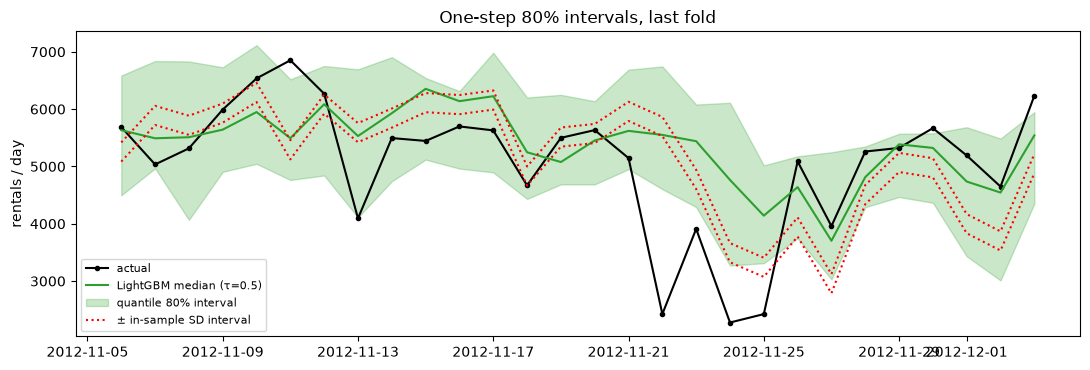

→ in-sample-residual intervals cover 10% of new days (target 80%): far too narrow.
→ quantile LightGBM covers 59% of new days but 78% of its own training days: quantile models overfit too, so calibrate intervals on held-out data (conformal prediction, Exercise 6).


In [41]:
Z80 = stats.norm.ppf(0.9)                    # ≈ 1.2816, for a symmetric 80% normal interval
interval_rows, last_fold_bands = [], None
for fold, (tr_idx, te_idx) in enumerate(TimeSeriesSplit(n_splits=4, test_size=28).split(features_dev)):
    Xtr, ytr = features_dev.iloc[tr_idx][all_feature_names], target_dev.iloc[tr_idx]
    Xte, yte = features_dev.iloc[te_idx][all_feature_names], target_dev.iloc[te_idx].to_numpy()
    quantile_models = {tau: lgb.LGBMRegressor(**(LGB_PARAMS | {"objective": "quantile", "alpha": tau})).fit(Xtr, ytr) for tau in (0.1, 0.5, 0.9)}
    quantile_preds = {tau: model.predict(Xte) for tau, model in quantile_models.items()}
    ytr_np = ytr.to_numpy()
    crossings = int(np.sum(quantile_preds[0.1] > quantile_preds[0.9]))
    lo_q, hi_q = np.minimum(quantile_preds[0.1], quantile_preds[0.9]), np.maximum(quantile_preds[0.1], quantile_preds[0.9])
    point_model = lgb.LGBMRegressor(**LGB_PARAMS).fit(Xtr, ytr)
    in_sample_sd = np.std(ytr - point_model.predict(Xtr))
    point_te = point_model.predict(Xte)
    snaive_te = Xte["lag_7"].to_numpy()
    snaive_resid = (ytr - Xtr["lag_7"]).to_numpy()                   # seasonal-naive errors on the training days
    methods = {   # name: (lower, upper, coverage of the same recipe on the TRAINING rows)
        "LightGBM quantiles τ=0.1/0.9": (lo_q, hi_q, np.mean((ytr_np >= quantile_models[0.1].predict(Xtr)) & (ytr_np <= quantile_models[0.9].predict(Xtr)))),
        "LightGBM ± 1.28·SD of in-sample residuals": (point_te - Z80 * in_sample_sd, point_te + Z80 * in_sample_sd,
                                                      np.mean(np.abs(ytr_np - point_model.predict(Xtr)) <= Z80 * in_sample_sd)),
        "seasonal naive + empirical 10%/90% error quantiles": (snaive_te + np.quantile(snaive_resid, 0.1), snaive_te + np.quantile(snaive_resid, 0.9),
                                                               np.mean((snaive_resid >= np.quantile(snaive_resid, 0.1)) & (snaive_resid <= np.quantile(snaive_resid, 0.9)))),
    }
    for name, (lo, hi, train_cover) in methods.items():
        interval_rows.append({"method": name, "fold": fold, "coverage": np.mean((yte >= lo) & (yte <= hi)), "coverage on training rows": train_cover, "mean width": np.mean(hi - lo),
                              "pinball τ=0.1": mean_pinball_loss(yte, lo, alpha=0.1), "pinball τ=0.9": mean_pinball_loss(yte, hi, alpha=0.9),
                              "quantile crossings": crossings if name.startswith("LightGBM quantiles") else 0})
    last_fold_bands = {"dates": features_dev.index[te_idx], "actual": yte, "median": quantile_preds[0.5], "lo": lo_q, "hi": hi_q,
                       "naive_lo": point_te - Z80 * in_sample_sd, "naive_hi": point_te + Z80 * in_sample_sd}
interval_table = pd.DataFrame(interval_rows).groupby("method").agg(
    {"coverage": "mean", "coverage on training rows": "mean", "mean width": "mean", "pinball τ=0.1": "mean", "pinball τ=0.9": "mean", "quantile crossings": "sum"})
print("nominal coverage 80% | 4 folds × 28 days\n", interval_table.round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(last_fold_bands["dates"], last_fold_bands["actual"], "k.-", label="actual")
ax.plot(last_fold_bands["dates"], last_fold_bands["median"], color="tab:green", label="LightGBM median (τ=0.5)")
ax.fill_between(last_fold_bands["dates"], last_fold_bands["lo"], last_fold_bands["hi"], color="tab:green", alpha=0.25, label="quantile 80% interval")
ax.plot(last_fold_bands["dates"], last_fold_bands["naive_lo"], "r:", label="± in-sample SD interval")
ax.plot(last_fold_bands["dates"], last_fold_bands["naive_hi"], "r:")
ax.set(title="One-step 80% intervals, last fold", ylabel="rentals / day")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
insample = interval_table.loc["LightGBM ± 1.28·SD of in-sample residuals", "coverage"]
quant = interval_table.loc["LightGBM quantiles τ=0.1/0.9", "coverage"]
quant_train = interval_table.loc["LightGBM quantiles τ=0.1/0.9", "coverage on training rows"]
print(f"→ in-sample-residual intervals cover {insample:.0%} of new days (target 80%): {'far too narrow' if insample < 0.7 else 'close to nominal here'}.")
print(f"→ quantile LightGBM covers {quant:.0%} of new days but {quant_train:.0%} of its own training days: "
      + ("quantile models overfit too, so calibrate intervals on held-out data (conformal prediction, Exercise 6)." if quant_train - quant > 0.1
         else "similar in and out of sample."))

Quantile models trained separately can **cross** (the 10% quantile above the 90% one); sorting the pair, as we do, is the standard quick fix. Coverage measured on 112 days is still noisy (±4 percentage points is one standard error). In production, track coverage over time: when it drifts, intervals need recalibration.

### ✍️ Your Turn

Compute the **pinball loss** for $\tau = 0.9$ by hand for `y = [10, 20, 30]` and quantile forecasts `q = [12, 15, 30]`. Store the mean loss in `pinball_manual`.

In [42]:
y_pin, q_pin = np.array([10.0, 20.0, 30.0]), np.array([12.0, 15.0, 30.0])
pinball_manual = None  # TODO: your code here
check("pinball_manual", pinball_manual, mean_pinball_loss(y_pin, q_pin, alpha=0.9),
      hint="diff = y - q; np.mean(np.maximum(0.9 * diff, (0.9 - 1) * diff))")

⏳ pinball_manual: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_pin, q_pin = np.array([10.0, 20.0, 30.0]), np.array([12.0, 15.0, 30.0])
diff = y_pin - q_pin
pinball_manual = np.mean(np.maximum(0.9 * diff, (0.9 - 1) * diff))
check("pinball_manual", pinball_manual, mean_pinball_loss(y_pin, q_pin, alpha=0.9))
```

Row 1 over-predicts by 2 → cost $0.1 \times 2 = 0.2$. Row 2 under-predicts by 5 → cost $0.9 \times 5 = 4.5$. Row 3 is exact → 0. Mean $= 4.7 / 3 \approx 1.567$.
</details>

> 💡 **Interview angle:** "How do you produce prediction intervals with gradient boosting?" — train quantile models (pinball loss, e.g. τ = 0.1 and 0.9), or calibrate intervals with conformal prediction on held-out residuals, or bootstrap. Evaluate **coverage and width** on a backtest, not on training data, fix quantile crossing, and monitor coverage in production.

## 14. Many Series: Hierarchies, Global Models, Foundation Models 🟢

Real companies rarely forecast one series. They forecast **thousands**: every product × store, every server × metric. This changes the design.

**Local vs global models.**
- A **local** model (ETS, ARIMA) is fitted per series. Simple and robust, but it can't learn from similar series and struggles with short histories (new products: the **cold-start** problem).
- A **global** model (one LightGBM or neural network for all series) pools information: "demand rises before holidays" is learned once from all products. It needs **per-series scaling** (divide by each series' recent mean), series identifiers or static features (category, store size), and lag features computed **within each series** (`groupby(series_id).shift(k)`). The M5 Walmart competition was dominated by global LightGBM models of this kind.

**Hierarchical forecasting.** Sales roll up: item → department → store → region → total. Independent forecasts at each level **don't add up** (they aren't *coherent*). Fixes:

| Approach | Idea | Trade-off |
|---|---|---|
| **Bottom-up** | forecast the lowest level, sum upward | coherent; noisy bottom series make poor totals |
| **Top-down** | forecast the total, split by historical proportions | stable totals; loses local patterns |
| **Middle-out** | forecast a middle level, go both ways | a compromise |
| **Optimal reconciliation (MinT)** | forecast every level, then adjust all forecasts to be coherent using the error covariance | usually most accurate; more computation |

**Forecasting libraries worth knowing** (not used here; the ideas carry over): **statsforecast** (very fast AutoETS/AutoARIMA for many series), **MLForecast** and **skforecast** (lag-feature pipelines for LightGBM), **sktime** and **Darts** (unified APIs, backtesting), **Prophet** (additive trend + seasonality + holidays, easy for business users, often beaten by simple baselines in benchmarks), **NeuralForecast** / **GluonTS** (N-BEATS, N-HiTS, DeepAR, TFT).

**Foundation models.** Pre-trained on huge collections of series, models such as **Chronos** (Amazon), **TimesFM** (Google), Moirai and Lag-Llama forecast new series **zero-shot**. They are strong baselines for many short series, but they still must be backtested against seasonal naive/ETS on *your* data, they add inference cost, and covariates and hierarchies need extra work.

> 💡 **Interview angle:** "Forecast demand for 50,000 product–store pairs." — a global LightGBM on scaled targets with lags/rolling stats computed per series, calendar/price/promo features, a direct or horizon-as-feature strategy, statistical baselines (seasonal naive, ETS via statsforecast) as fallbacks for short histories, reconciliation across the product and store hierarchy, a rolling-origin backtest scored with a scaled metric (MASE/WRMSSE) per level, and quantiles for inventory decisions.

## 15. A Fair Head-to-Head Comparison 🟡

The four families on **AirPassengers** with the **same 4 rolling-origin folds** (12-month test windows, expanding training data), recording accuracy, fit time and predict time. Every choice happens **inside** each fold's training data:
- **Seasonal naive** (m = 12).
- **ETS (auto)**: all 18 ETS models fitted per fold, lowest AICc wins.
- **SARIMA airline model** (0,1,1)(0,1,1)₁₂ on log passengers. (Honest note: this specification was historically identified on this very series, which gives it a small home advantage.)
- **LightGBM** on the **12-month log change** (detrended, Section 11) with features $d_{t-12}, d_{t-13}, d_{t-24}$ and the month: all known for horizons up to 12, so no recursion.

In [43]:
def fit_seasonal_naive(train):
    return lambda h: baseline_forecasts(train, h, 12)["seasonal naive (m=12)"]


def fit_ets_auto(train):
    best_fit, best_aicc = None, np.inf
    for error, trend, damped, seasonal in itertools.product(["add", "mul"], [None, "add"], [False, True], [None, "add", "mul"]):
        if trend is None and damped:
            continue
        fit = ETSModel(train, error=error, trend=trend, damped_trend=damped, seasonal=seasonal,
                       seasonal_periods=12 if seasonal else None).fit(disp=False)
        if fit.aicc < best_aicc:
            best_fit, best_aicc = fit, fit.aicc
    return lambda h: best_fit.forecast(h).to_numpy()


def fit_sarima_airline(train):
    fit = SARIMAX(np.log(train), order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
    return lambda h: np.exp(fit.get_forecast(h).predicted_mean.to_numpy())


def fit_lgbm_seasonal_change(train):
    future_index = pd.date_range(train.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq="MS")
    log_y = np.log(train).reindex(train.index.append(future_index))          # future rows are NaN
    change = log_y - log_y.shift(12)
    frame = pd.DataFrame({"target": change, "d_lag12": change.shift(12), "d_lag13": change.shift(13),
                          "d_lag24": change.shift(24), "month": log_y.index.month, "log_lag12": log_y.shift(12)})
    train_rows = frame.loc[train.index].dropna()
    cols = ["d_lag12", "d_lag13", "d_lag24", "month"]
    model = lgb.LGBMRegressor(**(LGB_PARAMS | {"num_leaves": 7, "min_child_samples": 5, "n_estimators": 200})).fit(train_rows[cols], train_rows["target"])

    def predict(h):
        rows = frame.loc[future_index[:h]]
        return np.exp(rows["log_lag12"].to_numpy() + model.predict(rows[cols]))
    return predict


h2h_models = {"seasonal naive": fit_seasonal_naive, "ETS (auto by AICc)": fit_ets_auto,
              "SARIMA airline (log)": fit_sarima_airline, "LightGBM on 12-month log change": fit_lgbm_seasonal_change}
h2h_rows = []
for fold, (tr_idx, te_idx) in enumerate(TimeSeriesSplit(n_splits=4, test_size=12).split(air)):
    train_fold, test_fold = air.iloc[tr_idx], air.iloc[te_idx]
    for name, fitter in h2h_models.items():
        t0 = time.perf_counter()
        predictor = fitter(train_fold)
        t1 = time.perf_counter()
        pred = predictor(len(test_fold))
        t2 = time.perf_counter()
        h2h_rows.append({"model": name, "fold": fold, "test year": test_fold.index[0].year, "MAE": mean_absolute_error(test_fold, pred),
                         "MASE": mase(test_fold, pred, train_fold, m=12), "fit (ms)": 1000 * (t1 - t0), "predict (ms)": 1000 * (t2 - t1)})
h2h = pd.DataFrame(h2h_rows)
summary = h2h.groupby("model").agg(MAE=("MAE", "mean"), MAE_std=("MAE", "std"), MASE=("MASE", "mean"),
                                   fit_ms=("fit (ms)", "mean"), predict_ms=("predict (ms)", "mean")).sort_values("MASE")
print(h2h.pivot(index="model", columns="test year", values="MASE").round(3).to_string())
print("\n", summary.round(2).to_string())

winner = summary.index[0]
print(f"\n→ best mean MASE: {winner} ({summary.loc[winner, 'MASE']:.3f}); seasonal naive scores {summary.loc['seasonal naive', 'MASE']:.3f}.")
print(f"→ every model beats seasonal naive on average: {bool((summary.drop(index='seasonal naive')['MASE'] < summary.loc['seasonal naive', 'MASE']).all())}")
print(f"→ LightGBM trains on only ~{len(air) - 12 * 4 - 36} rows in the first fold; statistical models are built for short single series like this, "
      f"while GBMs shine with many series and covariates (Mini Project, M5).")

test year                         1957   1958   1959   1960
model                                                      
ETS (auto by AICc)               0.629  0.549  1.279  0.661
LightGBM on 12-month log change  0.319  1.222  0.911  0.774
SARIMA airline (log)             0.218  0.903  1.028  0.436
seasonal naive                   1.375  0.412  1.657  1.571

                                    MAE  MAE_std  MASE  fit_ms  predict_ms
model                                                                    
SARIMA airline (log)             19.16    11.17  0.65   75.60        1.28
ETS (auto by AICc)               22.97     9.16  0.78  451.95        1.06
LightGBM on 12-month log change  24.06    11.52  0.81  196.18        1.03
seasonal naive                   36.98    16.64  1.25    0.06        0.03

→ best mean MASE: SARIMA airline (log) (0.646); seasonal naive scores 1.254.
→ every model beats seasonal naive on average: True
→ LightGBM trains on only ~60 rows in the first fold; statistica

Read the per-year table as well as the averages: with 4 folds, one unusual year can flip a ranking. The consistent lesson across forecasting competitions holds here too: **start with seasonal naive, ETS and SARIMA, then justify anything more complex with a backtest.**

> 💡 **Interview angle:** "ETS, ARIMA or LightGBM?" — for a few short seasonal series, ETS/SARIMA are fast, accurate and give intervals; for many related series with covariates (promotions, weather, holidays), a global GBM with lag features usually wins; always compare on identical rolling-origin folds with a scaled metric, and consider an ensemble (simple forecast combinations, such as averaging ETS and ARIMA, are notoriously hard to beat).

## 🔧 Build It From Scratch

Three builds, each **asserted** against the library:
1. **Simple exponential smoothing** and **Holt's linear method** in NumPy, matched against `statsmodels` fitted values and forecasts for the same **fixed** smoothing parameters and initial states (`initialization_method="known"`, `optimized=False`).
2. An **AR($p$) model fitted by OLS** on lagged values, matched against `statsmodels` `AutoReg` coefficients, noise variance and multi-step forecasts.
3. **MASE** in NumPy, checked on a hand-computed example and against the Section 12 helper.

The recursions:

$$\text{SES: } \hat y_{t|t-1} = \ell_{t-1},\ \ \ell_t = \alpha y_t + (1-\alpha)\ell_{t-1} \qquad \text{Holt: } \hat y_{t|t-1} = \ell_{t-1} + b_{t-1},\ \ \ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1} + b_{t-1}),\ \ b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta) b_{t-1}$$

$$\text{AR}(p)\text{: } y_t = c + \sum_{j=1}^{p} \phi_j y_{t-j} + \varepsilon_t \ \Rightarrow\ \text{OLS of } y_{p+1..n} \text{ on } [1, y_{t-1}, \dots, y_{t-p}]$$

In [44]:
def ses_numpy(y, alpha, level0):
    """Simple exponential smoothing. Returns one-step-ahead fitted values and the final level."""
    y = np.asarray(y, dtype=float)
    fitted = np.empty_like(y)
    level = level0
    for t, obs in enumerate(y):
        fitted[t] = level                                    # forecast for t, made before seeing y_t
        level = alpha * obs + (1 - alpha) * level
    return fitted, level                                     # every future forecast equals the last level


def holt_numpy(y, alpha, beta, level0, trend0):
    """Holt's linear trend method. Returns one-step-ahead fitted values, final level and final trend."""
    y = np.asarray(y, dtype=float)
    fitted = np.empty_like(y)
    level, trend = level0, trend0
    for t, obs in enumerate(y):
        fitted[t] = level + trend
        new_level = alpha * obs + (1 - alpha) * (level + trend)
        trend = beta * (new_level - level) + (1 - beta) * trend
        level = new_level
    return fitted, level, trend


for series_name, series in [("AirPassengers train", air_train), ("bike daily train", bike_train_bl)]:
    y_np = series.to_numpy(dtype=float)
    for alpha in [0.1, 0.5, 0.9]:
        fitted, level = ses_numpy(y_np, alpha, y_np[0])
        ref = SimpleExpSmoothing(y_np, initialization_method="known", initial_level=y_np[0]).fit(smoothing_level=alpha, optimized=False)
        assert np.allclose(fitted, ref.fittedvalues) and np.allclose(np.full(6, level), ref.forecast(6))
    for alpha, beta in [(0.3, 0.05), (0.8, 0.2)]:
        fitted, level, trend = holt_numpy(y_np, alpha, beta, y_np[0], y_np[1] - y_np[0])
        ref = Holt(y_np, initialization_method="known", initial_level=y_np[0], initial_trend=y_np[1] - y_np[0]).fit(
            smoothing_level=alpha, smoothing_trend=beta, optimized=False)
        assert np.allclose(fitted, ref.fittedvalues) and np.allclose(level + trend * np.arange(1, 7), ref.forecast(6))
    print(f"✅ {series_name}: SES (α = 0.1, 0.5, 0.9) and Holt (two α/β pairs) match statsmodels fitted values and forecasts")

# SES really is an exponentially weighted average: ℓ_T = Σ α(1-α)^j y_(T-j) + (1-α)^T ℓ_0
y_np, alpha = air_train.to_numpy(dtype=float), 0.3
_, level_T = ses_numpy(y_np, alpha, y_np[0])
weights = alpha * (1 - alpha) ** np.arange(len(y_np))                # weight for y_T, y_(T-1), …
explicit = np.sum(weights * y_np[::-1]) + (1 - alpha) ** len(y_np) * y_np[0]
assert np.isclose(level_T, explicit)
print(f"✅ the SES level equals the explicit weighted sum; the 12 most recent months carry {weights[:12].sum():.1%} of the weight at α = {alpha}")

✅ AirPassengers train: SES (α = 0.1, 0.5, 0.9) and Holt (two α/β pairs) match statsmodels fitted values and forecasts
✅ bike daily train: SES (α = 0.1, 0.5, 0.9) and Holt (two α/β pairs) match statsmodels fitted values and forecasts
✅ the SES level equals the explicit weighted sum; the 12 most recent months carry 98.6% of the weight at α = 0.3


In [45]:
def fit_ar_ols(y, p):
    """AR(p) with intercept by ordinary least squares on lagged values."""
    y = np.asarray(y, dtype=float)
    n = len(y)
    X = np.column_stack([np.ones(n - p)] + [y[p - j:n - j] for j in range(1, p + 1)])     # [1, y_(t-1), …, y_(t-p)]
    coef = np.linalg.lstsq(X, y[p:], rcond=None)[0]
    resid = y[p:] - X @ coef
    return coef, resid @ resid / len(resid)


def forecast_ar(y, coef, h):
    """Iterate the AR equation h steps, feeding forecasts back in."""
    history = list(np.asarray(y, dtype=float))
    p = len(coef) - 1
    out = []
    for _ in range(h):
        value = coef[0] + sum(coef[j] * history[-j] for j in range(1, p + 1))
        out.append(value)
        history.append(value)
    return np.array(out)


sun_np = sunspots.to_numpy(dtype=float)
for p in [2, 9]:
    coef, sigma2 = fit_ar_ols(sun_np, p)
    ar_ref = AutoReg(sun_np, lags=p, trend="c").fit()
    assert np.allclose(coef, ar_ref.params) and np.isclose(sigma2, ar_ref.sigma2)
    assert np.allclose(forecast_ar(sun_np, coef, 10), ar_ref.predict(start=len(sun_np), end=len(sun_np) + 9))
    print(f"✅ AR({p}) by OLS matches AutoReg: coefficients, σ² = {sigma2:.1f}, and 10-step forecasts | φ = {np.round(coef[1:4], 3)}{' …' if p > 3 else ''}")

mle_ar2 = SARIMAX(sun_np, order=(2, 0, 0), trend="c").fit(disp=False)
print(f"for comparison, ARIMA-style maximum likelihood AR(2): φ = {np.round(mle_ar2.params[1:3], 3)} vs OLS {np.round(fit_ar_ols(sun_np, 2)[0][1:], 3)} "
      "(close, not identical: MLE also models the first p observations)")

✅ AR(2) by OLS matches AutoReg: coefficients, σ² = 275.4, and 10-step forecasts | φ = [ 1.392 -0.69 ]
✅ AR(9) by OLS matches AutoReg: coefficients, σ² = 221.2, and 10-step forecasts | φ = [ 1.165 -0.405 -0.167] …
for comparison, ARIMA-style maximum likelihood AR(2): φ = [ 1.391 -0.689] vs OLS [ 1.392 -0.69 ] (close, not identical: MLE also models the first p observations)


In [46]:
def mase_numpy(y_true, y_pred, y_train, m=1):
    """Mean absolute scaled error: test MAE / in-sample MAE of the lag-m naive forecast."""
    y_train = np.asarray(y_train, dtype=float)
    scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    return np.mean(np.abs(np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float))) / scale


# Hand example. Training series 3, 5, 4, 6, 5, 7; test actuals 8, 6; forecasts 7, 7 → test MAE = (1 + 1) / 2 = 1
#   m = 1: in-sample naive errors |5-3|, |4-5|, |6-4|, |5-6|, |7-5| = 2, 1, 2, 1, 2 → scale 1.6 → MASE 0.625
#   m = 2: in-sample errors |4-3|, |6-5|, |5-4|, |7-6| = 1, 1, 1, 1 → scale 1.0 → MASE 1.0
hand_train, hand_test, hand_pred = [3, 5, 4, 6, 5, 7], [8, 6], [7, 7]
assert np.isclose(mase_numpy(hand_test, hand_pred, hand_train, m=1), 0.625)
assert np.isclose(mase_numpy(hand_test, hand_pred, hand_train, m=2), 1.0)
assert np.isclose(mase_numpy(bike_valid_bl, bike_baselines["seasonal naive (m=7)"], bike_train_bl, m=7),
                  mase(bike_valid_bl, bike_baselines["seasonal naive (m=7)"], bike_train_bl, m=7))
print("✅ MASE: hand example (0.625 with m=1, 1.0 with m=2) and the Section 12 helper agree")
window_mase = mase_numpy(bike_valid_bl, bike_baselines["seasonal naive (m=7)"], bike_train_bl, m=7)
print(f"seasonal naive on the bike validation window: MASE {window_mase:.3f} → "
      + ("this window was harder for it than a typical in-sample week" if window_mase > 1 else "this window was easier for it than a typical in-sample week"))

✅ MASE: hand example (0.625 with m=1, 1.0 with m=2) and the Section 12 helper agree
seasonal naive on the bike validation window: MASE 1.467 → this window was harder for it than a typical in-sample week


What the builds show: the `statsmodels` smoothers are exactly these few lines of recursion once the initial states are fixed (the optimizer only chooses α, β and the initial states). `AutoReg` is plain OLS on a lag matrix, while `ARIMA`/`SARIMAX` use exact maximum likelihood and give slightly different estimates. MASE is a one-liner whose denominator is the **training** data's seasonal naive error, which is why the same test MAE can give different MASE values for different $m$.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — `shift()` on a series with missing timestamps

`shift(24)` means **24 rows**, not 24 hours. On the gappy hourly bike data, "same hour yesterday" silently becomes "25 or 26 hours ago" after every gap.

In [47]:
ts = hourly.index.to_series()
row_gap = ts - ts.shift(24)
misaligned = row_gap.notna() & (row_gap != pd.Timedelta(hours=24))
wrong_lag = hourly.shift(24)                                        # ❌ 24 rows back
right_lag = hourly_full.shift(24).reindex(hourly.index)             # ✅ 24 hours back on the complete grid
both = wrong_lag.notna() & right_lag.notna()
print(f"❌ rows where 'shift(24)' is NOT exactly 24 hours back: {misaligned.sum():,} of {len(hourly):,} ({misaligned.mean():.1%})")
print(f"   gaps it actually spans on those rows: {row_gap[misaligned].value_counts().head(3).to_dict()}")
for label, lag in [("❌ row-based lag", wrong_lag), ("✅ time-based lag", right_lag)]:
    rows = both & misaligned
    print(f"{label}: MAE of 'same hour yesterday' on the affected rows {mean_absolute_error(hourly[rows], lag[rows]):.1f}")
print("✅ fix: asfreq('h') (or reindex to a full date_range) before any shift/rolling; or use rolling('24h') windows on a DatetimeIndex.")

❌ rows where 'shift(24)' is NOT exactly 24 hours back: 1,698 of 17,379 (9.8%)
   gaps it actually spans on those rows: {Timedelta('1 days 01:00:00'): 1392, Timedelta('1 days 02:00:00'): 173, Timedelta('1 days 13:00:00'): 33}
❌ row-based lag: MAE of 'same hour yesterday' on the affected rows 55.6
✅ time-based lag: MAE of 'same hour yesterday' on the affected rows 44.6
✅ fix: asfreq('h') (or reindex to a full date_range) before any shift/rolling; or use rolling('24h') windows on a DatetimeIndex.


### ❌ Pitfall 2 — Evaluating a recursive model with the true lags ("teacher forcing")

After training a one-step model, it's tempting to score it on the test window using the feature table, where every lag is the **real** past value. In production the model must use its **own predictions** for lags inside the horizon (Section 10). We reuse the last fold of Section 10.

In [48]:
full_frame = pd.concat([last_fold["train"], last_fold["test"]])
forced_features = make_lag_features(full_frame).loc[last_fold["test"].index, all_feature_names]
forced_pred = last_fold["model"].predict(forced_features)                                              # ❌ true lags
honest_pred = recursive_forecast(last_fold["model"], last_fold["train"]["count"], last_fold["test"], all_feature_names)   # ✅ own predictions
actual_last = last_fold["test"]["count"].to_numpy(dtype=float)
for label, pred in [("❌ one-step with true lags (teacher forcing)", forced_pred), ("✅ genuine 28-day recursive forecast", honest_pred)]:
    weekly = [mean_absolute_error(actual_last[w * 7:(w + 1) * 7], pred[w * 7:(w + 1) * 7]) for w in range(4)]
    print(f"{label:44s} MAE {mean_absolute_error(actual_last, pred):5.0f} | by week {np.round(weekly, 0)}")
print("→ teacher forcing measures a 1-day-ahead forecast, not the 28-day forecast you will deploy.")

❌ one-step with true lags (teacher forcing)  MAE   774 | by week [ 551.  580. 1200.  765.]
✅ genuine 28-day recursive forecast          MAE   817 | by week [ 540.  583. 1910.  236.]
→ teacher forcing measures a 1-day-ahead forecast, not the 28-day forecast you will deploy.


### ❌ Pitfall 3 — Over-differencing

One difference too many doesn't remove more trend; it **adds** noise: the differenced series gets a strong negative lag-1 autocorrelation (about −0.5 for differenced white noise), the MA coefficient heads toward −1, and forecast intervals widen.

In [49]:
single = log_air_train.diff(12).diff().dropna()
double = single.diff().dropna()
print(f"lag-1 ACF: ΔΔ₁₂ log y = {acf(single, nlags=1)[1]:+.3f} | Δ²Δ₁₂ log y = {acf(double, nlags=1)[1]:+.3f} "
      f"| variance {single.var():.5f} → {double.var():.5f}")
for label, order in [("✅ d=1, D=1 (airline)", (0, 1, 1)), ("❌ d=2, D=1 (one difference too many)", (0, 2, 1))]:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        fit = SARIMAX(log_air_train, order=order, seasonal_order=(0, 1, 1, 12)).fit(disp=False)
    fc95 = fit.get_forecast(AIR_TEST_MONTHS).summary_frame(alpha=0.05)
    width = np.mean(np.exp(fc95["mean_ci_upper"]) - np.exp(fc95["mean_ci_lower"]))
    notes = sorted({str(w.message)[:50] for w in caught})
    print(f"{label:38s} MA(1) θ = {fit.params['ma.L1']:+.3f} | test MAE {mean_absolute_error(air_test, np.exp(fc95['mean'])):5.1f} | "
          f"mean 95% interval width {width:6.1f}" + (f" | warnings: {notes}" if notes else ""))

lag-1 ACF: ΔΔ₁₂ log y = -0.328 | Δ²Δ₁₂ log y = -0.660 | variance 0.00213 → 0.00570
✅ d=1, D=1 (airline)                   MA(1) θ = -0.342 | test MAE  39.5 | mean 95% interval width  162.4


❌ d=2, D=1 (one difference too many)   MA(1) θ = -0.993 | test MAE  53.6 | mean 95% interval width  262.0


### ❌ Pitfall 4 — Reporting in-sample fit as forecast accuracy

`fittedvalues` are **one-step-ahead predictions on the training data**, made with parameters estimated from that same data. They say little about a 24-month forecast. The same goes for a LightGBM model's training error.

In [50]:
hw_mul = ExponentialSmoothing(air_train, trend="add", seasonal="mul", seasonal_periods=12, initialization_method="estimated").fit()
gbm_train_mae = mean_absolute_error(target_dev[train_rows], gbm_one_step.predict(features_dev.loc[train_rows, chosen_cols]))
gbm_check_mae = mean_absolute_error(target_dev[check_rows], gbm_one_step.predict(features_dev.loc[check_rows, chosen_cols]))
print(f"❌ Holt-Winters in-sample (fittedvalues) MAE: {mean_absolute_error(air_train, hw_mul.fittedvalues):5.1f} | "
      f"✅ out-of-sample 24-month MAE: {mean_absolute_error(air_test, hw_mul.forecast(AIR_TEST_MONTHS)):5.1f}")
print(f"❌ LightGBM training-rows MAE: {gbm_train_mae:5.0f} | ✅ MAE on the later check window: {gbm_check_mae:5.0f} "
      f"({gbm_check_mae / gbm_train_mae:.1f}× larger)")

❌ Holt-Winters in-sample (fittedvalues) MAE:   7.2 | ✅ out-of-sample 24-month MAE:  29.0
❌ LightGBM training-rows MAE:   214 | ✅ MAE on the later check window:   831 (3.9× larger)


### ❌ Pitfall 5 — Using future values of exogenous regressors you won't have

Section 8's SARIMAX used the **observed** weather of the forecast days. At forecast time you only have a weather *forecast*. As a crude stand-in for one, use the average weather of the last 7 observed days ("persistence"). The honest error is somewhere between this and the oracle, depending on the quality of the real weather forecast.

In [51]:
persistence = bike_va_frame.copy()
for col in ["temp", "humidity", "windspeed"]:
    persistence[col] = bike_tr_frame[col].iloc[-7:].mean()
oracle_fc = sarimax_fit.get_forecast(28, exog=bike_exog(bike_va_frame)).predicted_mean * 1000
persist_fc = sarimax_fit.get_forecast(28, exog=bike_exog(persistence)).predicted_mean * 1000
no_weather_mae = mean_absolute_error(bike_va_frame["count"], sarimax_results["SARIMA (no regressors)"]["forecast"]["mean"])
print(f"❌ SARIMAX with the observed (future) weather : MAE {mean_absolute_error(bike_va_frame['count'], oracle_fc):.0f}  ← looks best, can't be reproduced live")
print(f"✅ SARIMAX with a persistence weather guess   : MAE {mean_absolute_error(bike_va_frame['count'], persist_fc):.0f}")
print(f"   SARIMA without any regressors               : MAE {no_weather_mae:.0f}")
print("✅ fix: train and backtest with the forecasts that were available at each origin (weather-forecast 'vintages'), or restrict to truly known-in-advance regressors.")

❌ SARIMAX with the observed (future) weather : MAE 684  ← looks best, can't be reproduced live
✅ SARIMAX with a persistence weather guess   : MAE 811
   SARIMA without any regressors               : MAE 889
✅ fix: train and backtest with the forecasts that were available at each origin (weather-forecast 'vintages'), or restrict to truly known-in-advance regressors.


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Seasonal naive for any horizon
Write `seasonal_naive(y, h, m)` that returns the next `h` forecasts, each equal to the value **one season earlier** (cycling through the last `m` observations).

In [52]:
def seasonal_naive(y, h, m):
    return None  # TODO


check("seasonal_naive", seasonal_naive(np.array([1.0, 2, 3, 4, 5, 6, 7]), 5, 3), [5.0, 6, 7, 5, 6],
      hint="last_season = y[-m:]; np.resize(last_season, h) or last_season[np.arange(h) % m]")

⏳ seasonal_naive: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def seasonal_naive(y, h, m):
    y = np.asarray(y, dtype=float)
    return y[-m:][np.arange(h) % m]


check("seasonal_naive", seasonal_naive(np.array([1.0, 2, 3, 4, 5, 6, 7]), 5, 3), [5.0, 6, 7, 5, 6])
```

`np.arange(h) % m` cycles 0, 1, …, m-1, 0, 1, … through the last season. It's the same rule as $y_{T+h-m(k+1)}$ with $k = \lfloor (h-1)/m \rfloor$.
</details>

### 🟢 Exercise 2 — Undo differencing
A model forecast the **first differences** `[2, -1, 3]` of a series whose last observed value is `100`. Convert them back into level forecasts. Store them in `level_forecasts`.

In [53]:
last_value, diff_forecasts = 100.0, np.array([2.0, -1.0, 3.0])
level_forecasts = None  # TODO
check("level_forecasts", level_forecasts, [102.0, 101.0, 104.0], hint="last_value + np.cumsum(diff_forecasts)")

⏳ level_forecasts: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
last_value, diff_forecasts = 100.0, np.array([2.0, -1.0, 3.0])
level_forecasts = last_value + np.cumsum(diff_forecasts)
check("level_forecasts", level_forecasts, [102.0, 101.0, 104.0])
```

Each forecast difference is added to the **previous forecast**, not to the last actual value; that's the cumulative sum. For a seasonal difference you would add each forecast change to the value one season earlier (actual or already forecast).
</details>

### 🟢 Exercise 3 — The MASE denominator
Compute the in-sample MAE of the **weekly seasonal naive** forecast ($m = 7$) on `daily_dev["count"]`: the mean of $\lvert y_t - y_{t-7}\rvert$. Store it in `weekly_scale`.

In [54]:
weekly_scale = None  # TODO
check("weekly_scale", weekly_scale, mean_absolute_error(daily_dev["count"].iloc[7:], daily_dev["count"].shift(7).iloc[7:]),
      hint="y = daily_dev['count'].to_numpy(dtype=float); np.mean(np.abs(y[7:] - y[:-7]))")

⏳ weekly_scale: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_dev = daily_dev["count"].to_numpy(dtype=float)
weekly_scale = np.mean(np.abs(y_dev[7:] - y_dev[:-7]))
check("weekly_scale", weekly_scale, mean_absolute_error(daily_dev["count"].iloc[7:], daily_dev["count"].shift(7).iloc[7:]))
print(f"{weekly_scale:.0f} rentals/day")
```

A model with MAE below this number beats the in-sample seasonal naive: MASE < 1.
</details>

### 🟡 Exercise 4 — A rolling-origin backtest loop
Use `TimeSeriesSplit(n_splits=4, test_size=12)` on `air`. In each fold, forecast the 12 test months with the **seasonal naive** (m = 12) from the training months only, and record the MAE. Store the 4 fold MAEs, in fold order, in the list `fold_maes`.

In [55]:
fold_maes = None  # TODO

n_air = len(air)
reference_fold_maes = [mean_absolute_error(air.iloc[n_air - 12 * j:n_air - 12 * j + 12], air.iloc[n_air - 12 * j - 12:n_air - 12 * j]) for j in [4, 3, 2, 1]]
check("fold_maes", fold_maes, reference_fold_maes, hint="for tr, te in splitter.split(air): pred = air.iloc[tr].to_numpy()[-12:]; MAE vs air.iloc[te]")

⏳ fold_maes: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fold_maes = []
for tr_idx, te_idx in TimeSeriesSplit(n_splits=4, test_size=12).split(air):
    train_part, test_part = air.iloc[tr_idx], air.iloc[te_idx]
    forecast = train_part.to_numpy()[-12:]          # the same months one year earlier
    fold_maes.append(mean_absolute_error(test_part, forecast))

n_air = len(air)
reference_fold_maes = [mean_absolute_error(air.iloc[n_air - 12 * j:n_air - 12 * j + 12], air.iloc[n_air - 12 * j - 12:n_air - 12 * j]) for j in [4, 3, 2, 1]]
check("fold_maes", fold_maes, reference_fold_maes)
print(np.round(fold_maes, 1))
```

The fold MAEs vary a lot from year to year: some years repeat last year's pattern closely, others don't, and the level keeps rising. Several folds plus a scale-free metric like MASE make comparisons fair.
</details>

### 🟡 Exercise 5 — Build a direct-strategy training matrix
For the series `y = [1, 4, 9, 16, 25, 36]`, horizon `h = 2`, and 2 lags, build the training rows for a **direct** model: features `[y_t, y_(t-1)]` at each origin `t`, target `y_(t+h)`. Keep only rows where every value exists. Store the feature matrix in `X_direct` (shape `(3, 2)`) and the targets in `y_direct`.

In [56]:
y_seq = np.array([1.0, 4.0, 9.0, 16.0, 25.0, 36.0])
h_direct = 2
X_direct, y_direct = None, None  # TODO
check("X_direct", X_direct, [[4.0, 1.0], [9.0, 4.0], [16.0, 9.0]], hint="origins t = 1 … len(y) - 1 - h; row = [y[t], y[t-1]], target = y[t + h]")
check("y_direct", y_direct, [16.0, 25.0, 36.0])

⏳ X_direct: not attempted yet — replace None with your answer.
⏳ y_direct: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_seq = np.array([1.0, 4.0, 9.0, 16.0, 25.0, 36.0])
h_direct = 2
origins = range(1, len(y_seq) - h_direct)             # need y[t-1] and y[t+h]
X_direct = np.array([[y_seq[t], y_seq[t - 1]] for t in origins])
y_direct = np.array([y_seq[t + h_direct] for t in origins])
check("X_direct", X_direct, [[4.0, 1.0], [9.0, 4.0], [16.0, 9.0]])
check("y_direct", y_direct, [16.0, 25.0, 36.0])
```

With pandas: `pd.DataFrame({"lag0": s, "lag1": s.shift(1), "target": s.shift(-h)}).dropna()`. Longer horizons lose more rows at the end, which is one cost of the direct strategy.
</details>

### 🔴 Exercise 6 — Distribution-free intervals from backtest errors (interview style)

*"Your forecasting model has no built-in intervals. How would you add 80% intervals and check them?"* One good answer: **use the errors from a rolling-origin backtest**.

The cell below backtests the seasonal naive on 13 folds of 28 days and stores `bt_actual` and `bt_forecast` (shape `(13, 28)`: folds × horizons). Using **only the first 12 folds**, compute the residuals `actual − forecast` and, **for each horizon separately**, their 10th and 90th percentiles (`np.quantile`, default method). Add them to the 13th fold's forecast to get an 80% interval. Store the share of the 13th fold's actuals inside the interval (inclusive) in `coverage_13`, and the mean interval width in `width_13`.

In [57]:
bt_actual, bt_forecast = [], []
for tr_idx, te_idx in TimeSeriesSplit(n_splits=13, test_size=28).split(daily_dev):
    bt_forecast.append(baseline_forecasts(daily_dev["count"].iloc[tr_idx], 28, 7)["seasonal naive (m=7)"])
    bt_actual.append(daily_dev["count"].iloc[te_idx].to_numpy(dtype=float))
bt_actual, bt_forecast = np.array(bt_actual), np.array(bt_forecast)

coverage_13, width_13 = None, None  # TODO

_cal = pd.DataFrame(bt_actual[:12] - bt_forecast[:12])
_lo, _hi = bt_forecast[12] + _cal.quantile(0.1).to_numpy(), bt_forecast[12] + _cal.quantile(0.9).to_numpy()
check("coverage_13", coverage_13, np.mean((bt_actual[12] >= _lo) & (bt_actual[12] <= _hi)), hint="residuals = bt_actual[:12] - bt_forecast[:12]; np.quantile(residuals, 0.1, axis=0)")
check("width_13", width_13, np.mean(_hi - _lo), hint="mean of (upper - lower) over the 28 horizons")

⏳ coverage_13: not attempted yet — replace None with your answer.
⏳ width_13: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
bt_actual, bt_forecast = [], []
for tr_idx, te_idx in TimeSeriesSplit(n_splits=13, test_size=28).split(daily_dev):
    bt_forecast.append(baseline_forecasts(daily_dev["count"].iloc[tr_idx], 28, 7)["seasonal naive (m=7)"])
    bt_actual.append(daily_dev["count"].iloc[te_idx].to_numpy(dtype=float))
bt_actual, bt_forecast = np.array(bt_actual), np.array(bt_forecast)

residuals = bt_actual[:12] - bt_forecast[:12]                  # calibration folds only
lower = bt_forecast[12] + np.quantile(residuals, 0.1, axis=0)  # one offset per horizon
upper = bt_forecast[12] + np.quantile(residuals, 0.9, axis=0)
coverage_13 = np.mean((bt_actual[12] >= lower) & (bt_actual[12] <= upper))
width_13 = np.mean(upper - lower)

_cal = pd.DataFrame(bt_actual[:12] - bt_forecast[:12])
_lo, _hi = bt_forecast[12] + _cal.quantile(0.1).to_numpy(), bt_forecast[12] + _cal.quantile(0.9).to_numpy()
check("coverage_13", coverage_13, np.mean((bt_actual[12] >= _lo) & (bt_actual[12] <= _hi)))
check("width_13", width_13, np.mean(_hi - _lo))
print(f"coverage on the held-out fold: {coverage_13:.0%} (nominal 80%) | mean width {width_13:,.0f} rentals")
```

**What to say in the interview:** per-horizon empirical quantiles capture that uncertainty grows with $h$, need no distributional assumption, and work for any model. Caveats: 12 folds give noisy tail quantiles (pool neighbouring horizons, or use more origins), errors aren't exchangeable over time (seasons, trend), so recalibrate regularly or use adaptive conformal methods, and **always check coverage on folds not used for calibration**, exactly as done here.
</details>

## 🚀 Mini Project: A 28-Day Bike Demand Forecast

**Goal:** Capital Bikeshare wants a **28-day forecast of daily rentals with 80% intervals** to plan bike rebalancing and maintenance staff. Compare four approaches with a rolling-origin backtest, choose one with a rule fixed in advance, and report **one** honest score on the untouched final window (4–31 December 2012).

**Rules:**
- Everything is decided on `daily_dev` (1 January 2011 – 3 December 2012) with **6 backtest folds** of 28 days.
- Weather regressors use the **observed** weather of each forecast day as a stand-in for a weather forecast (Pitfall 5): all models that use weather get the same advantage, and the final report says so.
- **Decision rule (stated before any backtest):** pick the model with the **lowest mean backtest MASE over all 28 horizons**. Models within **2%** of the best MASE count as tied, and the **simplest** tied model wins (order: seasonal naive < ETS < SARIMAX < LightGBM).

**Steps:** splits → four forecasters → backtest → one results table → apply the rule → single final evaluation and plot → conclusions.

### Step 1 — Splits and folds

In [58]:
PROJECT_H = 28
SIMPLICITY_ORDER = ["seasonal naive", "ETS(A,Ad,A)", "SARIMAX + regressors", "LightGBM direct (h as feature)"]
final_train, final_test = daily.iloc[:-PROJECT_H], daily.iloc[-PROJECT_H:]
assert final_train.index.equals(daily_dev.index) and final_train.index[-1] < final_test.index[0]
project_folds = list(TimeSeriesSplit(n_splits=6, test_size=PROJECT_H).split(daily_dev))
for fold, (tr_idx, te_idx) in enumerate(project_folds):
    print(f"fold {fold}: train {len(tr_idx)} days (→ {daily_dev.index[tr_idx[-1]]:%Y-%m-%d}) | "
          f"forecast {daily_dev.index[te_idx[0]]:%Y-%m-%d} → {daily_dev.index[te_idx[-1]]:%Y-%m-%d}")
print(f"final: train {len(final_train)} days → forecast {final_test.index[0]:%Y-%m-%d} → {final_test.index[-1]:%Y-%m-%d} "
      f"(holidays inside: {final_test.index[final_test['holiday']].strftime('%d %b').tolist()})")

fold 0: train 535 days (→ 2012-06-18) | forecast 2012-06-19 → 2012-07-16
fold 1: train 563 days (→ 2012-07-16) | forecast 2012-07-17 → 2012-08-13
fold 2: train 591 days (→ 2012-08-13) | forecast 2012-08-14 → 2012-09-10
fold 3: train 619 days (→ 2012-09-10) | forecast 2012-09-11 → 2012-10-08
fold 4: train 647 days (→ 2012-10-08) | forecast 2012-10-09 → 2012-11-05
fold 5: train 675 days (→ 2012-11-05) | forecast 2012-11-06 → 2012-12-03
final: train 703 days → forecast 2012-12-04 → 2012-12-31 (holidays inside: ['25 Dec'])


### Step 2 — Four forecasters with one interface

Each function takes the training days and the future days' known features and returns `mean`, `lo` and `hi` (80% interval) for every future day.
- **Seasonal naive** ($m = 7$) with the textbook interval: $\hat\sigma_h = \hat\sigma\sqrt{k+1}$, $k = \lfloor (h-1)/7 \rfloor$, $\hat\sigma$ from the in-sample seasonal naive errors.
- **ETS(A,Ad,A)**: additive errors, damped trend, weekly additive seasonality (a robust default; analytic intervals).
- **SARIMAX** (1,1,1)(1,0,1)₇ with holiday, working-day and weather regressors (Section 8).
- **LightGBM, direct with horizon as a feature**: one row per (origin $t$, horizon $h$). Features: the last 14 days and the 7-day mean **divided by the 28-day level at the origin** (detrending, Section 11), the 4-week growth of that level, $h$, and the target day's calendar, holiday and weather. Target: $y_{t+h} / \text{level}_t$. Three models: squared loss for the mean, and quantiles 0.1 / 0.9. Hyperparameters are fixed in advance, not tuned.

In [59]:
def forecast_seasonal_naive(train, future):
    y = train["count"].to_numpy(dtype=float)
    h = np.arange(1, len(future) + 1)
    mean = y[len(y) - 7 + (h - 1) % 7]
    sigma = np.sqrt(np.mean((y[7:] - y[:-7]) ** 2))
    sd_h = sigma * np.sqrt((h - 1) // 7 + 1)
    return pd.DataFrame({"mean": mean, "lo": mean - Z80 * sd_h, "hi": mean + Z80 * sd_h}, index=future.index)


def forecast_ets(train, future):
    fit = ETSModel(train["count"].astype(float), error="add", trend="add", damped_trend=True, seasonal="add", seasonal_periods=7).fit(disp=False)
    n = len(train)
    pred = fit.get_prediction(start=n, end=n + len(future) - 1).summary_frame(alpha=0.20)
    return pd.DataFrame({"mean": pred["mean"].to_numpy(), "lo": pred["pi_lower"].to_numpy(), "hi": pred["pi_upper"].to_numpy()}, index=future.index)


def forecast_sarimax(train, future):
    fit = SARIMAX(train["count"] / 1000, exog=bike_exog(train), order=SARIMAX_ORDER, seasonal_order=SARIMAX_SEASONAL).fit(disp=False, maxiter=200)
    fc = fit.get_forecast(len(future), exog=bike_exog(future)).summary_frame(alpha=0.20) * 1000
    return pd.DataFrame({"mean": fc["mean"].to_numpy(), "lo": fc["mean_ci_lower"].to_numpy(), "hi": fc["mean_ci_upper"].to_numpy()}, index=future.index)


PROJECT_LGB = LGB_PARAMS | {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31, "min_child_samples": 20}


def origin_features(y):
    """Features at each forecast origin, scaled by the 28-day level so trees never need to extrapolate."""
    level = y.rolling(28).mean()
    feats = pd.DataFrame({f"rel_lag{k}": y.shift(k) / level for k in range(14)}, index=y.index)
    feats["rel_roll7"] = y.rolling(7).mean() / level
    feats["level_growth_4w"] = level / level.shift(28)
    return feats, level


def lgbm_training_table(train):
    y = train["count"].astype(float)
    feats, level = origin_features(y)
    feat_np, level_np, y_np = feats.to_numpy(), level.to_numpy(), y.to_numpy()
    known_np = known_future_features(train).to_numpy(dtype=float)
    complete = ~np.isnan(feat_np).any(axis=1)
    blocks, targets = [], []
    for h in range(1, PROJECT_H + 1):
        t = np.flatnonzero(complete[:len(y) - h])                    # origins whose target day t + h is inside the training data
        blocks.append(np.column_stack([feat_np[t], np.full(len(t), h), known_np[t + h]]))
        targets.append(y_np[t + h] / level_np[t])
    columns = list(feats.columns) + ["h"] + [f"target_{c}" for c in known_cols]
    return pd.DataFrame(np.vstack(blocks), columns=columns), np.concatenate(targets), feats, level


def forecast_lgbm(train, future):
    X, ratio, feats, level = lgbm_training_table(train)
    horizons = np.arange(1, len(future) + 1)
    X_future = pd.DataFrame(np.column_stack([np.tile(feats.iloc[-1].to_numpy(), (len(future), 1)), horizons,
                                             known_future_features(future).to_numpy(dtype=float)]), columns=X.columns)
    level_now = level.iloc[-1]
    preds = {}
    for name, extra in [("mean", {}), ("lo", {"objective": "quantile", "alpha": 0.1}), ("hi", {"objective": "quantile", "alpha": 0.9})]:
        preds[name] = lgb.LGBMRegressor(**(PROJECT_LGB | extra)).fit(X, ratio).predict(X_future) * level_now
    return pd.DataFrame({"mean": preds["mean"], "lo": np.minimum(preds["lo"], preds["hi"]), "hi": np.maximum(preds["lo"], preds["hi"])}, index=future.index)


project_forecasters = dict(zip(SIMPLICITY_ORDER, [forecast_seasonal_naive, forecast_ets, forecast_sarimax, forecast_lgbm]))
X_preview, ratio_preview, _, _ = lgbm_training_table(daily_dev.iloc[project_folds[0][0]])
print(f"LightGBM training table for fold 0: {X_preview.shape[0]:,} (origin, horizon) rows × {X_preview.shape[1]} features | "
      f"target ratio range {ratio_preview.min():.2f} – {ratio_preview.max():.2f}")

LightGBM training table for fold 0: 13,034 (origin, horizon) rows × 26 features | target ratio range 0.14 – 2.53


### Step 3 — Rolling-origin backtest (6 folds × 28 days × 4 models)

Warnings raised by the optimizers are **counted** per model and shown with the results, so nothing is hidden.

In [60]:
backtest_parts, run_seconds, warning_counts = [], dict.fromkeys(SIMPLICITY_ORDER, 0.0), dict.fromkeys(SIMPLICITY_ORDER, 0)
for fold, (tr_idx, te_idx) in enumerate(project_folds):
    train_f, test_f = daily_dev.iloc[tr_idx], daily_dev.iloc[te_idx]
    y_tr_np = train_f["count"].to_numpy(dtype=float)
    mase_scale = np.mean(np.abs(y_tr_np[7:] - y_tr_np[:-7]))
    for name, forecaster in project_forecasters.items():
        start_time = time.perf_counter()
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            fc = forecaster(train_f, test_f)
        run_seconds[name] += time.perf_counter() - start_time
        warning_counts[name] += len(caught)
        backtest_parts.append(pd.DataFrame({"model": name, "fold": fold, "h": np.arange(1, PROJECT_H + 1), "date": test_f.index,
                                            "actual": test_f["count"].to_numpy(dtype=float), "mean": fc["mean"].to_numpy(),
                                            "lo": fc["lo"].to_numpy(), "hi": fc["hi"].to_numpy(), "scale": mase_scale}))
    print(f"fold {fold} done")
backtest = pd.concat(backtest_parts, ignore_index=True)
print("seconds per model (6 folds):", {k: round(v, 1) for k, v in run_seconds.items()})
print("optimizer warnings per model:", warning_counts)

fold 0 done


fold 1 done


fold 2 done


fold 3 done


fold 4 done


fold 5 done
seconds per model (6 folds): {'seasonal naive': 0.0, 'ETS(A,Ad,A)': 0.1, 'SARIMAX + regressors': 4.2, 'LightGBM direct (h as feature)': 27.9}
optimizer warnings per model: {'seasonal naive': 0, 'ETS(A,Ad,A)': 0, 'SARIMAX + regressors': 0, 'LightGBM direct (h as feature)': 0}


### Step 4 — One results table: accuracy by horizon bucket and interval coverage

                                             MAE  RMSE  MASE coverage_80 mean_width
model                          bucket                                              
seasonal naive                 h 1–7       1,160 1,478 1.337         69%      3,132
                               h 8–14      1,018 1,410 1.179         83%      4,429
                               h 15–21     1,222 1,762 1.404         86%      5,424
                               h 22–28     1,151 1,545 1.333         95%      6,263
                               all 28 days 1,138 1,554 1.313         83%      4,812
ETS(A,Ad,A)                    h 1–7         721   905 0.831         83%      2,383
                               h 8–14        724   928 0.839         83%      2,636
                               h 15–21       985 1,498 1.132         79%      2,867
                               h 22–28       881 1,293 1.020         88%      3,081
                               all 28 days   828 1,183 0.956         83%    

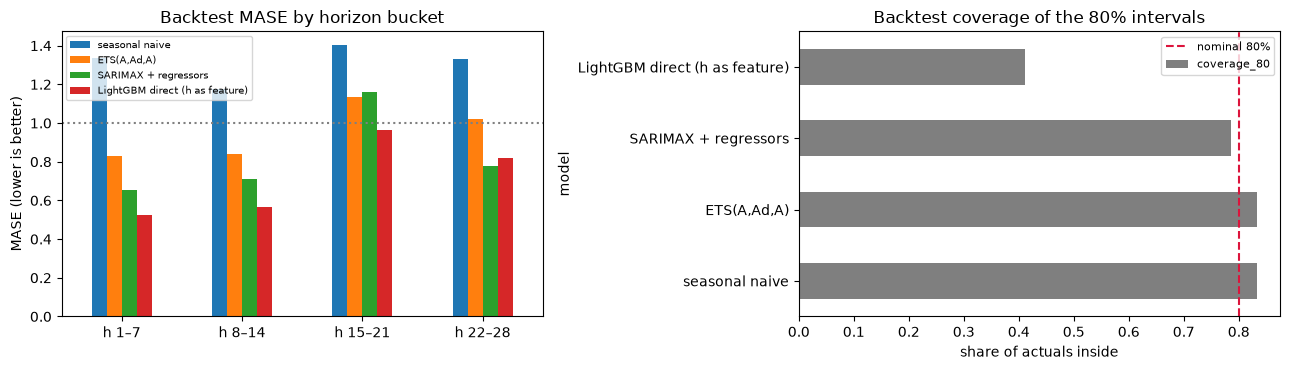

In [61]:
def summarize_forecasts(frame, group_cols):
    scored = frame.assign(abs_err=(frame["actual"] - frame["mean"]).abs(), sq_err=(frame["actual"] - frame["mean"]) ** 2,
                          inside=(frame["actual"] >= frame["lo"]) & (frame["actual"] <= frame["hi"]), width=frame["hi"] - frame["lo"])
    scored["scaled_err"] = scored["abs_err"] / scored["scale"]
    table = scored.groupby(group_cols, observed=True).agg(MAE=("abs_err", "mean"), MSE=("sq_err", "mean"), MASE=("scaled_err", "mean"),
                                                         coverage_80=("inside", "mean"), mean_width=("width", "mean"))
    table.insert(1, "RMSE", np.sqrt(table.pop("MSE")))
    return table


BUCKETS = ["h 1–7", "h 8–14", "h 15–21", "h 22–28"]
backtest["bucket"] = pd.cut(backtest["h"], bins=[0, 7, 14, 21, 28], labels=BUCKETS).astype(str)
by_bucket = summarize_forecasts(backtest, ["model", "bucket"])
overall_bt = summarize_forecasts(backtest.assign(bucket="all 28 days"), ["model", "bucket"])
results_table = pd.concat([by_bucket, overall_bt]).reindex(
    pd.MultiIndex.from_product([SIMPLICITY_ORDER, BUCKETS + ["all 28 days"]], names=["model", "bucket"]))
print(results_table.to_string(formatters={"MAE": "{:,.0f}".format, "RMSE": "{:,.0f}".format, "MASE": "{:.3f}".format,
                                          "coverage_80": "{:.0%}".format, "mean_width": "{:,.0f}".format}))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
by_bucket["MASE"].unstack("model").reindex(BUCKETS)[SIMPLICITY_ORDER].plot.bar(ax=axes[0], rot=0)
axes[0].axhline(1, ls=":", color="gray")
axes[0].set(title="Backtest MASE by horizon bucket", ylabel="MASE (lower is better)", xlabel="")
axes[0].legend(fontsize=7)
overall_bt.droplevel("bucket").loc[SIMPLICITY_ORDER, "coverage_80"].plot.barh(ax=axes[1], color="tab:gray")
axes[1].axvline(0.8, ls="--", color="crimson", label="nominal 80%")
axes[1].set(title="Backtest coverage of the 80% intervals", xlabel="share of actuals inside")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Step 5 — Apply the decision rule (no peeking at December)

In [62]:
overall_mase = overall_bt.droplevel("bucket")["MASE"]
best_mase = overall_mase.min()
tied = [name for name in SIMPLICITY_ORDER if overall_mase[name] <= best_mase * 1.02]
chosen_model = tied[0]
print(overall_mase.loc[SIMPLICITY_ORDER].round(3).to_string())
print(f"\nlowest backtest MASE: {overall_mase.idxmin()} ({best_mase:.3f}) | within 2%: {tied} → chosen by the rule: {chosen_model}")

model
seasonal naive                    1.313
ETS(A,Ad,A)                       0.956
SARIMAX + regressors              0.826
LightGBM direct (h as feature)    0.718

lowest backtest MASE: LightGBM direct (h as feature) (0.718) | within 2%: ['LightGBM direct (h as feature)'] → chosen by the rule: LightGBM direct (h as feature)


### Step 5b — Check and calibrate the chosen model's intervals (still no peeking)

Accuracy chose the model, but its 80% intervals must also be trustworthy. If backtest coverage is far from 80%, a model-agnostic fix is to **rebuild the interval from backtest errors**: for each horizon bucket, take the 10% and 90% quantiles of (actual − forecast) and add them to the point forecast. To check this honestly we calibrate on 5 folds and measure coverage on the 6th, rotating through all folds (leave-one-fold-out). The final forecast then uses errors from all 6 folds.

In [63]:
chosen_bt_rows = backtest[backtest["model"] == chosen_model].assign(resid=lambda d: d["actual"] - d["mean"])


def residual_offsets(rows):
    """10% and 90% quantiles of backtest errors (actual − forecast) per horizon bucket."""
    return rows.groupby("bucket")["resid"].quantile([0.1, 0.9]).unstack()


lofo_cover, lofo_width = [], []
for fold in range(len(project_folds)):
    offsets = residual_offsets(chosen_bt_rows[chosen_bt_rows["fold"] != fold])
    held = chosen_bt_rows[chosen_bt_rows["fold"] == fold]
    lo_cal = held["mean"] + held["bucket"].map(offsets[0.1])
    hi_cal = held["mean"] + held["bucket"].map(offsets[0.9])
    lofo_cover.append(np.mean((held["actual"] >= lo_cal) & (held["actual"] <= hi_cal)))
    lofo_width.append(np.mean(hi_cal - lo_cal))
calibration_offsets = residual_offsets(chosen_bt_rows)
raw_cover = overall_bt.droplevel("bucket").loc[chosen_model, "coverage_80"]
raw_width = overall_bt.droplevel("bucket").loc[chosen_model, "mean_width"]
print(f"{chosen_model}: backtest coverage of its own 80% intervals {raw_cover:.0%} (mean width {raw_width:,.0f})")
print(f"calibrated with errors from the other folds: coverage {np.mean(lofo_cover):.0%} (per fold {np.round(lofo_cover, 2)}), mean width {np.mean(lofo_width):,.0f}")
print("offsets added to the point forecast (rentals/day):\n", calibration_offsets.reindex(BUCKETS).round(0).to_string())

LightGBM direct (h as feature): backtest coverage of its own 80% intervals 41% (mean width 944)
calibrated with errors from the other folds: coverage 73% (per fold [0.82 0.39 0.86 0.86 0.64 0.79]), mean width 1,885
offsets added to the point forecast (rentals/day):
             0.1     0.9
bucket                 
h 1–7    -469.0   792.0
h 8–14   -633.0   905.0
h 15–21 -1588.0  1110.0
h 22–28 -1116.0  1004.0


### Step 6 — Refit on all development days and forecast the final window once

The choice is frozen. We refit the chosen model on all 703 development days and score the 28 final days. For learning purposes we also print the other three models' final scores **after** the choice, clearly marked; they did not influence it.

                                                role   MAE  RMSE  MASE coverage_80 mean_width
model                                                                                        
seasonal naive                  (for reference only) 1,837 2,371 2.002         79%      5,177
ETS(A,Ad,A)                     (for reference only) 1,603 2,200 1.748         54%      3,027
SARIMAX + regressors            (for reference only) 1,163 1,486 1.267         61%      2,212
LightGBM direct (h as feature)              ✅ CHOSEN   669   892 0.729         21%      1,283

LightGBM direct (h as feature) on the final window: 80% coverage with its own intervals 21% | with backtest-calibrated intervals 75% (mean width 1,904)


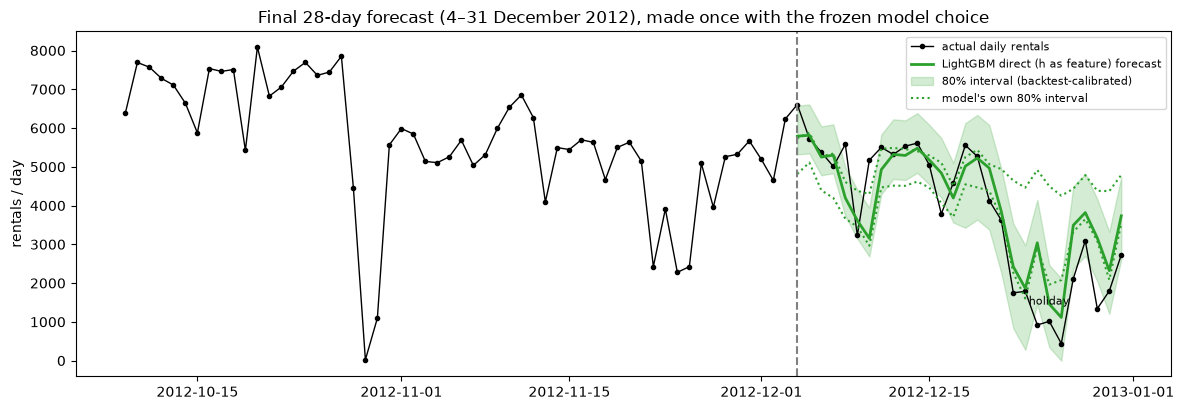

In [64]:
final_scale = np.mean(np.abs(final_train["count"].to_numpy(dtype=float)[7:] - final_train["count"].to_numpy(dtype=float)[:-7]))
final_parts = []
for name, forecaster in project_forecasters.items():
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        fc = forecaster(final_train, final_test)
    final_parts.append(pd.DataFrame({"model": name, "h": np.arange(1, PROJECT_H + 1), "date": final_test.index,
                                     "actual": final_test["count"].to_numpy(dtype=float), "mean": fc["mean"].to_numpy(),
                                     "lo": fc["lo"].to_numpy(), "hi": fc["hi"].to_numpy(), "scale": final_scale, "warnings": len(caught)}))
final_forecasts = pd.concat(final_parts, ignore_index=True)
final_table = summarize_forecasts(final_forecasts.assign(bucket="final 28 days"), ["model", "bucket"]).droplevel("bucket").loc[SIMPLICITY_ORDER]
final_table.insert(0, "role", ["✅ CHOSEN" if name == chosen_model else "(for reference only)" for name in final_table.index])
print(final_table.to_string(formatters={"MAE": "{:,.0f}".format, "RMSE": "{:,.0f}".format, "MASE": "{:.3f}".format,
                                        "coverage_80": "{:.0%}".format, "mean_width": "{:,.0f}".format}))

chosen_fc = final_forecasts[final_forecasts["model"] == chosen_model].set_index("date")
final_buckets = pd.cut(chosen_fc["h"], bins=[0, 7, 14, 21, 28], labels=BUCKETS).astype(str)
chosen_fc = chosen_fc.assign(lo_cal=chosen_fc["mean"] + final_buckets.map(calibration_offsets[0.1]),
                             hi_cal=chosen_fc["mean"] + final_buckets.map(calibration_offsets[0.9]))
final_cal_cover = np.mean((chosen_fc["actual"] >= chosen_fc["lo_cal"]) & (chosen_fc["actual"] <= chosen_fc["hi_cal"]))
print(f"\n{chosen_model} on the final window: 80% coverage with its own intervals {final_table.loc[chosen_model, 'coverage_80']:.0%} | "
      f"with backtest-calibrated intervals {final_cal_cover:.0%} (mean width {np.mean(chosen_fc['hi_cal'] - chosen_fc['lo_cal']):,.0f})")
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(daily["count"].iloc[-84:], "k.-", lw=1, label="actual daily rentals")
ax.plot(chosen_fc["mean"], color="tab:green", lw=2, label=f"{chosen_model} forecast")
ax.fill_between(chosen_fc.index, chosen_fc["lo_cal"], chosen_fc["hi_cal"], color="tab:green", alpha=0.2, label="80% interval (backtest-calibrated)")
ax.plot(chosen_fc.index, chosen_fc["lo"], ":", color="tab:green", label="model's own 80% interval")
ax.plot(chosen_fc.index, chosen_fc["hi"], ":", color="tab:green")
ax.axvline(final_test.index[0], ls="--", color="gray")
for day in final_test.index[final_test["holiday"]]:
    ax.annotate("holiday", (day, final_test.loc[day, "count"]), textcoords="offset points", xytext=(0, 12), ha="center", fontsize=8)
ax.set(title="Final 28-day forecast (4–31 December 2012), made once with the frozen model choice", ylabel="rentals / day")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

### Step 7 — Conclusions (computed)

In [65]:
chosen_final = final_table.loc[chosen_model]
snaive_final = final_table.loc["seasonal naive"]
chosen_bt = overall_bt.droplevel("bucket").loc[chosen_model]
worst_days = chosen_fc.assign(abs_err=(chosen_fc["actual"] - chosen_fc["mean"]).abs()).nlargest(3, "abs_err")
print(f"1. The rule chose {chosen_model}: backtest MASE {chosen_bt['MASE']:.3f} vs seasonal naive {overall_mase['seasonal naive']:.3f} "
      f"({100 * (1 - chosen_bt['MASE'] / overall_mase['seasonal naive']):.0f}% lower).")
relative_change = chosen_final["MASE"] / chosen_bt["MASE"] - 1
december_word = "about the same as" if abs(relative_change) < 0.05 else ("worse than" if relative_change > 0 else "better than")
print(f"2. Final window: MAE {chosen_final['MAE']:,.0f} rentals/day, MASE {chosen_final['MASE']:.3f}: {december_word} the backtest MASE of {chosen_bt['MASE']:.3f}.")
beat = chosen_final["MAE"] < snaive_final["MAE"]
print(f"3. On the final window the chosen model {'beat' if beat else 'did NOT beat'} the seasonal naive "
      f"(MAE {chosen_final['MAE']:,.0f} vs {snaive_final['MAE']:,.0f}).")
print(f"4. 80% intervals: the model's own intervals covered {chosen_bt['coverage_80']:.0%} in the backtest and {chosen_final['coverage_80']:.0%} in December"
      + (" (far too narrow to ship as they are)" if chosen_bt["coverage_80"] < 0.65 else "")
      + f"; backtest-calibrated intervals covered {np.mean(lofo_cover):.0%} leave-one-fold-out and {final_cal_cover:.0%} in December "
      "(one day = 3.6 points on a 28-day window).")
print("5. Largest misses:", ", ".join(f"{d:%a %d %b} (actual {r['actual']:,.0f}, forecast {r['mean']:,.0f})" for d, r in worst_days.iterrows()))
if any(d.month == 12 and d.day >= 20 for d in worst_days.index):
    print("   → holiday-period days dominate the misses, but the data only flags 25 December: a 'Christmas week' feature is the obvious next step.")
ranking_bt = overall_mase.loc[SIMPLICITY_ORDER].rank().astype(int).to_dict()
ranking_final = final_table["MASE"].rank().astype(int).to_dict()
print(f"6. MASE ranks, backtest {ranking_bt} vs final {ranking_final}: "
      + ("December confirmed the backtest ranking." if ranking_bt == ranking_final
         else "one 28-day window reordered the models, which is why the choice came from 6 folds, not from December."))
print("7. Caveat: weather regressors used observed weather (an oracle forecast); live accuracy for SARIMAX/LightGBM would be somewhat worse.")

1. The rule chose LightGBM direct (h as feature): backtest MASE 0.718 vs seasonal naive 1.313 (45% lower).
2. Final window: MAE 669 rentals/day, MASE 0.729: about the same as the backtest MASE of 0.718.
3. On the final window the chosen model beat the seasonal naive (MAE 669 vs 1,837).
4. 80% intervals: the model's own intervals covered 41% in the backtest and 21% in December (far too narrow to ship as they are); backtest-calibrated intervals covered 73% leave-one-fold-out and 75% in December (one day = 3.6 points on a 28-day window).
5. Largest misses: Mon 24 Dec (actual 920, forecast 3,040), Mon 10 Dec (actual 5,170, forecast 3,154), Sat 29 Dec (actual 1,341, forecast 3,164)
   → holiday-period days dominate the misses, but the data only flags 25 December: a 'Christmas week' feature is the obvious next step.
6. MASE ranks, backtest {'seasonal naive': 4, 'ETS(A,Ad,A)': 3, 'SARIMAX + regressors': 2, 'LightGBM direct (h as feature)': 1} vs final {'seasonal naive': 4, 'ETS(A,Ad,A)': 3, '

**Stretch goals**
1. Replace observed weather with a realistic proxy (persistence or climatology) everywhere and redo the backtest: does the chosen model change?
2. Tune LightGBM (`num_leaves`, `learning_rate`, lag window, level window) with nested backtesting: tune on folds 0–3, confirm on folds 4–5.
3. Add event features: days around Christmas/New Year, the Hurricane Sandy outage (as an excluded or flagged period), daylight hours.
4. Forecast **hourly** demand for the next 7 days with a global LightGBM, then sum to daily totals and compare with the daily models (a small hierarchy).
5. Calibrate intervals per individual horizon instead of per bucket, or with a rolling (adaptive) window of recent errors, and compare coverage and width with Step 5b.
6. Average the ETS and SARIMAX forecasts (a simple ensemble) and check whether the combination beats both.

### 🗣️ How to talk about this in an interview
- "I set up a **rolling-origin backtest** with 6 folds of 28 days, so every model was judged on 168 forecast days at every horizon, and I kept the last 28 days untouched for a single final check."
- "I **fixed the selection rule before backtesting**: lowest MASE against the weekly seasonal naive, with ties going to the simpler model. That avoids picking a model because it happened to win December."
- "For LightGBM I used a **direct, horizon-as-a-feature** design and **scaled the target by the recent level**, because trees can't extrapolate the 2011→2012 growth."
- "I reported **MAE/RMSE/MASE by horizon bucket and 80% interval coverage** in one table, because planners care about both accuracy and how trustworthy the ranges are."
- "The quantile intervals were far too narrow in the backtest, so I **recalibrated them with per-horizon backtest errors** and verified the coverage leave-one-fold-out before using them on the final window."
- "The honest caveat: weather regressors used observed weather, so production accuracy needs a backtest with archived weather forecasts."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why can't you use ordinary K-fold cross-validation for time series? What do you use instead?**

<details><summary>Show answer</summary>

- **30-second answer:** Observations are autocorrelated and the future can differ from the past. Random folds put days right before and after each test day into training, so the model interpolates and the error estimate is optimistic. Use **time-ordered** evaluation: a rolling-origin (expanding or sliding window) backtest where training always precedes the test window, with the test length equal to the forecast horizon.
- **Go deeper:** `TimeSeriesSplit(n_splits, test_size=h, gap=g)`; the `gap` models data latency or a lead time between forecast and target period. Report errors per horizon bucket, and fit every preprocessing step (scalers, encodings, decompositions) inside each fold. In Section 12 shuffled K-fold underestimated the real future error, while time-ordered folds were much closer. (Bergmeir et al. show K-fold can be acceptable for purely autoregressive models with uncorrelated residuals, but the safe default is time-ordered.)
- **❌ Common wrong answer:** "Just shuffle with a fixed random seed" or "use stratified K-fold".

</details>

**Q2. What is stationarity, why does it matter, and how do you test for it?**

<details><summary>Show answer</summary>

- **30-second answer:** A (weakly) stationary series has constant mean, variance and autocovariance over time. ARMA models assume it, so we transform (log/Box-Cox) and difference until it roughly holds. Test with **ADF** (null: unit root / non-stationary) and **KPSS** (null: stationary), plus plots and the ACF.
- **Go deeper:** Opposite nulls mean four outcomes; both rejecting suggests trend-stationarity or breaks, neither rejecting means low power. A slowly decaying ACF signals a unit root. Seasonal differencing handles stable seasonality. Trend-stationary series should be detrended, not differenced. Over-differencing creates a lag-1 ACF near −0.5 and wider intervals. Tree models don't need stationarity but do need detrending to extrapolate.
- **❌ Common wrong answer:** "Stationary means the series is constant" or "the ADF p-value is below 0.05, so the series is non-stationary" (it's the reverse).

</details>

**Q3. How do you read ACF and PACF plots to choose ARIMA orders?**

<details><summary>Show answer</summary>

- **30-second answer:** After making the series stationary: PACF cutting off after lag $p$ with a decaying ACF suggests **AR($p$)**; ACF cutting off after lag $q$ with a decaying PACF suggests **MA($q$)**; both decaying suggests ARMA. Spikes at the seasonal lag $m$ suggest seasonal P/Q terms.
- **Go deeper:** PACF at lag $k$ is the last coefficient of an AR($k$) regression (verified in Section 5). The 95% band is about $\pm 1.96/\sqrt n$, so ~1 in 20 lags crosses it by chance. Use plots for candidates, then a small AICc grid with fixed $d$, $D$, then Ljung–Box on residuals. Example: the airline series after $\nabla\nabla_{12}\log$ has ACF spikes at 1 and 12 → SARIMA(0,1,1)(0,1,1)₁₂.
- **❌ Common wrong answer:** "Pick p and q as the number of significant spikes in the ACF of the raw (trending) series."

</details>

**Q4. Exponential smoothing vs ARIMA: how are they related and when would you choose each?**

<details><summary>Show answer</summary>

- **30-second answer:** ETS models the series as level, trend and season components updated by weighted averages; ARIMA models autocorrelation through lags of the differenced series and past errors. Some overlap exactly (SES = ARIMA(0,1,1); additive Holt = ARIMA(0,2,2)), but ETS includes multiplicative forms ARIMA can't express and ARIMA includes stationary ARMA patterns ETS can't. ETS is a robust default for level/trend/season data; ARIMA/SARIMAX suits autocorrelated series and regressors.
- **Go deeper:** Both are state-space models with likelihoods and intervals; select within a family by AICc, but compare **across** families with a backtest (AIC values from ETS and ARIMA aren't comparable, since ARIMA is fitted to differenced data). Forecast combinations (e.g. averaging ETS and ARIMA) are consistently strong, and most top M4 methods were combinations.
- **❌ Common wrong answer:** "ARIMA is always more accurate because it's more complex."

</details>

**Q5. Recursive vs direct multi-step forecasting: trade-offs?**

<details><summary>Show answer</summary>

- **30-second answer:** Recursive trains one one-step model and feeds its predictions back as lags: cheap, uses all data, but errors compound with the horizon. Direct trains one model per horizon using only information at the origin: no compounding, but $H$ models, fewer rows for long horizons, and possibly incoherent paths.
- **Go deeper:** Hybrids: DirRec, MIMO (multi-output), and horizon-as-a-feature (one model on stacked (origin, $h$) rows, as in the Mini Project). Features in a recursive model must be computable from predictions (no future weather unless forecast). Evaluate recursive models with genuine recursion, never with true lags (Pitfall 2). Choose by backtest per horizon bucket.
- **❌ Common wrong answer:** "Direct is always better" or "just train a one-step model and evaluate it on the test set with the real lags".

</details>

**Q6. Why is MAPE a problematic metric, and what would you use instead?**

<details><summary>Show answer</summary>

- **30-second answer:** MAPE divides by the actual value, so it explodes (or is undefined) near zero, is dominated by low-volume periods, and penalizes over-forecasts more than under-forecasts, so optimizing it biases forecasts low. Use **MASE** (scaled by the in-sample seasonal naive error; < 1 beats the baseline), **WAPE** (sum of absolute errors / sum of actuals) for business reporting, or RMSE/MAE when scale is fixed.
- **Go deeper:** In Section 12, night hours had roughly double the daytime MAPE despite tiny absolute errors (single hours reached thousands of percent), and the forecast multiplier minimizing MAPE was well below 1. sMAPE is bounded but still unstable near zero and not truly symmetric. MASE (Hyndman & Koehler, 2006) is comparable across series; M5 used a scaled squared-error variant (RMSSE/WRMSSE).
- **❌ Common wrong answer:** "MAPE is best because percentages are easy to compare."

</details>

**Q7. Can gradient-boosted trees forecast a trending series? What do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Not directly: trees predict averages of training targets, so forecasts are capped near the historical maximum and go flat as the trend continues. Model a stationary target instead: differences, growth ratios, or the residual after a linear trend, then add the trend back (or use linear leaves).
- **Go deeper:** On CO₂, LightGBM on levels never exceeded the training maximum, while LightGBM on the 12-month change tracked the trend (Section 11). In global models scale each series by its recent level (Mini Project). The same issue hits prices with inflation and fast-growing products.
- **❌ Common wrong answer:** "Yes, just add a time index feature" (the tree still can't split beyond values it has seen).

</details>

**Q8. How do you produce and evaluate prediction intervals?**

<details><summary>Show answer</summary>

- **30-second answer:** Model-based (ETS/ARIMA analytic or simulation-based intervals), quantile regression (pinball loss; LightGBM `objective="quantile"`), empirical/conformal intervals from backtest residuals per horizon, or bootstrapped sample paths. Evaluate **coverage** (share of actuals inside vs nominal), **width**, and pinball loss or interval score, on out-of-sample backtests.
- **Go deeper:** In-sample residual intervals under-cover because models fit their training data too well (Section 13). Quantile models can cross (sort them). Conformal methods need exchangeability, which time series violate; adaptive/sequential conformal methods address drift. Uncertainty grows with the horizon, so calibrate per horizon.
- **❌ Common wrong answer:** "Take ±2 standard deviations of the training residuals for every horizon."

</details>

**Q9. What are exogenous regressors, and what's the main trap when using them?**

<details><summary>Show answer</summary>

- **30-second answer:** External variables that help explain the target (price, promotions, holidays, weather). In SARIMAX it's regression with SARIMA errors; in ML models they're features. The trap: their **future values must be known or forecast at prediction time**. Using observed future weather in a backtest gives an oracle score you can't reproduce.
- **Go deeper:** Split regressors into known-in-advance (calendar, planned promotions), forecastable (weather: use archived forecast vintages in backtests), and unknowable (competitor actions: use lags only). Watch for reporting delays (lagged availability → `gap`). Check coefficient signs for sanity (temperature effect peaking at comfortable temperatures).
- **❌ Common wrong answer:** "Add every correlated variable, including same-day sales of related products."

</details>

**Q10. Local vs global models, and how do you forecast thousands of related series?**

<details><summary>Show answer</summary>

- **30-second answer:** Local models (ETS/ARIMA per series) are simple but can't share information; global models (one GBM or neural network across series) learn common patterns, handle short histories, and scale, provided you scale each series and compute lags within series. For thousands of series: a global LightGBM plus fast statistical baselines, reconciled across the hierarchy.
- **Go deeper:** Hierarchical reconciliation (bottom-up, top-down, MinT) makes forecasts add up. Handle cold starts with static features or similar-item averages. M5 winners used global LightGBM with per-series scaling and many lag/rolling/price features. Foundation models (Chronos, TimesFM) offer zero-shot baselines, but must be backtested against seasonal naive/ETS.
- **❌ Common wrong answer:** "Fit a separate deep neural network per product."

</details>

### 💻 Coding

**Q11. Write leak-free lag and rolling features for a daily sales series and a time-ordered backtest.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  s = df["sales"].asfreq("D")                            # full grid first
  X = pd.DataFrame({f"lag_{k}": s.shift(k) for k in (1, 7, 14, 28)})
  X["roll7"] = s.shift(1).rolling(7).mean()             # shift BEFORE rolling
  X["dow"] = s.index.dayofweek
  data = X.assign(y=s).dropna()
  maes = []
  for tr, te in TimeSeriesSplit(n_splits=5, test_size=28).split(data):
      model = lgb.LGBMRegressor().fit(data.iloc[tr].drop(columns="y"), data.iloc[tr]["y"])
      maes.append(mean_absolute_error(data.iloc[te]["y"], model.predict(data.iloc[te].drop(columns="y"))))
  ```
- **Go deeper:** This scores one-step forecasts. For a 28-day horizon, use lags ≥ 28 (direct) or a recursive loop. For many series, use `groupby("series_id").shift(k)`. Assert a few feature values by hand, and compare with a seasonal naive on the same folds.
- **❌ Common wrong answer:** `s.rolling(7).mean()` without the shift, or `train_test_split(..., shuffle=True)`.

</details>

**Q12. Implement simple exponential smoothing and MASE in NumPy.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  def ses(y, alpha, level0):
      level, fitted = level0, []
      for obs in y:
          fitted.append(level)                       # one-step forecast before seeing obs
          level = alpha * obs + (1 - alpha) * level
      return np.array(fitted), level                 # flat forecast = last level

  def mase(y_true, y_pred, y_train, m=1):
      scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
      return np.mean(np.abs(y_true - y_pred)) / scale
  ```
- **Go deeper:** α is chosen by minimizing the one-step squared errors (maximum likelihood in ETS). The level is an exponentially weighted average with weights $\alpha(1-\alpha)^j$. MASE's scale comes from the **training** data only. Both are asserted against `statsmodels` in 🔧 Build It From Scratch.
- **❌ Common wrong answer:** Computing the MASE scale on the test set, or updating the level before recording the forecast (which leaks $y_t$ into its own forecast).

</details>

### 🐛 Debugging Scenarios

**Q13. Your demand model had 5% WAPE in the backtest but 20% in production. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Leakage and train/serve skew first: features computed with future data (rolling windows without shift, full-series encodings or scalers), random CV, oracle regressors (actual weather/prices instead of forecasts), data available in the backtest that arrives late in production, evaluation with true lags for a recursive model. Then real change: distribution shift, new products, promotions, holidays missing from the calendar.
- **Go deeper:** Rebuild features "as of" each origin from raw logs, compare offline and online feature values for the same dates, add a `gap` for reporting delays, backtest with archived forecast vintages, monitor error by segment and horizon, and keep a seasonal naive shadow model: if it suddenly wins, the pipeline is broken.
- **❌ Common wrong answer:** "Production data is just noisier; retrain more often."

</details>

**Q14. Your 12-month ARIMA forecast turns into a flat line after a few months, and LightGBM's forecast also stops rising. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** A stationary ARMA forecast (no differencing, or no drift term) reverts to its mean; SES/naive forecasts are flat by design; a damped trend flattens on purpose. Tree models cap at the training maximum. Check the differencing order/trend term, whether seasonality is modelled, and whether the GBM target is detrended.
- **Go deeper:** In Section 8, AR(2) without differencing on CO₂ drifted back toward the historical mean while seasonal differencing followed the trend. For ARIMA with $d = 1$, a constant means a linear drift; with $d = 2$ it's quadratic, so be careful. Flat forecasts are sometimes right: check with a backtest against drift/seasonal naive.
- **❌ Common wrong answer:** "The model is underfitting, add more AR lags."

</details>

### 🏗️ Design

**Q15. Design a forecasting system for daily demand of 20,000 products across 500 stores, 28 days ahead.**

<details><summary>Show answer</summary>

- **30-second answer:** Data: daily sales per product–store on a complete grid (zeros vs stock-outs flagged), prices, promotions, holidays, store/product attributes. Model: a **global LightGBM** on scaled targets with per-series lags ≥ horizon (or horizon-as-feature), rolling stats, calendar, price/promo features; **quantile** outputs for inventory. Baselines: seasonal naive and ETS (statsforecast) for short histories. Evaluation: rolling-origin backtest over several origins, WRMSSE/MASE and WAPE by hierarchy level and horizon, interval coverage. **Reconcile** item/store/total forecasts.
- **Go deeper:** Serving: a nightly batch job, features computed "as of" the forecast date from a feature store, forecasts written to a table consumed by replenishment. Monitoring: accuracy by segment once actuals arrive, coverage drift, data-quality checks (missing days, zero inflation), shadow baselines. Handle intermittent demand (many zeros: Tweedie/Poisson objective, Croston-type methods), cold starts, and promotions planned in advance. Retrain weekly; backtest before every model change.
- **❌ Common wrong answer:** "Train one ARIMA per series on the full history and report MAPE on a random 20% split."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `pd.Series([1, 2, 3, 4]).shift(1).rolling(2).mean().tolist()`
<details><summary>Answer</summary>

`[nan, nan, 1.5, 2.5]` — the shift moves values down one step, then each window averages the two **previous** values.
</details>

**2.** `next(TimeSeriesSplit(n_splits=3, test_size=2, gap=1).split(np.arange(10)))` — which indices are in the first fold's train and test sets?
<details><summary>Answer</summary>

Train `[0, 1, 2]`, test `[4, 5]`. The three test windows are the last 6 indices (4–5, 6–7, 8–9), and `gap=1` drops index 3 between train and test.
</details>

**3.** `mean_absolute_percentage_error([1, 100], [2, 100])`
<details><summary>Answer</summary>

`0.5` (scikit-learn returns a fraction: 50%). One error of **1 unit** on a tiny actual gives a 100% APE, which the perfect forecast of 100 can't dilute below 50%.
</details>

**4.** `SimpleExpSmoothing(np.array([3.0, 8.0, 5.0]), initialization_method="known", initial_level=3.0).fit(smoothing_level=1.0, optimized=False).forecast(2)`
<details><summary>Answer</summary>

`array([5., 5.])` — with α = 1 the level is always the latest observation, so SES becomes the naive forecast.
</details>

**5.** `m = lgb.LGBMRegressor(min_child_samples=5, verbosity=-1).fit(np.arange(100.0).reshape(-1, 1), np.arange(100.0))` — is `m.predict([[1000.0]])` close to 1000, or below 100?
<details><summary>Answer</summary>

**Below 100** (about 96 here). A tree ensemble can only output combinations of leaf values learned from targets between 0 and 99, so it can't extrapolate to 1000.
</details>

## 📚 Resources

### 📖 Official Docs
- [statsmodels — Time Series analysis tsa](https://www.statsmodels.org/stable/tsa.html) — ARIMA, SARIMAX, ETS, STL, AutoReg, unit-root tests
- [statsmodels — ETS models](https://www.statsmodels.org/stable/examples/notebooks/generated/ets.html) — `ETSModel`, error/trend/seasonal options, simulation-based intervals
- [statsmodels — Seasonal-Trend decomposition using LOESS (STL)](https://www.statsmodels.org/stable/examples/notebooks/generated/stl_decomposition.html) — robust STL with worked examples
- [statsmodels — SARIMAX: Introduction](https://www.statsmodels.org/stable/examples/notebooks/generated/statespace_sarimax_stata.html) — seasonal ARIMA, exogenous regressors, forecasting
- [scikit-learn — TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) — `test_size`, `gap`, `max_train_size`
- [scikit-learn — Lagged features for time series forecasting](https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html) — lag features and quantile gradient boosting on bike-sharing data
- [scikit-learn — Time-related feature engineering](https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html) — cyclical (sin/cos, spline) calendar features, also on bike sharing
- [pandas — Time series / date functionality](https://pandas.pydata.org/docs/user_guide/timeseries.html) — `asfreq`, `resample`, offsets, time zones
- [LightGBM — Parameters](https://lightgbm.readthedocs.io/en/latest/Parameters.html) — `objective="quantile"`, `alpha`, `linear_tree`

### 🎥 Videos
- [ritvikmath — Time Series Talk : Autocorrelation and Partial Autocorrelation](https://www.youtube.com/watch?v=DeORzP0go5I) (~13 min) — builds ACF and PACF intuition on a whiteboard; watch with Section 5
- [ritvikmath — Time Series Talk : ARIMA Model](https://www.youtube.com/watch?v=3UmyHed0iYE) (~9 min) — AR, I and MA in plain words and why differencing matters; pairs with Section 8
- [ritvikmath — Time Series Talk : Seasonal ARIMA Model](https://www.youtube.com/watch?v=WjeGUs6mzXg) (~12 min) — how the seasonal (P, D, Q)ₘ terms work, the step from ARIMA to the airline model
- [IIF Distinguished Lecture, Part 1 with Rob J Hyndman](https://www.youtube.com/watch?v=UWmc8zv0EJY) (~1 h 6 min) — the author of *Forecasting: Principles and Practice* on forecast reconciliation for hierarchical and grouped series (Section 14)

### 📄 Papers
- [Hyndman & Koehler (2006) — Another look at measures of forecast accuracy](https://robjhyndman.com/publications/another-look-at-measures-of-forecast-accuracy/) — why MAPE/sMAPE mislead and the proposal of MASE
- [Makridakis, Spiliotis & Assimakopoulos (2020) — The M4 Competition: 100,000 time series and 61 forecasting methods](https://econpapers.repec.org/RePEc:eee:intfor:v:36:y:2020:i:1:p:54-74) — combinations and hybrids vs pure ML on 100,000 series
- [Makridakis, Spiliotis & Assimakopoulos (2022) — M5 accuracy competition: Results, findings, and conclusions](https://ideas.repec.org/a/eee/intfor/v38y2022i4p1346-1364.html) — Walmart hierarchical sales; why global LightGBM models won
- [Hyndman & Khandakar (2008) — Automatic Time Series Forecasting: The forecast Package for R](https://www.jstatsoft.org/article/view/v027i03) — the auto-ARIMA and ETS selection algorithms most libraries copy
- [Oreshkin et al. (2019) — N-BEATS: Neural basis expansion analysis for interpretable time series forecasting](https://arxiv.org/abs/1905.10437) — a pure deep-learning model that beat M4's statistical winners
- [Ansari et al. (2024) — Chronos: Learning the Language of Time Series](https://arxiv.org/abs/2403.07815) and [Das et al. (2024) — A decoder-only foundation model for time-series forecasting](https://arxiv.org/abs/2310.10688) (TimesFM) — zero-shot foundation models

### 📘 Books & Courses
- [Forecasting: Principles and Practice (3rd ed)](https://otexts.com/fpp3/) — Hyndman & Athanasopoulos, free online; the reference for everything in this notebook (see [5.10 Time series cross-validation](https://otexts.com/fpp3/tscv.html), [Chapter 8 Exponential smoothing](https://otexts.com/fpp3/expsmooth.html), [Chapter 9 ARIMA models](https://otexts.com/fpp3/arima.html))
- [Learn Time Series Tutorials | Kaggle](https://www.kaggle.com/learn/time-series) — a short free course on trend, seasonality, lag features and hybrid models
- Other libraries to explore: [statsforecast](https://nixtlaverse.nixtla.io/statsforecast/index.html) · [sktime](https://www.sktime.net/en/stable/) · [Darts](https://unit8co.github.io/darts/) · [Prophet](https://facebook.github.io/prophet/)

### 🏋️ Practice
- [M5 Forecasting - Accuracy | Kaggle](https://www.kaggle.com/competitions/m5-forecasting-accuracy) — hierarchical daily Walmart sales, 28 days ahead (exactly the Mini Project's horizon)
- [Store Sales - Time Series Forecasting | Kaggle](https://www.kaggle.com/competitions/store-sales-time-series-forecasting) — an ongoing getting-started competition with promotions, holidays and oil prices

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Regular grid | reveal and handle gaps | `s.asfreq("h")`, `s.resample("D").sum(min_count=1)`, `interpolate("time")` |
| Decomposition | trend + season + remainder | `seasonal_decompose(y, model="multiplicative", period=m)` · `STL(y, period=m, robust=True)` · log / `stats.boxcox` |
| Stationarity | constant mean/variance/autocorrelation | `adfuller(..., result_object=True)` ($H_0$: unit root) · `kpss(..., result_object=True)` ($H_0$: stationary) · `diff()`, `diff(m)` |
| ACF / PACF | pick AR / MA orders | `plot_acf`, `plot_pacf(method="ywm")` · AR($p$): PACF cuts off · MA($q$): ACF cuts off |
| Baselines | the bar to clear | naive $y_T$ · seasonal naive $y_{T+h-m(k+1)}$ · drift · mean |
| Exponential smoothing | weighted averages of level/trend/season | $\ell_t = \alpha y_t + (1-\alpha)\ell_{t-1}$ · `ExponentialSmoothing`, `ETSModel(...).get_prediction().summary_frame(alpha)` |
| (S)ARIMA(X) | autocorrelation + differencing + regressors | `SARIMAX(y, exog, order=(p,d,q), seasonal_order=(P,D,Q,m))` · AICc grid · `acorr_ljungbox(resid, lags, model_df)` |
| Supervised framing | lags, rolling, calendar | `y.shift(k)` · `y.shift(1).rolling(w).mean()` · sin/cos day of year · LightGBM |
| Multi-step | 28 days ahead | recursive (feed predictions back) · direct (one model per $h$) · horizon as a feature |
| Trends with trees | avoid the ceiling | model $y_t - y_{t-m}$ or $y_{t+h}/\text{level}_t$, then add back |
| Backtesting | honest error estimate | `TimeSeriesSplit(n_splits, test_size=h, gap=g)` · errors per horizon bucket |
| Metrics | compare fairly | MAE, RMSE · WAPE $\sum\lvert e\rvert/\sum\lvert y\rvert$ · MASE = MAE / in-sample seasonal naive MAE · avoid MAPE near 0 |
| Intervals | uncertainty | quantile LightGBM `objective="quantile", alpha=τ` · `mean_pinball_loss` · coverage and width on backtests |

## ➡️ What's Next

**This notebook completes the classical machine learning series** (20 notebooks, from linear regression to forecasting). Deep learning starts next:

**[Neural Networks From Scratch](../04_Deep_Learning/01_Neural_Networks_From_Scratch.ipynb)** — build a neural network with NumPy: layers, activations, backpropagation and gradient descent. You'll reuse the losses, validation discipline and from-scratch habits from this series, and later see how sequence models (RNNs, Transformers, and the foundation models from Section 14) learn from time-ordered data.